#### ***Proyecto : Marketing- bancario*** ####



##### Estructura : #####

JC_PythonData_EDA
	    ├──.venv
        ├── .env                    # Credenciales locales ocultas (No se sube a Git)
        ├── .gitignore              # Exclusiones de Git (Protege .venv y .env)
        ├── README.md               # Documento maestro que explica el  proyecto/pasos.
        ├── requirements.txt        # Librerías de Python requeridas para la ejecución
		└──proyecto-marketing-bancario/
            ├── data/                   
            │   ├── raw/                # Los archivos originales (CSV y Excel) sin tocar.
            │   └── processed/          # Dataset final unificado y saneado (Capa de producción)
            ├── sql/                   
            │   ├── queries_val.sql     # Consultas para validar la integridad en la base de datos
            ├── notebooks/              
            │   └── eda_banco.ipynb  # Cuaderno de Jupyter con el ciclo completo de código
            └── reports/                
                └── figuras/            # Gráficas .png  exportadas para el informe ejecutivo




### **Configuraciones y Herramientas** ###

##### **Herramientas imprescindibles desde consola:** #####
pip install numpy pandas seaborn matplotlib openpyxl sqlalchemy

##### **Base de Datos para almacenamiento de tablas: Creación y estructura** #####

- Configuración de la Base de Datos (PostgreSQL). ***Asegurar que se sigue paso 1: preparación*** indicado abajo para tener una DB creada.  

    Este proyecto utiliza **PostgreSQL** para el almacenamiento y validación de datos. 
    Se ha implementado una arquitectura de tres capas para asegurar la trazabilidad del proceso y mantener los datos de cada paso:

<br>

- 1. **Preparación**: Crear una base de datos local en tu servidor PostgreSQL : 'proyecto_marketing'.
    ``` sql
        CREATE DATABASE proyecto_marketing;
- 2.  **Conexión:** En el notebook 'notebooks/eda_banco.ipynb', localizar la celda de conexión y actualiza las variables de entorno ('DB_USER', 'DB_PASS', 'DB_HOST') con tus credenciales locales.

- 3.  **Ejecución:** Al ejecutar el notebook, las tablas se crearán y completarán automáticamente mediante 'SQLAlchemy' y 'psycopg2'.

- 4.  **Auditoría:** En la carpeta '/sql' se incluyen scripts adicionales para validar la integridad de los datos y realizar consultas exploratorias directamente desde herramientas como DBeaver.

Contenido en la DB:
>>
>>**1. Capa Raw:** Tablas originales (`raw_bank`, `raw_customers`).  
>>**2. Capa Staging:** De trasición, con unión de fuentes con dtypes corregidos.  (`stg_total_bank_customer`).  
>>**3. Capa Fixed:** Datos finales limpios y optimizados para análisis. (`df_cleaned_marketing`).  


### 🛠️ Km0: Configuración del entorno de persistencia relacional

> ⚠️ **Requisito previo obligatorio (PostgreSQL / DBeaver):** > Antes de ejecutar las celdas de este cuaderno, debe asegurarse de que el servidor de PostgreSQL está activo y que ha creado manualmente la base de datos contenedora. Pandas y SQLAlchemy automatizan la creación de tablas y estructuras de datos, pero **no pueden crear la base de datos física desde cero si esta no preexiste**.
>
> Abra su cliente de base de datos (DBeaver) y ejecute la siguiente sentencia en su consola SQL:
> ```sql
> CREATE DATABASE proyecto_marketing;
> ```

In [1]:
#Si en los pasos posteriores falla la carga de excel,  % obliga a Jupyter a instalarlo en nuestro entorno activo. 
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#instalamos librería para manejar variables de entorno, como las credenciales de la base de datos.
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


***Parte 1: Cargar los datos : Uso de rutas***


In [3]:
import pandas as pd
import os 

# Rutas desde la carpeta 'notebooks'
ruta_csv = os.path.join('..', 'data', 'raw', 'bank-additional.csv')
ruta_excel = os.path.join('..', 'data', 'raw', 'customer-details.xlsx')
#ruta_csv = 'C:\\Users\\jovic\\JCProjectsDA\\JC_PythonData_EDA\\proyecto-marketing-bancario\\data\\raw\\bank-additional.csv'
#ruta_excel = 'C:\\Users\\jovic\\JCProjectsDA\\JC_PythonData_EDA\\proyecto-marketing-bancario\\data\\raw\\customer-details.xlsx'


# Cargar el CSV
# archivo Bank-additional lleva separador ','
df_bank = pd.read_csv(ruta_csv, sep=',',encoding='utf-8')

# Cargamos el Excel con sus 3 pestañas
# sheet_name=None carga un diccionario con todas las hojas
dict_excel = pd.read_excel(ruta_excel, sheet_name=None)


In [4]:

# Unimos las 3 hojas (2012, 2013, 2014) en un solo DataFrame

# A. Unimos las hojas identificando AMBAS capas del MultiIndex ('Sheet_Year' y 'fila_origen')
# Al usar .reset_index() sin especificar nivel y sin especificar drop=True, ambas capas bajan y se convierten en columnas automáticamente
df_customers = pd.concat(dict_excel, names=['Sheet_Year', 'fila_origen']).reset_index()

# B. Limpiamos el nombre de la columna 
df_customers = df_customers.rename(columns={'Sheet_Year': 'joining_year'})

print("Excel customer_details unido con columna de año de origen.")
display(df_customers.head())
print("CSV bank-additional cargado.")
display(df_bank.head())

Excel customer_details unido con columna de año de origen.


,joining_year,fila_origen,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,2012,0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,2012,1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2012,2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,2012,3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,2012,4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


CSV bank-additional cargado.


,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np

In [6]:
pip install ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Verificar la carpeta actual y la existencia de la carpeta de destino

print(f"Mi carpeta actual es: {os.getcwd()}")
print(f"¿Existe la carpeta de destino?: {os.path.exists('reports/figuras')}")


Mi carpeta actual es: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
¿Existe la carpeta de destino?: False


In [8]:
#Función para guardar imagenes que se crearán en
# el proyecto en ruta '../reports/figuras' (partiendo de la carpeta 'notebooks')

def save_plot(nombre,fig=None, carpeta='../reports/figuras', dpi=300):
    """
    Captura, guarda la figura actual de Matplotlib/Seaborn de forma organizada en el proyecto.
    
    Ejecutar plt.show()  despues de la función si se desea ver la misma. 

    Esta función automatiza la creación de directorios y la gestión de rutas
    relativas para que las gráficas siempre queden en la carpeta de reportes,
    sin importar desde qué notebook se ejecute.

    Argumentos:
        fig (matplotlib.figure.Figure): La figura que se desea guardar.
        nombre (str): Nombre del archivo (sin extensión).
        carpeta (str): Ruta relativa desde el notebook hasta la carpeta de destino.
        dpi (int): Resolución de la imagen (300 es ideal para impresión/informes).
    """

    # 1. CAPTURA AUTOMÁTICA: Obtenemos la figura que está activa en este momento
    # Si no le pasamos una fig específica, intentamos pescar la actual
    if fig is None:
        fig = plt.gcf()

    # 2. Obtener la ruta de donde está el notebook
    ruta_actual = os.getcwd()
    
    # 3. Combinar con la carpeta de destino ('../reports/figuras')
    # os.path.normpath: convierte 'notebooks/../reports' en simplemente 'reports'
    ruta_destino = os.path.normpath(os.path.join(ruta_actual, carpeta))
    
    # 4. Crear las carpetas si no existen
    os.makedirs(ruta_destino, exist_ok=True)
    
    # 5. Definir ruta final del archivo
    ruta_final = os.path.join(ruta_destino, f"{nombre}.png")
    
    fig.savefig(ruta_final, bbox_inches='tight', pad_inches=0.01, dpi=dpi)

    print(f"✅ ¡Éxito! Imagen guardada en la raíz del proyecto:")
    print(f"Ruta real: {ruta_final}")

    # Esto te imprimirá un link real en el que puedes hacer click
    print(f'ruta_actual: {ruta_actual}')
    print(f'ruta_destino: {ruta_destino}')
    print(f'Imagen guardada en: {ruta_final}')
    print(f'Carpeta completa: {ruta_destino}')


    

In [9]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

***Parte 2: Validación de carga, limpieza de Nulos y Duplicados.***
 Incluyendo conexión con la DB postgres

In [10]:
#Verificamos la carga de datos. 

print('--- RESUMEN DE CARGA ---')
print(f'Dataset Bank Additional: {df_bank.shape[0]} filas y {df_bank.shape[1]} columnas.')
print(f'Dataset Customer Details: {df_customers.shape[0]} filas y {df_customers.shape[1]} columnas.')

--- RESUMEN DE CARGA ---
Dataset Bank Additional: 43000 filas y 24 columnas.
Dataset Customer Details: 43170 filas y 9 columnas.


In [11]:
#Revisión de los datatypes para las columnas de ambos DataFrames.
# Representadas en dos columnas.

#Método para analizar rapidamente si el .dtypes 
# corresponde para el tipo de dato que tiene cada columna

import pandas as pd

def resumen_df(df, nombre_df):
    return pd.DataFrame({
        'dataframe': nombre_df,
        'columna': df.columns,
        'dtype': df.dtypes.values,
        'ejemplo': [df[col].head().tolist() for col in df.columns]
    })

#Aplicamos el método a ambos DataFrames y los concatenamos para crear un
# solo resultado para analizar

df_resumentypes = pd.concat([
    resumen_df(df_bank, 'df_bank'),
    resumen_df(df_customers, 'df_customers')
], ignore_index=True)


In [12]:
display(df_resumentypes)

,dataframe,columna,dtype,ejemplo
0,df_bank,Unnamed: 0,int64,"[0, 1, 2, 3, 4]"
1,df_bank,age,float64,"[nan, 57.0, 37.0, 40.0, 56.0]"
2,df_bank,job,str,"[housemaid, services, services, admin., services]"
3,df_bank,marital,str,"[MARRIED, MARRIED, MARRIED, MARRIED, MARRIED]"
4,df_bank,education,str,"[basic.4y, high.school, high.school, basic.6y,..."
5,df_bank,default,float64,"[0.0, nan, 0.0, 0.0, 0.0]"
6,df_bank,housing,float64,"[0.0, 0.0, 1.0, 0.0, 0.0]"
7,df_bank,loan,float64,"[0.0, 0.0, 0.0, 0.0, 1.0]"
8,df_bank,contact,str,"[telephone, telephone, telephone, telephone, t..."
9,df_bank,duration,int64,"[261, 149, 226, 151, 307]"


***Tabla Visual Matplotlib y uso de función para guardar imágenes en proyecto.***

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\tabla_resumentypes.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\tabla_resumentypes.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


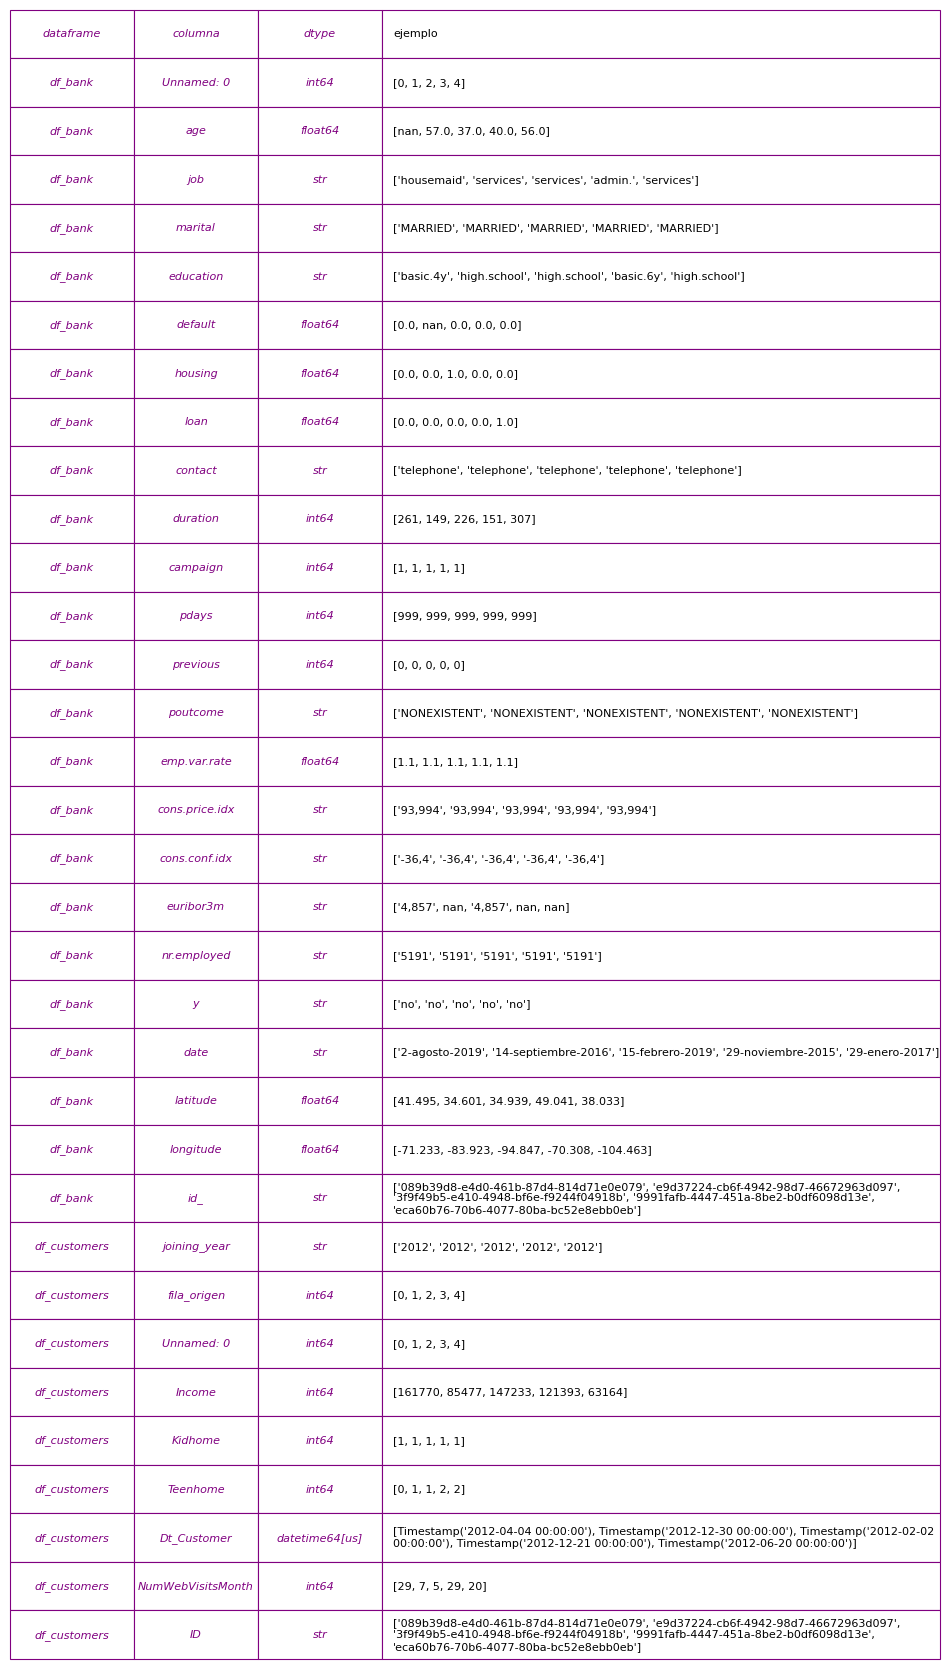

In [13]:
#Creación de una tabla visual con Matplotlib para mostrar el resumen de los datatypes 
# de ambos DataFrames.

import matplotlib.pyplot as plt

# 1. Preparar la figura
fig, ax = plt.subplots(figsize=(12,9)) # Más ancho para acomodar el texto largo
ax.axis('off')

tabla_dtypes = ax.table(cellText=df_resumentypes.values,
                        colLabels=df_resumentypes.columns,
                        loc='center')

num_cols = len(df_resumentypes.columns)
tabla_dtypes.auto_set_font_size(False)

# 2. Aplicar anchos y formatos diferenciados
for (row, col), cell in tabla_dtypes.get_celld().items():
    
    # --- CONFIGURACIÓN DE ANCHOS ---
    if col == num_cols - 1:
        # La última columna: ANCHA
        cell.set_width(0.6) 
    else:
        # Las primeras columnas: ESTRECHAS
        cell.set_width(0.4/(num_cols - 1))

    # --- ALTURA PARA EVITAR SOBREPOSICIÓN ---
    # Importante: si el texto es muy largo, sube este valor (ej. 0.1)
    cell.set_height(0.07) 
    
    # Bordes y márgenes internos
    cell.set_edgecolor('purple')
    cell.set_linewidth(0.8)
    cell.PAD = 0.02 
    
    # Configuración de Texto
    t = cell.get_text()
    t.set_wrap(True) # Permitir varias líneas
    
    if col < num_cols - 1:
        # Estilo columnas cortas
        t.set_fontsize(8)
        t.set_horizontalalignment('center')
        t.set_color('purple')
        t.set_fontstyle('italic')
    else:
        # Estilo columna de texto largo
        t.set_fontsize(8)
        t.set_horizontalalignment('left') # Justificado a la izquierda suele leerse mejor
        t.set_verticalalignment('center')

# 4. Guardar usando la función save_plot
save_plot('tabla_resumentypes',fig)

# 3. Mostrar la imagen
plt.show()


***Notas para posterior uso en limpieza de datos - vinculado a Dtypes:***
- Las columnas cuyos dtypes son suceptibles de ser modificados son:

    - Column 20: df_bank > date > from Str > to Date
    - Column 24: df_customer > joining_year > from Str > to Int or keep string.
    - Column 15: df_bank > cons.price.idx > from str > to float (Reemplazar coma por punto decimal e.g. 93,994)
    - Column 16: df_bank > cons.conf.idx > from str str > to float (Reemplazar coma por punto decimal e.g. -36,4 )
    - Column 17: df_bank > euribor3m  > from str > to float (Reemplazar coma por punto decimal e.g. 4,857)
    - Column 18: df_bank > nr.employed > from str > to float

    Nota: campo con formato fecha en este DataFrame usa este formato :
    campo df_customers > Dt_Customer > datetime64[us]
    Nota 2: El resumen de 'nr.employed' solo se visualiza int pero  lleva floats. Contiene estos 11 valores: [  '5191', '5228,1', '5195,8', '5176,3', '5099,1', '5076,2', '5017,5', '5023,5', '5008,7', '4991,6', '4963,6']

In [14]:
#verificamos el conteo de nulos por cada columna de ambos DataFrames. 
print('el porcentaje de nulos es:')
print(df_bank.isnull().sum() / df_bank.shape[0] * 100)

el porcentaje de nulos es:
Unnamed: 0         0.000000
age               11.906977
job                0.802326
marital            0.197674
education          4.202326
default           20.886047
housing            2.386047
loan               2.386047
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     1.095349
cons.conf.idx      0.000000
euribor3m         21.525581
nr.employed        0.000000
y                  0.000000
date               0.576744
latitude           0.000000
longitude          0.000000
id_                0.000000
dtype: float64


***Notas Nulos para uso en limpieza datos:***

Alto porcentaje de nulos, evaluar como proceder:

- age               11.906977

- euribor3m         21.525581

- default           20.886047

- education          4.202326

Others:

>housing            2.386047,
loan               2.386047,
cons.price.idx     1.095349,
job                0.802326,
date               0.576744,
marital            0.197674

In [15]:
#verificamos el conteo de nulos por cada columna de ambos DataFrames. 
print('Los nulos de: df_customers ')
print(df_customers.isnull().sum())

Los nulos de: df_customers 
joining_year         0
fila_origen          0
Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64


In [16]:
#Validamos repetidos en columna id_ o ID para realizar un merge de los dos DataFrame.

print(f'Números de filas duplicadas en df_bank: {df_bank.duplicated(subset="id_").sum()}')
print(f'Números de filas duplicadas en df_customers: {df_customers.duplicated(subset="ID").sum()}')

Números de filas duplicadas en df_bank: 0
Números de filas duplicadas en df_customers: 0


In [17]:
#Validamos repetidos en ambos DataFrames , filas repetidas. 

print(f'Filas duplicadas en df_bank: {df_bank.duplicated().sum()}')
print(f'Filas duplicadas en df_customers: {df_customers.duplicated().sum()}')

Filas duplicadas en df_bank: 0
Filas duplicadas en df_customers: 0


***Creación de DataFrame global con Merge***

In [18]:
# Creamos un DataFrame total, con la unión de ambos bank & customer y realizamos las validaciones y limpieza de columnas

# A. Unimos los dos dataframes
df_total_bank_customer = pd.merge(df_bank, df_customers, left_on='id_', right_on='ID', how='left')
print(f'\n El total de filas en el nuevo DataFrame total_bank_customer es: {df_total_bank_customer.shape[0]}')

# B. Validamos si los id's de las columnas 'ID' y 'id_' son iguales en el nuevo DataFrame total_bank_customer.
df_total_bank_customer['id_equals_ID'] = df_total_bank_customer['id_'] == df_total_bank_customer['ID']
print(f'\n El total de filas con "id" iguales es: {df_total_bank_customer["id_equals_ID"].sum()}')
display(df_total_bank_customer[['ID', 'id_', 'id_equals_ID']].head())

# C. Validamos si los Id's son identicos y Borramos el Id repetido (el ID que mantenemos es el de df_bank)
df_total_bank_customer = df_total_bank_customer.drop(columns=['ID'])
print('\n Columnas del nuevo DataFrame total_bank_customer:')
print(df_total_bank_customer.columns.tolist())

if df_total_bank_customer['id_equals_ID'].all():
    print('\n Todos los id son iguales, se puede eliminar la columna "id_equals_ID".')
    df_total_bank_customer = df_total_bank_customer.drop(columns=['id_equals_ID'])
else:
    print('\n Hay filas con "id" diferentes, no se puede eliminar la columna "id_equals_ID".')



 El total de filas en el nuevo DataFrame total_bank_customer es: 43000

 El total de filas con "id" iguales es: 43000


,ID,id_,id_equals_ID
0,089b39d8-e4d0-461b-87d4-814d71e0e079,089b39d8-e4d0-461b-87d4-814d71e0e079,True
1,e9d37224-cb6f-4942-98d7-46672963d097,e9d37224-cb6f-4942-98d7-46672963d097,True
2,3f9f49b5-e410-4948-bf6e-f9244f04918b,3f9f49b5-e410-4948-bf6e-f9244f04918b,True
3,9991fafb-4447-451a-8be2-b0df6098d13e,9991fafb-4447-451a-8be2-b0df6098d13e,True
4,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,True



 Columnas del nuevo DataFrame total_bank_customer:
['Unnamed: 0_x', 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_', 'joining_year', 'fila_origen', 'Unnamed: 0_y', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'id_equals_ID']

 Todos los id son iguales, se puede eliminar la columna "id_equals_ID".


In [19]:
#D. CAPA DE TRAZABILIDAD 1: EL 'DNI' de indexs ('index_merge_original')
#
# Guardamos el índice actual (del 0 al 42999) como un identificador absoluto.
# Si más adelante borramos filas, esta columna conservará el número exacto
# de la fila resultante tras el cruce inicial.
df_total_bank_customer['index_merge_original'] = df_total_bank_customer.index

print('\nEsta es la lista final de columnas del DataFrame total_bank_customer:')
print(df_total_bank_customer.columns.tolist())


Esta es la lista final de columnas del DataFrame total_bank_customer:
['Unnamed: 0_x', 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_', 'joining_year', 'fila_origen', 'Unnamed: 0_y', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'index_merge_original']


In [20]:

#Creamos una copia del DataFrame total_bank_customer para mantener el original sin modificaciones, y poder 
# comparar después de realizar las limpiezas necesarias.
# Este DF 'df_total_bank_customer_raw' 

df_total_bank_customer_raw = df_total_bank_customer.copy()

In [21]:
#Revisamos el indice si es único, para validar que se pueda usar como trazabilidad.
df_total_bank_customer_raw.index.to_series().describe()

count    43000.000000
mean     21499.500000
std      12413.175124
min          0.000000
25%      10749.750000
50%      21499.500000
75%      32249.250000
max      42999.000000
dtype: float64

***Evaluación de filas excluidas en merge***

In [22]:
#Evaluación de los 170 Registros de df_customers que no  incluyeron en la campaña de marketing.

#no se detecta ningun patron de estos clientes sin datos de marketing, por lo que se asume que no se incluyeron en la campaña. 

#Datos analizados:

#Merge de ambas listas para obtener los clientes que no tienen datos de marketing (left_only)

customers_and_databank=df_customers.merge(df_bank,left_on='ID', 
    right_on='id_', how='left',suffixes=('', '_bank'), indicator=True)

#DataFrame con los clientes que no tienen datos de marketing ('_merge'=left_only), 
# dejando solo las columnas de df_customers (las primeras 8 columnas):

solo_customers_sinmktg=customers_and_databank[customers_and_databank['_merge'] == 'left_only'].iloc[:, :8] 
print(f'Número de clientes en df_customers que no tienen datos en df_bank: {solo_customers_sinmktg.shape[0]}')
print('\nEstos son los clientes sin datos de marketing:')
print('\n***Total de valores únicos de cada columna:***\n') 
print(solo_customers_sinmktg.iloc[:,:8].nunique())
display(solo_customers_sinmktg.head(5))

print('\nEstadísticas de las columnas numéricas de los clientes sin datos de marketing:\n')
display(solo_customers_sinmktg.iloc[:, :8].describe())

print('\n Años de joining_year del total clientes:\n')

print(df_customers['joining_year'].value_counts())

print('\n***Valores únicos de cada columna de customers sin datos de marketing***\n')
for col in solo_customers_sinmktg.iloc[:,:7].columns:
    print(f"--- Columna: {col} ---")
    print(solo_customers_sinmktg[col].unique())


    

Número de clientes en df_customers que no tienen datos en df_bank: 170

Estos son los clientes sin datos de marketing:

***Total de valores únicos de cada columna:***

joining_year           3
fila_origen          170
Unnamed: 0           170
Income               170
Kidhome                3
Teenhome               3
Dt_Customer          154
NumWebVisitsMonth     32
dtype: int64


,joining_year,fila_origen,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
119,2012,119,119,102425,0,1,2012-11-09,25
120,2012,120,120,95045,1,2,2012-09-20,32
121,2012,121,121,64631,1,2,2012-10-05,13
122,2012,122,122,28884,2,2,2012-09-10,11
123,2012,123,123,102262,0,2,2012-09-10,23



Estadísticas de las columnas numéricas de los clientes sin datos de marketing:



,fila_origen,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,170.000000,170.000000,170.000000,170.000000,170.000000,170,170.000000
mean,2994.682353,2994.682353,89734.158824,0.994118,1.005882,2013-02-06 21:27:31.764706,16.994118
min,119.000000,119.000000,7483.000000,0.000000,0.000000,2012-01-12 00:00:00,1.000000
25%,559.250000,559.250000,48946.500000,0.000000,0.000000,2012-07-10 18:00:00,8.250000
50%,902.500000,902.500000,83500.500000,1.000000,1.000000,2012-11-19 00:00:00,17.000000
75%,6810.750000,6810.750000,133700.500000,2.000000,2.000000,2013-08-11 12:00:00,26.000000
max,14089.000000,14089.000000,180334.000000,2.000000,2.000000,2014-12-25 00:00:00,32.000000
std,3150.886689,3150.886689,50491.423374,0.839111,0.824887,NaN,9.889626



 Años de joining_year del total clientes:

joining_year
2012    20115
2014    14090
2013     8965
Name: count, dtype: int64

***Valores únicos de cada columna de customers sin datos de marketing***

--- Columna: joining_year ---
<StringArray>
['2012', '2013', '2014']
Length: 3, dtype: str
--- Columna: fila_origen ---
[  119   120   121   122   123   124   125   189   190   191   192   193
   194   195   196   197   310   311   312   313   314   315   316   317
   318   319   320   321   322   447   448   449   450   451   452   453
   454   455   456   457   458   558   559   560   561   562   563   564
   565   566   567   568   569   570   668   669   670   671   672   673
   674   675   833   834   835   836   837   838   839   840   841   842
   843   891   892   893   894   895   896   897   898   899   900   901
   902   903   904   905   906   907   908   909   910   911   912   913
   914  3883  3884  3885  3886  3887  3888  3889  3890  3891  3892  3893
  3894  3895  3896  389

***Validaciones de duplicados y dtypes***

In [23]:
#Detección de duplicados totalesn en el DataFrame total_bank_customer.
df_total_bank_customer.duplicated().sum()

np.int64(0)

### Limpieza de Datos : DataFrame df_total_bank_customer ###

limpieza sencilla de cosas básicas que no requieren análisis previo

In [24]:
### Limpieza de Datos###

#A. Limpieza de Dtypes y Formatos

# 1. Corrección de columnas económicas (de texto con comas a números decimales)
# Usamos .astype(str) antes por si hay algún nulo que Python lea como float
cols_economy = ['cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for col in cols_economy:
    df_total_bank_customer[col] = (
        df_total_bank_customer[col]
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
    )

# B. Corrección de la columna 'date' a formato real. 
# Cambio simple de formato da un Warning porque el formato original es "2-Agosto-2019" y no "2-08-2019".
#Aplicamos pasos intermedios para convertir los nombres de meses a números y luego convertir a datetime sin errores.

#   b.1. Diccionario de meses
meses = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04', 
    'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08', 
    'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}

#   b.2. Reemplazamos los nombres por números
#   Primero, convertimos todo a minúsculas para evitar problemas de mayúsculas/minúsculas

df_total_bank_customer['date'] = df_total_bank_customer['date'].str.lower()

#   b.3. Luego itero sobre la lista de meses para reemplazar cada nombre por su número correspondiente
#   Uso .str para asegurar que conidere un string a la celda y evitar errores si hay nulos o formatos inesperados.
for nombre, numero in meses.items():
    df_total_bank_customer['date'] = df_total_bank_customer['date'].str.replace(nombre, numero)

#   b.4. Al tener el formato "2-08-2019", aplicamos pd.to_datetime con el formato correcto.

df_total_bank_customer['date'] = pd.to_datetime(
    df_total_bank_customer['date'], 
    format='%d-%m-%Y', 
    errors='coerce'
)

#C. Aseguramos que Income sea numérico (por si acaso en otro ordenador al cargar el dato no detecte el formato 
# numérico y lo lea como texto)

df_total_bank_customer['Income'] = pd.to_numeric(df_total_bank_customer['Income'], errors='coerce')

#D. Verificación final de tipos
print("--- NUEVOS DATATYPES ---")
print(df_total_bank_customer[cols_economy + ['date', 'Income']].dtypes)

--- NUEVOS DATATYPES ---
cons.price.idx           float64
cons.conf.idx            float64
euribor3m                float64
nr.employed              float64
date              datetime64[us]
Income                     int64
dtype: object


### Creacion de conexión a DB y exportación de datos ###

Tenermos un DataFrame limpio y listo para la realizar la gestión de nulos y análisis exploratorio.

***Conexión a DB postgres y almacenamiento de DB***

Generamos la conexión a postgres desde python.

Se crearán  los siguientes DB,durante este EDA. 

- DB RAW : 
    - raw_bank (df:df_bank)
    - raw_customer (df: df_customers)
- DB MERGE  : union de bank-customer & Data types corregidos
    - stg_total_bank_customer (df: df_total_bank_customer)
- DB Clean : sobre la Db que se elaborarán las hipóstesis ( ***pendiente hasta este punto del notebook***)
    - db_marketing_cleaned

In [25]:
#Instalamos las librerías necesarias para conectar con PostgreSQL y SQLAlchemy, que es un ORM (Object-Relational Mapping) que facilita la interacción entre Python y bases de datos relacionales como PostgreSQL.

import sys
# Instalamos SQLAlchemy (el motor) y psycopg2 (el conector de Postgres)
!{sys.executable} -m pip install sqlalchemy psycopg2-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Reemplazada( dejamos por backup: # ⚠️⚠️⚠️⚠️⚠️⚠️⚠️Km0: Recordar antes de este paso modificar tus credenciales de conexión a la
  base de datos. para que puedas cargar tu DataFrame. INFO en README y en la sección 
 de configuración del entorno de persistencia relacional.⚠️⚠️⚠️⚠️⚠️⚠️⚠️

codigo:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

#1. Configuración de conexión (Usa tu nueva clave)
usuario = 'postgres'
password = 'admin123'
host = 'localhost'
puerto = '5432'
db_nombre ='proyecto_marketing'

pass_segura = quote_plus(password)
engine = create_engine(f'postgresql://{usuario}:{pass_segura}@{host}:{puerto}/{db_nombre}')

Reemplazada( dejamos por backup: 
#creamos las tablas 'Raw' en la DB con el método .to_sql() de Pandas, que permite escribir un DataFrame directamente en una tabla SQL.
df_bank.to_sql('raw_bank', engine, if_exists='replace', index=False)
df_customers.to_sql('raw_customers', engine, if_exists='replace', index=False)
#Validamos antes que las tablas 'Raw' si están las tablas creadas.

In [26]:
#Configuración de conexión a DB. 

import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

# 1. Cargar las variables de entorno subiendo un nivel hasta la raíz (.env)
ruta_env = os.path.join('..', '.env')
load_dotenv(dotenv_path=ruta_env)

# 2. Recuperar las credenciales del entorno sin exponerlas en el código
db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

# 3. Inicialización del motor de conexión de SQLAlchemy
url_conexion = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(url_conexion)

# 4. Configuración de rutas relativas multiplataforma
ruta_csv = os.path.join('..', 'data', 'raw', 'bank-additional.csv')
ruta_excel = os.path.join('..', 'data', 'raw', 'customer-details.xlsx')

# 5. Ingesta inicial de fuentes planas (Capa Raw)
df_bank = pd.read_csv(ruta_csv, sep=',', encoding='utf-8')
dict_excel = pd.read_excel(ruta_excel, sheet_name=None)

# Combinación manteniendo los niveles del MultiIndex como columnas (Se conserva 'fila_origen')
df_customers = pd.concat(dict_excel, names=['Sheet_Year', 'fila_origen']).reset_index()
df_customers = df_customers.rename(columns={'Sheet_Year': 'joining_year'})

print(f"✅ Conexión establecida de forma segura a la base de datos: '{db_name}'")
print("✅ Fuentes de datos planos cargadas en memoria (incluyendo 'fila_origen').")

✅ Conexión establecida de forma segura a la base de datos: 'proyecto_marketing'
✅ Fuentes de datos planos cargadas en memoria (incluyendo 'fila_origen').


In [27]:
# ==============================================================================
# 🏗️ Km0: Persistencia relacional de las fuentes en la capa de ingesta (Raw layer)
# ==============================================================================

# Almacenamiento automatizado de los DataFrames en el servidor PostgreSQL
# El método .to_sql() mapea la estructura de Pandas directamente en tablas físicas
df_bank.to_sql('raw_bank', con=engine, if_exists='replace', index=False)
df_customers.to_sql('raw_customers', con=engine, if_exists='replace', index=False)

print("✅ Capa de ingesta (Raw layer) persistida con éxito en PostgreSQL.")
print("📊 Tablas 'raw_bank' y 'raw_customers' listas para validación en DBeaver.")

✅ Capa de ingesta (Raw layer) persistida con éxito en PostgreSQL.
📊 Tablas 'raw_bank' y 'raw_customers' listas para validación en DBeaver.


In [28]:
df_bank.index.to_series().describe()

count    43000.000000
mean     21499.500000
std      12413.175124
min          0.000000
25%      10749.750000
50%      21499.500000
75%      32249.250000
max      42999.000000
dtype: float64

In [29]:
df_customers.index.to_series().describe()

count    43170.000000
mean     21584.500000
std      12462.249897
min          0.000000
25%      10792.250000
50%      21584.500000
75%      32376.750000
max      43169.000000
dtype: float64

In [30]:
# Validamos antes que las tablas 'Raw' si están las tablas creadas.
# Creamos la tabla 'stg_total_bank_customer' con el DataFrame total_bank_customer
df_total_bank_customer.to_sql('stg_total_bank_customer', con=engine, if_exists='replace', index=False)

#luego crearemos la db_cleaned_marketing (df_cleaned_marketing) 

430

In [31]:
#Prework : Creación de copia de df para limpieza y comparación posterior

df_total_toclean=df_total_bank_customer.copy()

#cargamos el DataFrame total_bank_customer a la tabla 'stg_total_bank_customer' de la DB, para luego realizar las limpiezas 
# necesarias y crear la tabla final 'db_cleaned_marketing' con el DataFrame df_cleaned_marketing.

Revisión de 'Unknown' en la DB

In [32]:
#1.Revisión demapa de los unknown en la tabla stg_total_bank_customer

query_unknowns="""
SELECT 
    COUNT(*) FILTER (WHERE job::text ILIKE '%%unkn%%') AS job_unk,
    COUNT(*) FILTER (WHERE marital::text ILIKE '%%unkn%%') AS marital_unk,
    COUNT(*) FILTER (WHERE education::text ILIKE '%%unkn%%') AS edu_unk,
    COUNT(*) FILTER (WHERE "default"::text ILIKE '%%unkn%%') AS default_unk,
    COUNT(*) FILTER (WHERE housing::text ILIKE '%%unkn%%') AS housing_unk,
    COUNT(*) FILTER (WHERE loan::text ILIKE '%%unkn%%') AS loan_unk
FROM stg_total_bank_customer;
"""

unknowns_count= pd.read_sql(query_unknowns, engine)
print('Conteo de valores "unknown" en la tabla stg_total_bank_customer:')
display(unknowns_count)

Conteo de valores "unknown" en la tabla stg_total_bank_customer:


,job_unk,marital_unk,edu_unk,default_unk,housing_unk,loan_unk
0,0,0,0,0,0,0


3. Métricas y Limpieza Estratégica (Paso a Paso)


In [33]:
#Revisión de nulos reales.:
print("Conteo de nulos reales (incluyendo antiguos 'unknown'):")
print((df_total_toclean.isnull().mean()*100).loc[lambda x: x > 0].sort_values(ascending=False))

#Revisamos los nulos por columna y por grupos, para entender mejor la calidad de los datos y planificar las limpiezas necesarias.
#Hay nulos en las columnas: 'age','job','marital','education'.
#***Podrian coincidir en misma fila. Se toma en cuenta para revisión.***


Conteo de nulos reales (incluyendo antiguos 'unknown'):
euribor3m         21.525581
default           20.886047
age               11.906977
education          4.202326
loan               2.386047
housing            2.386047
cons.price.idx     1.095349
job                0.802326
date               0.576744
marital            0.197674
dtype: float64


Consulta para revisar estadísticas de la DB con pg_stats

In [34]:
#Consulta para revisar estadisticas de la DB con pg_stats
# al nivel de columnas, para entender mejor la calidad de los datos y distribución, 'unicos' por cada columna.
# Nos ayuda a planificar la limpieza. 

query_pg_stats="""
SELECT 
    s.attname AS columna, 
    s.null_frac AS fraccion_nulos,
    -- Aquí multiplicamos la fracción por el total de filas de pg_class
    ROUND(s.null_frac * c.reltuples) AS conteo_estimado_nulos,
    s.n_distinct AS valores_distintos, 
    s.most_common_vals AS valores_frecuentes,
    s.most_common_freqs AS porcentaje_frecuencia
FROM pg_stats s
-- Unimos con pg_class para obtener reltuples
JOIN pg_class c ON s.tablename = c.relname
WHERE s.tablename = 'stg_total_bank_customer'
ORDER BY fraccion_nulos DESC;"""

estadisticas_pg=pd.read_sql(query_pg_stats, engine)
print('Análisis de estadísticas de la tabla:')
display(estadisticas_pg)

Análisis de estadísticas de la tabla:


,columna,fraccion_nulos,conteo_estimado_nulos,valores_distintos,valores_frecuentes,porcentaje_frecuencia


#### Análisis y limpieza de Datos personales ####

Evaluación de opciones de limpieza para los nulos de la columna age, que es la que tiene 
**el mayor porcentaje de nulos (20.5%)**. 

A.Mediana de 'age' y stats para las agrupaciones por job, marital y education para imputar los nulos de age.

In [35]:
df_statsby_age_bygroup= df_total_toclean.groupby(['job', 'marital', 'education'])['age'].agg(
    median='median', 
    count='count', 
    std='std', 
    min='min', 
    max='max'
).reset_index()

print('\nTotal de agrupaciones por job, marital y education:\n')
display(df_statsby_age_bygroup.shape[0])

print('\nEjemplo de las agrupaciones por job, marital y education para imputar los nulos de age:\n')
display(df_statsby_age_bygroup.iloc[0::50]) # Muestra cada 50 filas para ver ejemplos de las agrupaciones

display(df_statsby_age_bygroup.head(5))
display(df_statsby_age_bygroup.tail(5))


#existen agrupaciones que tienen NAN como opción de mediana, por lo que se opta por imputar
# REVISAR !!la edad con la mediana general de la columna age, que es 39 años en dichas agrupaciones. 


Total de agrupaciones por job, marital y education:



201


Ejemplo de las agrupaciones por job, marital y education para imputar los nulos de age:



,job,marital,education,median,count,std,min,max
0,admin.,DIVORCED,basic.4y,50.0,3,5.859465,48.0,59.0
50,entrepreneur,MARRIED,professional.course,41.5,94,8.396305,23.0,57.0
100,retired,DIVORCED,professional.course,58.0,49,7.214993,44.0,78.0
150,services,SINGLE,professional.course,30.0,58,6.937540,22.0,49.0
200,unemployed,SINGLE,university.degree,32.0,92,4.743845,22.0,46.0


,job,marital,education,median,count,std,min,max
0,admin.,DIVORCED,basic.4y,50.0,3,5.859465,48.0,59.0
1,admin.,DIVORCED,basic.6y,46.0,15,8.597896,30.0,56.0
2,admin.,DIVORCED,basic.9y,45.0,67,8.543210,26.0,59.0
3,admin.,DIVORCED,high.school,41.0,392,8.080377,26.0,60.0
4,admin.,DIVORCED,professional.course,45.0,41,9.163821,25.0,60.0


,job,marital,education,median,count,std,min,max
196,unemployed,SINGLE,basic.6y,37.0,4,9.032349,35.0,54.0
197,unemployed,SINGLE,basic.9y,33.0,24,8.596848,26.0,53.0
198,unemployed,SINGLE,high.school,30.5,68,5.941402,21.0,49.0
199,unemployed,SINGLE,professional.course,31.0,17,6.585412,25.0,49.0
200,unemployed,SINGLE,university.degree,32.0,92,4.743845,22.0,46.0


B. Revisión de nulos por fila 

In [36]:


# 1. Observamos que hay NaN en las columnas 'age','job','marital','education' y en la misma fila. 
#   Tomamos en cuenta para posterior limpieza
print('--- REVISIÓN DE NULOS POR FILA ---\n Creamos DF con las columnas de interés para revisar los nulos por fila en age, job, marital y education:')
df_nulos_por_fila=df_total_toclean[[df_total_toclean.columns[0],'age','job','marital','education']]

display(df_nulos_por_fila.head(10))

#Para Conteo de nulos por fila en las columnas age, job, marital o education
df_nulos_por_fila['nulos_por_fila']=df_total_toclean[['age','job','marital','education']].isnull().sum(axis=1)
#Para identificar filas que tienen más de un NaN en estas columnas clave para la limpieza.
df_nulos_por_fila['multiples_nan']=df_total_toclean[['age','job','marital','education']].isnull().sum(axis=1) > 1
# Para identificar filas que tienen algun NaN en estas columnas clave.
df_nulos_por_fila['algun_nan']=df_total_toclean[['age','job','marital','education']].isnull().any(axis=1)


print('Conteo de nulos por fila en las columnas age, job, marital o education')
df_nulos_por_fila['nulos_por_fila']=df_total_toclean[['age','job','marital','education']].isnull().sum(axis=1)
display(df_nulos_por_fila['nulos_por_fila'].value_counts())
print(f'Total de filas con >1 nulo por fila: {(df_nulos_por_fila["nulos_por_fila"]>1).sum(axis=0)}\n\n\n')
# Revisamos cuántas filas tienen más de un NaN en estas columnas clave para la limpieza.
print(f'Total de filas con más de un NaN en age, job, marital o education: {(df_nulos_por_fila["multiples_nan"].sum())} de {df_nulos_por_fila.shape[0]} filas.')
display(df_nulos_por_fila[['multiples_nan']].value_counts())
display(df_nulos_por_fila[['algun_nan']].value_counts())
#ejemplo de las columnas que tenemos creadas. 
display(df_nulos_por_fila.head(10))

#cuantas llevan NaN  en age y en : job, marital o education. Si tiene null en 'age' y tiene multiples Nan en misma fila.
print('\n\nEvaluamos a detalle los múltiples Nan vinculados a "age":')
print('Total de filas con NaN en age y  NaN en job, marital o education:')
display(df_nulos_por_fila[(df_nulos_por_fila['age'].isnull()) & (df_nulos_por_fila['multiples_nan']==1)].shape[0])
print('Total de filas con Nan solo en job,marital o education')
display(df_nulos_por_fila[(df_nulos_por_fila['age'].notna()) & (df_nulos_por_fila['nulos_por_fila']>0)].shape[0])
print('Total de filas con Nan solo en age')
display(df_nulos_por_fila[(df_nulos_por_fila['age'].isnull()) & (df_nulos_por_fila['nulos_por_fila']==1)].shape[0])

#DataFrame para filtrar y conocer la extensión de los registros con NaN en age y más de dos NaN en job, marital o education, 
# para evaluar si se pueden imputar o si es mejor eliminarlos.
df_filtrado_nulos=df_nulos_por_fila[df_nulos_por_fila['age'].isnull() & (df_nulos_por_fila['nulos_por_fila']>2)]

print(f'Filas con Nan en Age +  otras 2 columnas de  "personal: job, marital, education":\n{df_filtrado_nulos.shape[0]}')
display(df_filtrado_nulos)


--- REVISIÓN DE NULOS POR FILA ---
 Creamos DF con las columnas de interés para revisar los nulos por fila en age, job, marital y education:


,Unnamed: 0_x,age,job,marital,education
0,0,NaN,housemaid,MARRIED,basic.4y
1,1,57.0,services,MARRIED,high.school
2,2,37.0,services,MARRIED,high.school
3,3,40.0,admin.,MARRIED,basic.6y
4,4,56.0,services,MARRIED,high.school
5,5,45.0,services,MARRIED,basic.9y
6,6,59.0,admin.,MARRIED,professional.course
7,7,NaN,blue-collar,MARRIED,NaN
8,8,24.0,technician,SINGLE,professional.course
9,9,25.0,services,SINGLE,high.school


Conteo de nulos por fila en las columnas age, job, marital o education


nulos_por_fila
0    36091
1     6486
2      399
3       23
4        1
Name: count, dtype: int64

Total de filas con >1 nulo por fila: 423



Total de filas con más de un NaN en age, job, marital o education: 423 de 43000 filas.


...

1789

Total de filas con Nan solo en age


4820

Filas con Nan en Age +  otras 2 columnas de  "personal: job, marital, education":
20


,Unnamed: 0_x,age,job,marital,education,nulos_por_fila,multiples_nan,algun_nan
91,91,NaN,NaN,MARRIED,NaN,3,True,True
283,299,NaN,NaN,MARRIED,NaN,3,True,True
528,582,NaN,NaN,MARRIED,NaN,3,True,True
2129,2226,NaN,NaN,MARRIED,NaN,3,True,True
3177,3274,NaN,NaN,MARRIED,NaN,3,True,True
8112,8209,NaN,NaN,SINGLE,NaN,3,True,True
8809,8906,NaN,NaN,MARRIED,NaN,3,True,True
9244,9341,NaN,NaN,SINGLE,NaN,3,True,True
10450,10547,NaN,services,NaN,NaN,3,True,True
14692,14789,NaN,NaN,NaN,NaN,4,True,True


***Limpieza de Columnas de datos 'personales'***

Pasos para limpieza.

1. El Orden de Ejecución (La jerarquía de limpieza)

De lo más independiente a lo más dependiente.   

- Age depende de job,marital : completamos primero esos dos campos
- Education vinculado a job : completamos primero job.
- Age: última variable a completar. Guardamos un flag en nueva columna 'age_imputed', donde se indica que se ha imputado un valor.

Orden de limpieza:

Variables Categóricas Independientes (marital, job): Son las que menos nulos tienen y no dependen de nadie. Imputamos con la Moda (el valor más frecuente) por grupo o global.

Variables Educativas (education): Al ser una variable que define mucho el perfil socioeconómico, suele tener relación con job. Validaremos por Chi-cuadrado o moda de Job.

Variables Numéricas Dependientes (age): Ahora que job y education están limpias, usamos un "árbol de decisión" para imputar age (usando medianas por job + education) que  es mucho más sólido. Subgrupos que teangan mas de  >10 filas.

In [37]:
#Paso: Identificar y Marcar (Trazabilidad)
df_total_wipclean=df_total_toclean.copy() #usaremos esta para aplicar primera limpieza. 

# 1. Creamos el flag de imputación (False por defecto).
df_total_wipclean['is_imputed'] = False

# 2. Marcamos las filas donde imputaremos age.
# Donde hay nulos en age, marcamos True
df_total_wipclean.loc[df_total_wipclean['age'].isna(), 'is_imputed'] = True

# 3. Validamos la estructura del DataFrame.
print('Estructura del DataFrame con el nuevo flag de imputación:')
print(df_total_wipclean.columns.tolist())

Estructura del DataFrame con el nuevo flag de imputación:
['Unnamed: 0_x', 'age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_', 'joining_year', 'fila_origen', 'Unnamed: 0_y', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'index_merge_original', 'is_imputed']


In [38]:
#Paso: Filtrar y Eliminar filas con exceso de nulos (NaN en age + NaN en job, marital o education)

# Definimos un umbral: si una fila tiene Nan en Age + other 'main' se va.
df_total_wipclean['nan_in_othermain_columns'] = df_total_wipclean[['job', 'marital', 'education']].isnull().any(axis=1)
# Si una fila tiene NaN en age y NaN en alguna de las otras columnas principales, la marcamos como True en 'nan_age_andother'.
df_total_wipclean['nan_age_andother']= df_total_wipclean['age'].isnull() & df_total_wipclean['nan_in_othermain_columns']
#Validamos si el total de filas coincide con los 300 registros que tienen NaN en age y más de un NaN en job, marital o education.
print(f'Filas con NaN en age y NaN en job, marital o education: {df_total_wipclean[df_total_wipclean['nan_age_andother']==1].shape[0]}')

#metricas de limpieza antes de eliminar filas con exceso de nulos:
print(f'\nTotal de filas con nan en en job, marital o education antes de la limpieza:\n {df_total_wipclean[df_total_wipclean["nan_in_othermain_columns"]==1].shape[0]}')
print(f'\nTotal de filas con nan en en age  + job, marital o education antes de la limpieza:\n {df_total_wipclean[df_total_wipclean["nan_age_andother"]==1].shape[0]}')
print(f'\nTotal de filas con nan en en age\n {df_total_wipclean[df_total_wipclean["age"].isnull()].shape[0]}')
print(f'\nTotal de filas con nan en alguna --main columns--\n {df_total_wipclean[df_total_wipclean["age"].isnull()|df_total_wipclean["job"].isnull()|df_total_wipclean["marital"].isnull()|df_total_wipclean["education"].isnull()].shape[0]}')

# Separamos las filas "corruptas" almacenandolas en nuevo DataFrame.
df_rows_nandropped = df_total_wipclean[df_total_wipclean['nan_age_andother']==1].copy()


Filas con NaN en age y NaN en job, marital o education: 300

Total de filas con nan en en job, marital o education antes de la limpieza:
 2089

Total de filas con nan en en age  + job, marital o education antes de la limpieza:
 300

Total de filas con nan en en age
 5120

Total de filas con nan en alguna --main columns--
 6909


In [39]:
#Convertimos el índice a Serie con .to_series() y luego aplicamos .describe()
#  para revisar el indice actual del DF
df_total_wipclean.index.to_series().describe()

count    43000.000000
mean     21499.500000
std      12413.175124
min          0.000000
25%      10749.750000
50%      21499.500000
75%      32249.250000
max      42999.000000
dtype: float64

In [40]:
df_total_wipclean.head(10)
df_total_wipclean.describe()

,Unnamed: 0_x,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,...,latitude,longitude,fila_origen,Unnamed: 0_y,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,index_merge_original
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,...,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,...,36.856697,-95.939067,7935.478930,7935.478930,93241.200070,1.004791,0.998605,2013-05-12 07:05:06.083721,16.589698,21499.500000
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,...,24.396000,-124.997000,0.000000,0.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000,0.000000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,...,30.614750,-110.494250,3615.000000,3615.000000,49610.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000,10749.750000
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,...,36.761000,-95.899500,7222.000000,7222.000000,93050.500000,1.000000,1.000000,2013-03-02 00:00:00,17.000000,21499.500000
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,...,43.113250,-81.427750,11725.250000,11725.250000,136744.500000,2.000000,2.000000,2014-03-29 00:00:00,25.000000,32249.250000
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,...,49.384000,-66.937000,20114.000000,20114.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000,42999.000000
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,...,7.225948,16.752282,5225.658105,5225.658105,50498.316182,0.815913,0.815983,NaN,9.239205,12413.175124


Creamos la copia del DataFrame para analizar y continuar con la limpieza.

- copia : df_total_wipclean_ii que mantiene solo las filas sin excesos de nulos en columnas personales
- reseteamos index, pero ya tenemos el indice de referencia inicial en la columna 'id_join_wipclean'

In [41]:
# Creamos copia del DataFrame total_wipclean, solo con las filas que no tienen exceso de nulos,
# para eliminar las filas con exceso de nulos, y mantener el original sin modificaciones.
df_total_wipclean_ii = df_total_wipclean[df_total_wipclean['nan_age_andother'] == 0].copy()


In [42]:

# Saneamiento estructural (Para evitar bugs futuros). 
# Obligamos a Pandas a renumerar los 42.700 registros del 0 al 42699 sin huecos.
# NO se pierde trazabilidad absoluta porque está a salvo en la columna 'index_merge_original'.
df_total_wipclean_ii = df_total_wipclean_ii.reset_index(drop=True)


In [43]:

# CAPA DE TRAZABILIDAD 2: EL ANCLA OPERACIONAL
# Creamos la columna que usaremos para devolver el DataFrame a su posición original 
# tras cualquier ordenamiento (como el cronológico de las fechas).
df_total_wipclean_ii['orden_original'] = df_total_wipclean_ii.index

# Validaciones por pantalla
print(f"Filas eliminadas por exceso de nulos: {len(df_rows_nandropped)}")
print(f"Filas restantes para limpieza e imputación: {len(df_total_wipclean_ii)}")

# Comprobación de seguridad opcional para confirmar que el máximo es 42699
print("\nValidación del nuevo Ancla Operacional:")
print(f"Valor máximo en 'orden_original': {df_total_wipclean_ii['orden_original'].max()}")

Filas eliminadas por exceso de nulos: 300
Filas restantes para limpieza e imputación: 42700

Validación del nuevo Ancla Operacional:
Valor máximo en 'orden_original': 42699


In [44]:
#Validamos tamaño de los data frames después de la eliminación de filas con exceso de nulos.
print('Tamaño del DataFrame después de eliminar filas con exceso de nulos:\n')
print('\nDataFrame limpio (sin filas con NaN en age + NaN en job, marital o education):')
print(df_total_wipclean_ii[df_total_wipclean_ii.nan_age_andother==0].shape[0]) #no usamos ==0 porque Panda no lo acepta salvo en los sum() de columna
print('\nDataFrame con filas eliminadas (con NaN en age + NaN en job, marital o education):')
print(df_rows_nandropped.shape[0])

#revisamos los valores que obtenermos con la columna de 'nan....' recalculadas :
print(f'\nTotal de filas con nan en en job, marital o education despues de la limpieza:\n {df_total_wipclean_ii[df_total_wipclean_ii["nan_in_othermain_columns"]==1].shape[0]}')
print(f'\nTotal de filas con nan en en age  + job, marital o education despues de la limpieza:\n {df_total_wipclean_ii[df_total_wipclean_ii["nan_age_andother"]==1].shape[0]}')
print(f'\nTotal de filas con nan en en age\n {df_total_wipclean_ii[df_total_wipclean_ii["age"].isnull()].shape[0]}')
print(f'\nTotal de filas con nan en en alguna --main columns -- :\n {df_total_wipclean_ii[df_total_wipclean_ii["age"].isnull()|df_total_wipclean_ii["job"].isnull()|df_total_wipclean_ii["marital"].isnull()|df_total_wipclean_ii["education"].isnull()].shape[0]}')

Tamaño del DataFrame después de eliminar filas con exceso de nulos:


DataFrame limpio (sin filas con NaN en age + NaN en job, marital o education):
42700

DataFrame con filas eliminadas (con NaN en age + NaN en job, marital o education):
300

Total de filas con nan en en job, marital o education despues de la limpieza:
 1789

Total de filas con nan en en age  + job, marital o education despues de la limpieza:
 0

Total de filas con nan en en age
 4820

Total de filas con nan en en alguna --main columns -- :
 6609


In [45]:
#Paso: imputar valores a Nan de columnas job, marital y education, que son las que tienen el segundo
#  mayor porcentaje de nulos después de age.

# Crear nueva columna para Flag de other_mainimputed para marcar las filas que se imputarán
#  en job, marital o education para permitir una aduditoría de la calidad de la imputación.

# Creamos la bandera para imputaciones 'other_mainimputed'.
df_total_wipclean_ii['other_mainimputed'] = False

#hallamos las modas para 'marital' y 'job'.
#seleccionamos el primer valor porque .mode() devuelve una serie (podría haber empate de modas).
moda_marital=df_total_wipclean_ii['marital'].mode()[0] 
print(f'Moda de marital para imputar: {moda_marital}')

moda_job=df_total_wipclean_ii['job'].mode()[0]
print(f'Moda de job para imputar: {moda_job}')


Moda de marital para imputar: MARRIED
Moda de job para imputar: admin.


In [46]:
#modificamos los valores en la columna 'marital' y 'job' y marcamos en 'other_mainimputed' las filas que se imputarán, para mantener la trazabilidad de la limpieza.

#filtramos todos los que tienen Nan en 'marital' y para la columna 'other_maininputed' marcamos True 
# para indicar que se imputará un valor.
df_total_wipclean_ii.loc[df_total_wipclean_ii['marital'].isnull(),'other_mainimputed']=True
df_total_wipclean_ii['marital']= df_total_wipclean_ii['marital'].fillna(moda_marital)


#filtramos todos los que tienen Nan en 'job' y para la columna 'other_mainimputed' marcamos True 
# para indicar que se imputará un valor.
df_total_wipclean_ii.loc[df_total_wipclean_ii['job'].isnull(),'other_mainimputed']=True
df_total_wipclean_ii['job']= df_total_wipclean_ii['job'].fillna(moda_job)

#Recalculamos las columnas de vigilancia para Nan
df_total_wipclean_ii['nan_in_othermain_columns'] = df_total_wipclean_ii[['job', 'marital', 'education']].isnull().any(axis=1)
df_total_wipclean_ii['nan_age_andother']= df_total_wipclean_ii['age'].isnull() & df_total_wipclean_ii['nan_in_othermain_columns']



In [47]:
#Realizamos las validaciones para revisar si coinciden con los totales evaluados. 

print('Conteo de filas imputadas en marital o job (other_mainimputed=True):')
print(f"{df_total_wipclean_ii[df_total_wipclean_ii['other_mainimputed']==1].shape[0]}")
#el total de filas en other_main eran 1789. Verificamos de las imputadas, cuales aun tienen otro valor por impotar para validar la operacion. 
print(f"\nConteo de las filas imputadas, pero que aun tienen Nan en \"education\"")
print(f"{df_total_wipclean_ii[(df_total_wipclean_ii['other_mainimputed']==1)& (df_total_wipclean_ii['education'].isnull())].shape[0]}")
print(f'\nTotal Nan en otras --maincolumns-- job,marital,education \n{df_total_wipclean_ii[df_total_wipclean_ii["nan_in_othermain_columns"]==1].shape[0]}')
print('\nRevisamos que no existan nulos luego de  asignaciones en las 2 columnas: ')
print(f'Nulos en job:{df_total_wipclean_ii[df_total_wipclean_ii["job"].isnull()].shape[0]}')
print(f'Nulos en marital:{df_total_wipclean_ii[df_total_wipclean_ii["marital"].isnull()].shape[0]}')

Conteo de filas imputadas en marital o job (other_mainimputed=True):
371

Conteo de las filas imputadas, pero que aun tienen Nan en "education"
119

Total Nan en otras --maincolumns-- job,marital,education 
1537

Revisamos que no existan nulos luego de  asignaciones en las 2 columnas: 
Nulos en job:0
Nulos en marital:0


Analizamos si hay dependencia entre marital y education para evaluar :
- si es mejor imputar education con su moda general  
- o con la moda específica de cada grupo job o job/marital.  

In [48]:
#Revisamos la moda de education por grupos de job y marital para evaluar si hay dependencia entre marital y education,
# lo que podría indicar que es mejor imputar education con la moda específica de cada grupo job/marital en lugar de la
#  moda general.
#Caulculamos la Moda general de education y las modas específicas por cada grupo , luego Validamos.

moda_education=df_total_wipclean_ii['education'].mode()[0]
print(f'Moda de education: {moda_education}\n')


df_education_modas=df_total_wipclean_ii.groupby(['job','marital'])['education'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown').reset_index()
print(f'Total de modas de education (group by job,marital) con resultado "unknown":{df_education_modas[df_education_modas['education']=='unknown'].shape[0] }')
print('\nEjemplo de las modas de education por job y marital para imputar los nulos de education:\n')
display(df_education_modas)



Moda de education: university.degree

Total de modas de education (group by job,marital) con resultado "unknown":0

Ejemplo de las modas de education por job y marital para imputar los nulos de education:



,job,marital,education
0,admin.,DIVORCED,university.degree
1,admin.,MARRIED,university.degree
2,admin.,SINGLE,university.degree
3,blue-collar,DIVORCED,basic.9y
4,blue-collar,MARRIED,basic.9y
5,blue-collar,SINGLE,basic.9y
6,entrepreneur,DIVORCED,university.degree
7,entrepreneur,MARRIED,university.degree
8,entrepreneur,SINGLE,university.degree
9,housemaid,DIVORCED,basic.4y


Job & education: Se evalua con la técnica de Chi-cuadrado y Mapa de calor-Residuos estandarizados.  
- Hipótesis Nula (H₀): El trabajo y el nivel educativo son independientes.
- Hipótesis Alternativa (H₁): Existe una asociación entre el trabajo y el nivel educativo.

In [49]:
from scipy import stats

#Calculamos la pareja (O - observed y E - expected ) para calcular el test de Chi-cuadrado (chi^2$),

#referencia de total lineas de DataFrame,Nan en education y job.
df_conteo_nan=df_total_wipclean_ii[['job','education']].isnull().sum()
print(f'Conteo de NaN en job y education:{df_conteo_nan.shape}')

# 1. Crear tabla de contingencia (Observed) , cuantas personas hay en cada combinación de job y education.
# dejamos fuera los los NaN fuera, dropna=False no aplicado
O = pd.crosstab(df_total_wipclean_ii['job'], df_total_wipclean_ii['education'])
display(O)
#validación de totales  que deben coincidir con total de filas, al DF que tenemos visualizamos con margins
# como 'Total' y tambien calculamos una columna nueva 'Total sin Nan'
print('validacion de  totales ( incluyendo Nan) , revisar si coincide con total filas de df:')
display(pd.crosstab(df_total_wipclean_ii['job'], df_total_wipclean_ii['education'], dropna=False, margins=True, margins_name="total").assign(total_sin_NaN = lambda x: x['total'] - x[np.nan]))


# 2. Calcular Frecuencias Esperadas (E)
# E = (Fila_Total * Columna_Total) / Total_General
row_totals = O.sum(axis=1)
col_totals = O.sum(axis=0)
total = O.sum().sum() #el resultado se visualiza en el display anterior 'total_sin_Nan'

# Producto exterior para obtener la tabla de esperados
E = np.outer(row_totals, col_totals) / total
print('Display E value:')
print(E)

# 3. Calcular estadístico Chi-cuadrado
chi2_stat = np.sum((O - E)**2 / E)

# 4. Grados de libertad (Gl)
gl = (O.shape[0] - 1) * (O.shape[1] - 1)

# 5. Calcular el p_valor (Usando la función de supervivencia 'sf')
p_valor = stats.chi2.sf(chi2_stat, gl)

# 6. Revisar en tablas el valor crítico para  nivel de confianza del 95% (alpha = 0.05)  
valor_critico = stats.chi2.ppf(0.95, gl)


print(f'\nEstadístico Chi-cuadrado: {chi2_stat:.2f}')
print(f'Grados de libertad: {gl}')
print(f'Valor crítico para alpha 0.05: {valor_critico:.2f}')
print(f'p-valor:{p_valor:.4e}') # Usamos formato científico porque suele ser muy pequeño


Conteo de NaN en job y education:(2,)


education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree
job,,,,,,,
admin.,130,172,546,3506,1,386,6059
blue-collar,2408,1488,3775,919,8,474,97
entrepreneur,143,72,225,246,2,143,633
housemaid,503,82,98,183,1,60,150
management,103,86,174,306,0,93,2157
retired,625,77,151,283,3,250,302
self-employed,100,27,230,119,3,178,801
services,137,239,405,2803,0,236,181
student,27,13,101,368,0,44,176


validacion de  totales ( incluyendo Nan) , revisar si coincide con total filas de df:


education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree,NaN,total,total_sin_NaN
job,,,,,,,,,,
admin.,130,172,546,3506,1,386,6059,340,11140,10800
blue-collar,2408,1488,3775,919,8,474,97,406,9575,9169
entrepreneur,143,72,225,246,2,143,633,55,1519,1464
housemaid,503,82,98,183,1,60,150,37,1114,1077
management,103,86,174,306,0,93,2157,105,3024,2919
retired,625,77,151,283,3,250,302,87,1778,1691
self-employed,100,27,230,119,3,178,801,23,1481,1458
services,137,239,405,2803,0,236,181,133,4134,4001
student,27,13,101,368,0,44,176,149,878,729


Display E value:
[[1.14157860e+03 6.24444282e+02 1.65425261e+03 2.60298812e+03
  4.72268785e+00 1.43622185e+03 3.33579185e+03]
 [9.69179093e+02 5.30141632e+02 1.40442983e+03 2.20988871e+03
  4.00947453e+00 1.21932575e+03 2.83202551e+03]
 [1.54747322e+02 8.46468916e+01 2.24243131e+02 3.52849501e+02
  6.40186575e-01 1.94687851e+02 4.52185118e+02]
 [1.13840755e+02 6.22709715e+01 1.64965746e+02 2.59575760e+02
  4.70956927e-01 1.43223234e+02 3.32652576e+02]
 [3.08543328e+02 1.68773413e+02 4.47107718e+02 7.03529845e+02
  1.27643758e+00 3.88178850e+02 9.01590409e+02]
 [1.78741613e+02 9.77717853e+01 2.59013070e+02 4.07560455e+02
  7.39450477e-01 2.24875106e+02 5.22298521e+02]
 [1.54113111e+02 8.42999781e+01 2.23324102e+02 3.51403396e+02
  6.37562860e-01 1.93889950e+02 4.50331900e+02]
 [4.22912591e+02 2.31333479e+02 6.12839322e+02 9.64310692e+02
  1.74958093e+00 5.32067002e+02 1.23578733e+03]
 [7.70565556e+01 4.21499891e+01 1.11662051e+02 1.75701698e+02
  3.18781430e-01 9.69449749e+01 2.2516595

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\mapa_residuos_job_education.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\mapa_residuos_job_education.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


Identificamos qué "modas" de education, por Job son débiles


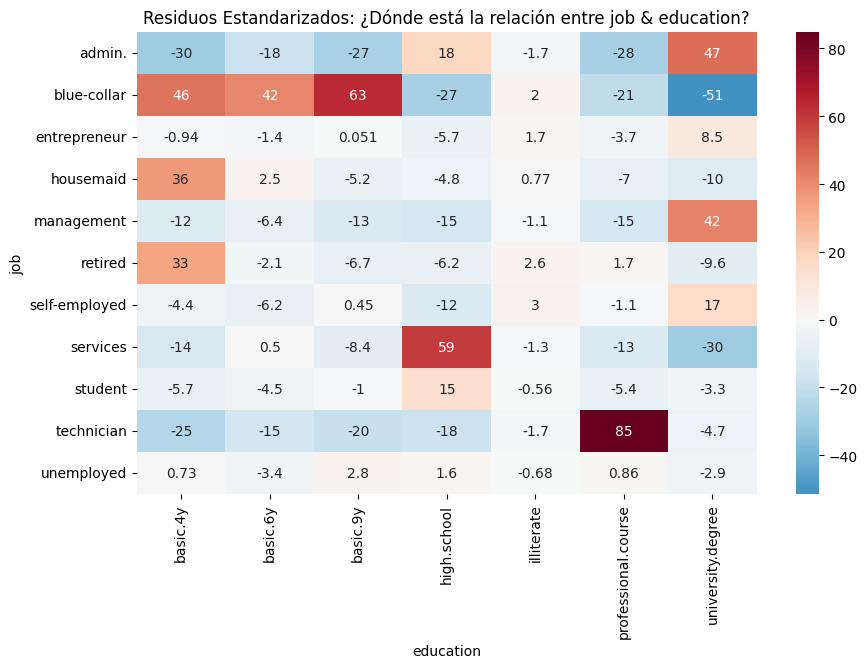

In [50]:
#7.   'O' observed  y 'E' Expected:
residuos = (O - E) / np.sqrt(E) # valores por celda usados para el calculo de chi, pero que permite crear mapa de calor. 

# Mostramos solo los que realmente destacan (el "ruido" lo ignoramos)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(residuos, annot=True, cmap='RdBu_r', center=0)
plt.title("Residuos Estandarizados: ¿Dónde está la relación entre job & education?")


# Guardamos como imagen :
save_plot("mapa_residuos_job_education")
print('\n\nIdentificamos qué "modas" de education, por Job son débiles')
plt.show() #mostramos la imagen antes de guardarla, porque sino en la función se 'captura y cierra la imagen'

# Si para un trabajo específico, la educación más frecuente tiene un residuo < 2, 
# significa que esa moda no es un patrón sólido, es casi azar.

In [51]:
display(O)
print(row_totals,col_totals,total)
print(total)

education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree
job,,,,,,,
admin.,130,172,546,3506,1,386,6059
blue-collar,2408,1488,3775,919,8,474,97
entrepreneur,143,72,225,246,2,143,633
housemaid,503,82,98,183,1,60,150
management,103,86,174,306,0,93,2157
retired,625,77,151,283,3,250,302
self-employed,100,27,230,119,3,178,801
services,137,239,405,2803,0,236,181
student,27,13,101,368,0,44,176


job
admin.           10800
blue-collar       9169
entrepreneur      1464
housemaid         1077
management        2919
retired           1691
self-employed     1458
services          4001
student            729
technician        6811
unemployed        1044
dtype: int64 education
basic.4y                4351
basic.6y                2380
basic.9y                6305
high.school             9921
illiterate                18
professional.course     5474
university.degree      12714
dtype: int64 41163
41163


In [52]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Marital & Education:  
    -Hipótesis Nula (H₀): El estado civil y el nivel educativo son independientes.  
    -Hipótesis Alternativa (H₁): Existe una asociación entre el estado civil y el nivel educativo.  

           

In [53]:
#Usamos scipy.stats para calcular la independencia entre marital y education. 

from scipy.stats import chi2_contingency

def test_chi_cuadrado(df, var1, var2):
    # 1. Creamos la tabla de contingencia
    tabla_contingencia = pd.crosstab(df[var1], df[var2])
    print(f'\n\n--- tabla de contingencia: {var1} vs {var2} ---')
    display(tabla_contingencia)

    # 2. Calculamos Chi-cuadrado
    # chi2: El estadístico, p: p-valor, gl: grados de libertad
    chi2, p, gl, expected = chi2_contingency(tabla_contingencia)
    
    # 3. Calculamos el valor crítico
    valor_critico = stats.chi2.ppf(0.95, gl)

    print(f'--- Test de Independencia: {var1} vs {var2} ---')
    print(f'Chi-cuadrado: {chi2:.2f}')
    print(f'Grados de libertad (Gl): {gl}')
    print(f'Valor_critico:{valor_critico:.2f}')
    print(f"P-valor: {p:.4f}")
    
    # Interpretación
    if p < 0.05:
        print("Resultado numérico: Hay una asociación estadísticamente significativa (rechazamos la hipótesis de independencia).")
    else:
        print("Resultado numérico: No hay evidencia suficiente de asociación (son independientes).\n\n")


In [54]:

# Ejecutamos para ver cuál aporta más información a 'education'
test_chi_cuadrado(df_total_wipclean_ii, 'job', 'education')

test_chi_cuadrado(df_total_wipclean_ii, 'marital', 'education')



--- tabla de contingencia: job vs education ---


education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree
job,,,,,,,
admin.,130,172,546,3506,1,386,6059
blue-collar,2408,1488,3775,919,8,474,97
entrepreneur,143,72,225,246,2,143,633
housemaid,503,82,98,183,1,60,150
management,103,86,174,306,0,93,2157
retired,625,77,151,283,3,250,302
self-employed,100,27,230,119,3,178,801
services,137,239,405,2803,0,236,181
student,27,13,101,368,0,44,176


--- Test de Independencia: job vs education ---
Chi-cuadrado: 36965.70
Grados de libertad (Gl): 60
Valor_critico:79.08
P-valor: 0.0000
Resultado numérico: Hay una asociación estadísticamente significativa (rechazamos la hipótesis de independencia).


--- tabla de contingencia: marital vs education ---


education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree
marital,,,,,,,
DIVORCED,515,190,592,1240,2,689,1391
MARRIED,3368,1845,4338,5384,15,3299,6696
SINGLE,468,345,1375,3297,1,1486,4627


--- Test de Independencia: marital vs education ---
Chi-cuadrado: 1768.92
Grados de libertad (Gl): 12
Valor_critico:21.03
P-valor: 0.0000
Resultado numérico: Hay una asociación estadísticamente significativa (rechazamos la hipótesis de independencia).


Pese a tener resultados favorables para rechazar (H₀),el estadístico de job es 20 veces mayor que el de marital.

Conclusión técnica: El trabajo (job) explica muchísimo mejor el nivel educativo que el estado civil.  
Incluir marital en la agrupación para imputar crearía subgrupos más pequeños (perdiendo soporte estadístico) sin mejorar la precisión. 

Imputación en Education en base a análisis

In [55]:
#conteo de filas con education null
print(f'Filas con education null: {df_total_wipclean_ii["education"].isnull().sum()}')

Filas con education null: 1537


In [56]:
#Revisamos el conteo de filas Nan antes y despues de la imputación de education. 

print('Antes de imputar "education",total de filas  con "other_mainimputed" True, que son las filas a las que se les imputó marital o job.')
print(f"{df_total_wipclean_ii[df_total_wipclean_ii['other_mainimputed']==1].shape[0]}")


Antes de imputar "education",total de filas  con "other_mainimputed" True, que son las filas a las que se les imputó marital o job.
371


In [57]:
# 2. Marcamos en 'other_mainimputed' las filas que se imputarán en education, para mantener 
# la trazabilidad de la limpieza.
df_total_wipclean_ii.loc[df_total_wipclean_ii['education'].isnull(), 'other_mainimputed'] = True



In [58]:
#Preparación para imputación de education
# 
# 1. Generamos el mapa de decisión basado en los 'residuos' del mapa de calor para imputar valor a education.

mapa_imputacion_residuos = {
    job: (residuos.loc[job].idxmax() if residuos.loc[job].max() >= 2 else moda_education)
    for job in residuos.index
}
display(mapa_imputacion_residuos)
print(type(mapa_imputacion_residuos))

mejores_educaciones = residuos.idxmax(axis=1)
print('Mejores educaciones por job según el mapa de residuos:')
print(mejores_educaciones)

{'admin.': 'university.degree',
 'blue-collar': 'basic.9y',
 'entrepreneur': 'university.degree',
 'housemaid': 'basic.4y',
 'management': 'university.degree',
 'retired': 'basic.4y',
 'self-employed': 'university.degree',
 'services': 'high.school',
 'student': 'high.school',
 'technician': 'professional.course',
 'unemployed': 'basic.9y'}

<class 'dict'>
Mejores educaciones por job según el mapa de residuos:
job
admin.             university.degree
blue-collar                 basic.9y
entrepreneur       university.degree
housemaid                   basic.4y
management         university.degree
retired                     basic.4y
self-employed      university.degree
services                 high.school
student                  high.school
technician       professional.course
unemployed                  basic.9y
dtype: str


In [59]:
# 3.  Ejecutamos la imputación física
# 3. Imputamos los valores de education usando el mapa de decisión basado en los residuos.
# Para cada fila con NaN en education, asignamos la mejor educación según el job de la fila,
#  usando el mapa de decisión. Si el job no tiene un residuo destacado, se asigna la moda general de education.

df_total_wipclean_ii['education'] = df_total_wipclean_ii.apply(
    lambda row: mapa_imputacion_residuos.get(row['job'],moda_education) if pd.isna(row['education']) else row['education'], 
    axis=1
)

In [60]:
print(f"Imputación jerárquica completada.")
print(f"Nulos restantes en 'education': {df_total_wipclean_ii['education'].isnull().sum()}\n")
print('Total de Nulos en las columnas principales después de la limpieza e imputación:')
print(df_total_wipclean_ii.isnull().sum())

Imputación jerárquica completada.
Nulos restantes en 'education': 0

Total de Nulos en las columnas principales después de la limpieza e imputación:
Unnamed: 0_x                   0
age                         4820
job                            0
marital                        0
education                      0
default                     8881
housing                     1021
loan                        1021
contact                        0
duration                       0
campaign                       0
pdays                          0
previous                       0
poutcome                       0
emp.var.rate                   0
cons.price.idx               466
cons.conf.idx                  0
euribor3m                   9185
nr.employed                    0
y                              0
date                         247
latitude                       0
longitude                      0
id_                            0
joining_year                   0
fila_origen               

Imputación de 'age'

In [61]:
#Imputamos los nulos de 'age' con la mediana por subgrupos de job, marital y education.

# 1. Definimos la mediana global como red de seguridad (fallback)
mediana_age = df_total_wipclean_ii['age'].median()

# 2. Calculamos las medianas por cada trabajo (job)
# Usamos transform para tener el valor de la mediana alineado con cada fila
mediana_age_by_job = df_total_wipclean_ii.groupby('job')['age'].transform('median')

display(mediana_age_by_job)

0        45.0
1        36.0
2        36.0
3        36.0
4        36.0
         ... 
42695    36.0
42696    37.0
42697    39.0
42698    36.0
42699    38.0
Name: age, Length: 42700, dtype: float64

In [62]:
# 3. Revisamos que se hayan marcado correctamente las filas a imputar en 'age' con el flag 'is_imputed'.
print(f"Total de filas marcadas para imputar 'age': {df_total_wipclean_ii['is_imputed'].sum()}")
print(f"Total de filas con NaN en 'age': {df_total_wipclean_ii['age'].isnull().sum()}")


Total de filas marcadas para imputar 'age': 4820
Total de filas con NaN en 'age': 4820


In [63]:
# 4. Imputamos: 

# Parámetros de calidad
min_soporte = 20 
mediana_global_age = df_total_wipclean_ii['age'].median()

# Conteo y Medianas por grupo
conteo_por_job = df_total_wipclean_ii.groupby('job')['age'].count()
medianas_por_job = df_total_wipclean_ii.groupby('job')['age'].median()

def imputar_age_final(row):
    if pd.isna(row['age']):
        job = row['job']
        # Aplicamos el umbral de 20
        if conteo_por_job.get(job, 0) >= min_soporte:
            return medianas_por_job.get(job, mediana_global_age)
        else:
            return mediana_global_age
    return row['age']

# Aplicar
df_total_wipclean_ii['age'] = df_total_wipclean_ii.apply(imputar_age_final, axis=1)

print(f"Imputación de edad completada con umbral n >= 20.")

# 5. Verificación
print(f"Nulos restantes en 'age': {df_total_wipclean_ii['age'].isnull().sum()}")

Imputación de edad completada con umbral n >= 20.
Nulos restantes en 'age': 0


In [64]:
#validación de totales filas imputadas y método aplicado sobre total. 

# 1. Parámetros
jobs_con_soporte = conteo_por_job[conteo_por_job >= min_soporte].index

# 2. Filtramos solo las filas que fueron imputadas
rows_imputed = df_total_wipclean_ii[df_total_wipclean_ii['is_imputed'] == True]

# 3. Calculamos la división
count_local = rows_imputed[rows_imputed['job'].isin(jobs_con_soporte)].shape[0]
count_global = rows_imputed[~rows_imputed['job'].isin(jobs_con_soporte)].shape[0]

# 4. Resultado
print(f"Total filas imputadas en 'age': {rows_imputed.shape[0]}")
print(f"--- Desglose ---")
print(f"Imputadas con mediana de subgrupo (n >= 20): {count_local}")
print(f"Imputadas con mediana global (fallback): {count_global}")

Total filas imputadas en 'age': 4820
--- Desglose ---
Imputadas con mediana de subgrupo (n >= 20): 4820
Imputadas con mediana global (fallback): 0


#### Detección de Outliers en 'age' ####

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\distribucion_edad_boxplot.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\distribucion_edad_boxplot.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


Identificamos posibles outliers en la distribución de edad con el boxplot:


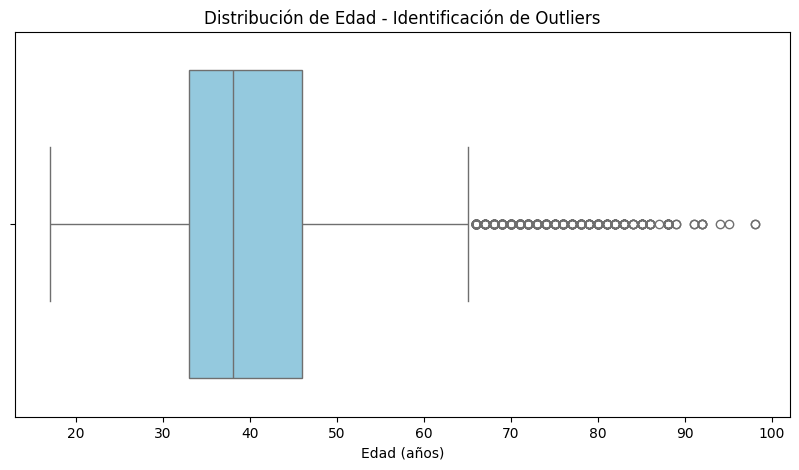

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_total_wipclean_ii['age'], color='skyblue')
plt.title('Distribución de Edad - Identificación de Outliers')
plt.xlabel('Edad (años)')

# Guardamos como imagen :
save_plot('distribucion_edad_boxplot')
print('\n\nIdentificamos posibles outliers en la distribución de edad con el boxplot:')
plt.show() #mostramos la imagen antes de guardarla, porque sino en la función se 'captura y cierra la imagen'



In [66]:
#Detalles de los Outliers en 'age'.

Q1 = df_total_wipclean_ii['age'].quantile(0.25)
Q3 = df_total_wipclean_ii['age'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir los límites (típicamente 1.5 * IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 3. Filtrar los outliers
outliers_age = df_total_wipclean_ii[(df_total_wipclean_ii['age'] < limite_inferior) | 
                                    (df_total_wipclean_ii['age'] > limite_superior)]

# 4. Calcular el porcentaje
porcentaje_outliers = (len(outliers_age) / len(df_total_wipclean_ii)) * 100
print(f"Detalles de los outliers en 'age':")
print(f"Q1 (25%): {Q1:.2f} años")
print(f"Q3 (75%): {Q3:.2f} años")
print(f"La Edad máxima en 'age': {df_total_wipclean_ii['age'].max()} años")
print(f"Limite superior para outliers en 'age': {limite_superior:.2f} años")
print(f"Limite inferior para outliers en 'age': {limite_inferior:.2f} años")
print(f"Total de registros con outliers en 'age': {len(outliers_age)}")
print(f"Porcentaje de outliers respecto al total: {porcentaje_outliers:.2f}%")

Detalles de los outliers en 'age':
Q1 (25%): 33.00 años
Q3 (75%): 46.00 años
La Edad máxima en 'age': 98.0 años
Limite superior para outliers en 'age': 65.50 años
Limite inferior para outliers en 'age': 13.50 años
Total de registros con outliers en 'age': 576
Porcentaje de outliers respecto al total: 1.35%


### Análisis y asignación de variables binarias categóricas ###

'Default'

In [67]:
#Validamos que dtype tiene 'default' para confirmar la manera de analizarlo.
df_total_wipclean_ii['default'].dtype

dtype('float64')

In [68]:
#Análisis 'default'

# 1. Creamos un DataFrame temporal con los clientes que tienen 'default' nulo
# default es float64 y los nulos se representan como NaN, por eso usamos isna() para filtrarlos.

default_nulos = df_total_wipclean_ii[df_total_wipclean_ii['default'].isna()]
# Combinamos 'housing' y 'personal' con el operador OR (|)
default_nulos['any_loan_or_housing'] = (default_nulos['housing']==1) | (default_nulos['loan']==1)

print(f"=== ANÁLISIS DE PERFIL DEL REGISTRO EN DEFAULT ({len(default_nulos)} registros) ===\n")

# 2. ¿Tienen hipoteca (housing) o préstamos (loan)?
print("Distribución de Hipotecas (housing) en los nulos de default:")
print(default_nulos['housing'].value_counts(dropna=False, normalize=True) * 100)

print("\nDistribución de Préstamos Personales (loan) en los nulos de default:")
print(default_nulos['loan'].value_counts(dropna=False, normalize=True) * 100)

print("\nDistribución de algún préstamo:")
print(default_nulos['any_loan_or_housing'].value_counts(dropna=False, normalize=True) * 100)

# 3. ¿Qué perfiles profesionales (job) dominan este vacío de información?
print("\nTop 5 Trabajos (job) con más nulos en default (proporcional):")
print(df_total_wipclean_ii[df_total_wipclean_ii['default'].isna()]['job'].value_counts(normalize=True).head(5) * 100)

#4. ejemplo de los registros con default nulo para entender mejor el perfil de estos casos.
print("\nEjemplo de registros con 'default' nulo:")
display(default_nulos.head(10))

# 3. ¿Cómo cruzamos esto en una sola tabla (Matriz de Coincidencias)?
# Para ver si se cumple al 100% que no tienen nada de nada, hagamos una tabla de contingencia rápida:


=== ANÁLISIS DE PERFIL DEL REGISTRO EN DEFAULT (8881 registros) ===

Distribución de Hipotecas (housing) en los nulos de default:
housing
1.0    50.568630
0.0    46.830312
NaN     2.601058
Name: proportion, dtype: float64

Distribución de Préstamos Personales (loan) en los nulos de default:
loan
0.0    82.558270
1.0    14.840671
NaN     2.601058
Name: proportion, dtype: float64

Distribución de algún préstamo:
any_loan_or_housing
True     56.919266
False    43.080734
Name: proportion, dtype: float64

Top 5 Trabajos (job) con más nulos en default (proporcional):
job
blue-collar    36.763878
admin.         16.585970
technician     11.518973
services       10.787074
management      5.247157
Name: proportion, dtype: float64

Ejemplo de registros con 'default' nulo:


,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,...,Teenhome,Dt_Customer,NumWebVisitsMonth,index_merge_original,is_imputed,nan_in_othermain_columns,nan_age_andother,orden_original,other_mainimputed,any_loan_or_housing
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1,2012-12-30,7,1,False,False,False,1,False,False
5,5,45.0,services,MARRIED,basic.9y,NaN,0.0,0.0,telephone,198,...,1,2012-01-24,26,5,False,False,False,5,False,False
9,10,41.0,blue-collar,MARRIED,basic.9y,NaN,0.0,0.0,telephone,55,...,1,2012-01-05,9,10,False,True,False,9,True,False
14,15,54.0,retired,MARRIED,basic.9y,NaN,1.0,1.0,telephone,174,...,2,2012-04-05,15,15,False,False,False,14,False,True
16,17,39.0,blue-collar,MARRIED,basic.6y,NaN,1.0,1.0,telephone,440,...,1,2012-01-22,5,17,True,False,False,16,False,True
18,19,39.0,management,SINGLE,basic.9y,NaN,0.0,0.0,telephone,195,...,0,2012-04-17,26,19,False,False,False,18,False,False
20,21,55.0,blue-collar,MARRIED,basic.4y,NaN,1.0,0.0,telephone,262,...,2,2012-10-08,21,21,False,False,False,20,False,True
25,27,39.0,self-employed,MARRIED,basic.9y,NaN,0.0,0.0,telephone,233,...,2,2012-02-08,30,27,False,False,False,25,False,False
26,28,54.0,technician,SINGLE,university.degree,NaN,0.0,0.0,telephone,255,...,1,2012-01-08,25,28,False,False,False,26,False,False
27,29,55.0,admin.,MARRIED,university.degree,NaN,NaN,NaN,telephone,362,...,1,2012-08-30,26,29,False,False,False,27,True,False


In [69]:
# Cruzamos housing y loan únicamente para los que tienen default nulo
tabla_cruce_housingloan = pd.crosstab(
    default_nulos['housing'].fillna('Nulo'), 
    default_nulos['loan'].fillna('Nulo'), 
    margins=True)
#, normalize='all') * 100

tabla_cruce_housingloan_perc = pd.crosstab(
    default_nulos['housing'].fillna('Nulo'), 
    default_nulos['loan'].fillna('Nulo'), 
    margins=True, normalize='all',) * 100

print("--- Matriz de Productos contratados por clientes sin registro de Default: totales y (%) ---")
display(tabla_cruce_housingloan)
display (tabla_cruce_housingloan_perc)

--- Matriz de Productos contratados por clientes sin registro de Default: totales y (%) ---


loan,0.0,1.0,Nulo,All
housing,,,,
0.0,3595,564,0,4159
1.0,3737,754,0,4491
Nulo,0,0,231,231
All,7332,1318,231,8881


loan,0.0,1.0,Nulo,All
housing,,,,
0.0,40.479676,6.350636,0.000000,46.830312
1.0,42.078595,8.490035,0.000000,50.568630
Nulo,0.000000,0.000000,2.601058,2.601058
All,82.558270,14.840671,2.601058,100.000000


'Loan' y 'housing'

In [70]:
#Análisis de 'loan' y 'housing'. 

#Creamos data frame con los registros que tienen nulos 
housing_loan_nulos = df_total_wipclean_ii[(df_total_wipclean_ii['housing'].isna())|(df_total_wipclean_ii['loan'].isna())]
display(housing_loan_nulos.shape)

#revisamos total de lineas con nulos en housing y loan, para entender la magnitud del problema.
print(f"Total de registros con nulo en 'housing': {df_total_wipclean_ii['housing'].isna().sum()}")
print(f"Total de registros con nulo en 'loan': {df_total_wipclean_ii['loan'].isna().sum()}")


display(housing_loan_nulos.head(10))

tabla_cruce_justhousingloan = pd.crosstab(
    housing_loan_nulos['housing'].fillna('Nulo'), 
    housing_loan_nulos['loan'].fillna('Nulo'), 
    margins=True)
#, normalize='all') * 100

display(tabla_cruce_justhousingloan)

(1021, 38)

Total de registros con nulo en 'housing': 1021
Total de registros con nulo en 'loan': 1021


,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,...,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,index_merge_original,is_imputed,nan_in_othermain_columns,nan_age_andother,orden_original,other_mainimputed
27,29,55.0,admin.,MARRIED,university.degree,NaN,NaN,NaN,telephone,362,...,1,1,2012-08-30,26,29,False,False,False,27,True
78,81,51.0,blue-collar,MARRIED,basic.4y,NaN,NaN,NaN,telephone,212,...,0,1,2012-08-27,14,81,False,False,False,78,False
238,261,27.0,blue-collar,SINGLE,basic.6y,0.0,NaN,NaN,telephone,119,...,1,1,2012-03-12,1,245,False,False,False,238,False
347,385,59.0,management,MARRIED,basic.4y,NaN,NaN,NaN,telephone,437,...,2,1,2012-12-12,19,356,False,False,False,347,False
363,401,36.0,services,MARRIED,high.school,NaN,NaN,NaN,telephone,152,...,2,1,2012-06-18,27,372,True,False,False,363,False
420,470,42.0,technician,SINGLE,professional.course,NaN,NaN,NaN,telephone,529,...,1,2,2012-02-05,24,429,False,False,False,420,False
435,485,36.0,admin.,MARRIED,university.degree,0.0,NaN,NaN,telephone,176,...,1,1,2012-11-12,20,444,False,False,False,435,False
444,494,36.0,admin.,SINGLE,university.degree,NaN,NaN,NaN,telephone,49,...,0,2,2012-07-29,14,453,True,False,False,444,False
445,495,31.0,services,MARRIED,high.school,NaN,NaN,NaN,telephone,374,...,0,0,2012-05-05,5,454,False,False,False,445,False
451,501,33.0,admin.,MARRIED,basic.9y,0.0,NaN,NaN,telephone,80,...,0,1,2012-04-19,31,460,False,False,False,451,False


loan,Nulo,All
housing,,
Nulo,1021,1021
All,1021,1021


Imputación 'default'

In [71]:

# 2. Para 'default', explícitamente rellenamos los nulos con una nueva categoría representativa
df_total_wipclean_ii['default'] = df_total_wipclean_ii['default'].fillna('unknown')

# 3. Verificación final de nulos
print("--- Control de calidad final del bloque financiero ---")
print(df_total_wipclean_ii[['default', 'housing', 'loan']].isnull().sum())

--- Control de calidad final del bloque financiero ---
default       0
housing    1021
loan       1021
dtype: int64


In [72]:
#Asignación de valores 'unknown' a los nulos de los datos bancarios  para mantener la trazabilidad de la limpieza.

# Unificamos el bloque financiero.
columnas_financieras = ['default', 'housing', 'loan']

# 1. Aplicamos 'unknown' de forma masiva a los nulos de este bloque
for col in columnas_financieras:
    df_total_wipclean_ii[col] = df_total_wipclean_ii[col].fillna('unknown')

# 2. Creamos un único Flag de Trazabilidad para el bloque financiero
# Si el cliente tenía nulo en cualquiera de las tres, marcamos que su perfil financiero es incompleto
df_total_wipclean_ii['financial_profile_missing'] = df_total_wipclean_ii[columnas_financieras].isna().any(axis=1)

# 3. Verificación de seguridad
print("--- Conteo final de nulos en el bloque financiero ---")
print(df_total_wipclean_ii[columnas_financieras].isnull().sum())

print("\nDistribución de la variable 'default' con su nueva categoría:")
print(df_total_wipclean_ii['default'].value_counts(normalize=True) * 100)


--- Conteo final de nulos en el bloque financiero ---
default    0
housing    0
loan       0
dtype: int64

Distribución de la variable 'default' con su nueva categoría:
default
0.0        79.194379
unknown    20.798595
1.0         0.007026
Name: proportion, dtype: float64


## *Limpieza y asignación de variables de Campaña y Macroeconómicas* ##

In [73]:
#Variables de Campaña: contact, duration, campaign, pdays, previous, poutcome.

#Variables Macroeconómicas: 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'.
 
# 1. Definimos las variables por grupos
columnas_campana = ['contact', 'duration','campaign', 'pdays', 'previous', 'poutcome']

columnas_macro = [
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Unificamos el bloque completo para el análisis
bloque_campana_total = columnas_campana + columnas_macro

# 2. Control de calidad: Conteo de Nulos
print("=== CONTEO DE NULOS: BLOQUE CAMPAÑA Y MACRO ===")
print(df_total_wipclean_ii[bloque_campana_total].isnull().sum())

# 3. Análisis Descriptivo Cuantitativo
print("\n=== ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES NUMÉRICAS ===")
#  identificamos con Pandas automáticamente cuáles son numéricas para el describe
tabla_limpia=df_total_wipclean_ii[bloque_campana_total].describe().round(2)
display(tabla_limpia)

# 4. Análisis Descriptivo Cualitativo
display(df_total_wipclean_ii[bloque_campana_total].head(10))
print("\n=== DISTRIBUCIÓN DE LAS VARIABLES CATEGÓRICAS ===")
for col in bloque_campana_total:
    if df_total_wipclean_ii[col].dtype == 'str' or df_total_wipclean_ii[col].dtype.name == 'category':
        print(f"\n--- Variable: {col} ---")
        print(df_total_wipclean_ii[col].value_counts(dropna=False, normalize=True) * 100)


=== CONTEO DE NULOS: BLOQUE CAMPAÑA Y MACRO ===
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     466
cons.conf.idx        0
euribor3m         9185
nr.employed          0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES NUMÉRICAS ===


,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,42700.00,42700.00,42700.00,42700.00,42700.00,42234.00,42700.00,33515.00,42700.00
mean,257.83,2.57,962.42,0.17,0.08,93.57,-40.51,3.62,5166.88
std,258.83,2.77,187.03,0.50,1.57,0.58,4.64,1.74,72.37
min,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,179.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0
1,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191.0
2,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0
3,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191.0
4,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191.0
5,telephone,198,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0
6,telephone,139,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0
7,telephone,380,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0
8,telephone,50,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191.0
9,telephone,55,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0



=== DISTRIBUCIÓN DE LAS VARIABLES CATEGÓRICAS ===

--- Variable: contact ---
contact
cellular     63.733021
telephone    36.266979
Name: proportion, dtype: float64

--- Variable: poutcome ---
poutcome
NONEXISTENT    86.311475
FAILURE        10.358314
SUCCESS         3.330211
Name: proportion, dtype: float64


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Describe_prelimpieza_Variables_Macro_&_Campaña.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Describe_prelimpieza_Variables_Macro_&_Campaña.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


Estadísticas descriptivas de las variables de campaña y macroeconómicas, para incluirla en el informe final de limpieza:


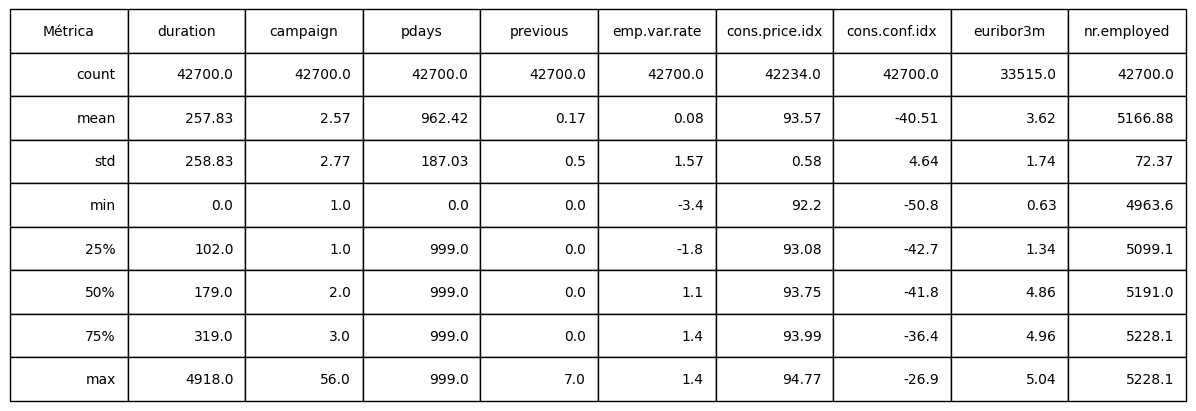

In [74]:
#Creación de una tabla visual con Matplotlib para mostrar el resumen de 'tabla limpia' con
#  las estadísticas descriptivas de las variables de campaña y macroeconómicas, para incluirla
#  en el informe final de limpieza.

import matplotlib.pyplot as plt

# 1. Preparar la figura
fig, ax = plt.subplots(figsize=(12,4)) # Más ancho para acomodar el texto largo
ax.axis('off')

#CAMBIO CLAVE: Convertimos el índice en una columna normal para que se muestre en la 
# tabla de Matplotlib, y renombramos esa columna a 'Métrica' para que sea más claro.
tabla_con_indices = tabla_limpia.reset_index().rename(columns={'index': 'Métrica'})
    
tabla_dtypes2 = ax.table(cellText=tabla_con_indices.values,
                        colLabels=tabla_con_indices.columns,
                        loc='center',
                        bbox=[0, 0, 1, 1]) # Ajustamos el tamaño de la tabla al contenedor

#  ELIMINAR EL AIRE INTERNO (MÁRGENES DE FIGURA) ---
# Ponemos top=1 y bottom=0 para estirar el contenedor al límite del archivo
plt.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

tabla_dtypes2.auto_set_font_size(False)

# 4. Guardar usando la función save_plot
save_plot('Describe_prelimpieza_Variables_Macro_&_Campaña',fig)

# 3. Mostrar la imagen
print('\n\nEstadísticas descriptivas de las variables de campaña y macroeconómicas, para incluirla en el informe final de limpieza:')
plt.show()

In [75]:
#total  de registros con  valor diferente de cero en 'previous' para entender la magnitud del problema.
print(f"Total de registros con valor diferente de cero en 'previous': {(df_total_wipclean_ii['previous']!=0).sum()} de {df_total_wipclean_ii.shape[0]} registros.")

#resumen de registros con valor diferente de cero en 'previous' para entender el perfil de estos casos.
print("\n=== Resumen de registros con valor diferente de cero en 'previous' ===")
display(df_total_wipclean_ii[df_total_wipclean_ii['previous']!=0][bloque_campana_total].sample(10))

Total de registros con valor diferente de cero en 'previous': 5845 de 42700 registros.

=== Resumen de registros con valor diferente de cero en 'previous' ===


,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
35005,cellular,126,2,999,1,FAILURE,-1.8,92.893,-46.2,NaN,5099.1
40616,cellular,184,1,999,1,FAILURE,-1.1,94.601,-49.5,1.043,4963.6
39957,cellular,382,1,999,1,FAILURE,-1.7,94.027,-38.3,0.904,4991.6
32410,cellular,151,2,999,1,FAILURE,-1.8,92.893,-46.2,1.299,5099.1
24627,cellular,99,1,999,1,FAILURE,-0.1,93.200,-42.0,NaN,5195.8
26934,cellular,164,1,999,1,FAILURE,-0.1,93.200,-42.0,4.021,5195.8
28958,cellular,1426,2,999,1,FAILURE,-1.8,93.075,-47.1,1.405,5099.1
30123,cellular,301,3,3,1,SUCCESS,-1.8,92.893,-46.2,1.354,5099.1
34986,cellular,172,2,9,2,FAILURE,-1.8,92.893,-46.2,1.250,5099.1
40022,telephone,365,2,6,1,SUCCESS,-1.7,94.027,-38.3,0.904,4991.6


***Validación de distribución de 'previous' & 'pdays' , validando si hay relación entre estas dos columnas***
Se contempla la hipótesis que exista error en la recolección de datos de campaña anterior y que el campo 'pdays' sean dias desde que se contactó en la última campaña. 
Siendo '999' sin data, asi como hay muchos registros a los que no se contactó en la anterior campaña.

=== DISTRIBUCIÓN GENERAL DE 'PREVIOUS' ===


,Total Registros,Porcentaje (%)
previous,,
0,36855,86.31
1,4738,11.10
2,778,1.82
3,231,0.54
4,73,0.17
5,19,0.04
6,5,0.01
7,1,0.00



=== VALIDACIÓN CRUCIAL: 'previous' vs 'pdays' (Valores típicos de pdays) ===


,count,min,max,median
previous,,,,
0,36855,999,999,999.0
1,4738,0,999,999.0
2,778,0,999,13.0
3,231,0,999,6.0
4,73,0,999,6.0
5,19,0,999,3.0
6,5,1,999,3.0
7,1,3,3,3.0


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Cruce_Previous_Pdays.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Cruce_Previous_Pdays.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


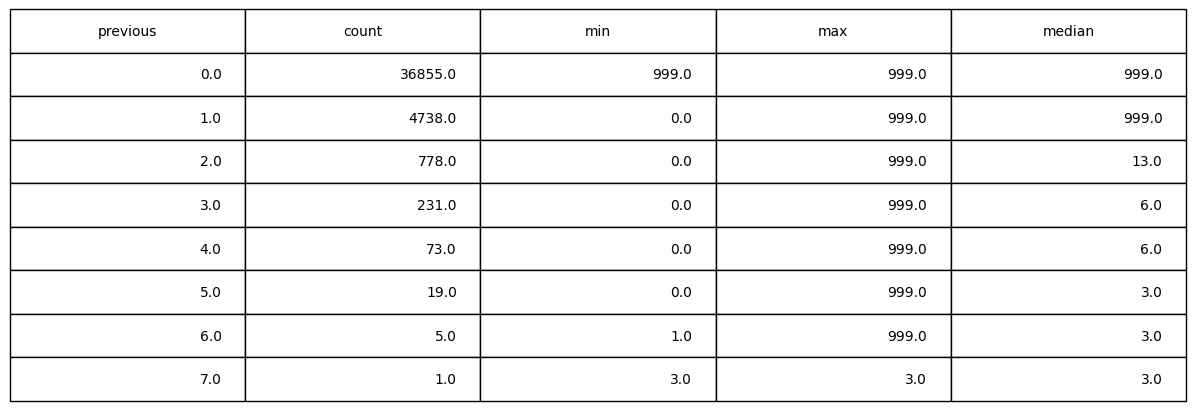

In [76]:
# 1. Creamos la tabla de frecuencias absolutas y porcentajes para 'previous'
resumen_previous = df_total_wipclean_ii['previous'].value_counts().sort_index().to_frame(name='Total Registros')
resumen_previous['Porcentaje (%)'] = (df_total_wipclean_ii['previous'].value_counts(normalize=True) * 100).round(2)

print("=== DISTRIBUCIÓN GENERAL DE 'PREVIOUS' ===")
display(resumen_previous)

# 2. Cruce estratégico: ¿Cómo se comporta 'pdays' para cada nivel de 'previous'?
# Esto nos dirá si los 999 caen exclusivamente en el grupo de cero contactos.
print("\n=== VALIDACIÓN CRUCIAL: 'previous' vs 'pdays' (Valores típicos de pdays) ===")
cruce_pdays = df_total_wipclean_ii.groupby('previous')['pdays'].agg(['count', 'min', 'max', 'median'])
display(cruce_pdays)

#Creación de una tabla visual con Matplotlib para mostrar el resumen de 'cruce_pdays' 
import matplotlib.pyplot as plt

# 1. Preparar la figura
fig, ax = plt.subplots(figsize=(12,4)) # Más ancho para acomodar el texto largo
ax.axis('off')

#CAMBIO CLAVE: Convertimos el índice en una columna normal para que se muestre en la 
# tabla de Matplotlib, y renombramos esa columna a 'Métrica' para que sea más claro.
cruce_pdays_con_indices = cruce_pdays.reset_index().rename(columns={'index': 'Métrica'})
    
tabla_dtypes3 = ax.table(cellText=cruce_pdays_con_indices.values,
                        colLabels=cruce_pdays_con_indices.columns,
                        loc='center',
                        bbox=[0, 0, 1, 1]) # Ajustamos el tamaño de la tabla al contenedor

#  ELIMINAR EL AIRE INTERNO (MÁRGENES DE FIGURA) ---
# Ponemos top=1 y bottom=0 para estirar el contenedor al límite del archivo
plt.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

tabla_dtypes3.auto_set_font_size(False)

# 4. Guardar usando la función save_plot
save_plot('Cruce_Previous_Pdays',fig)

# 3. Mostrar la imagen
plt.show()

***Validación de distribución de 'campaign' & 'pdays'***

Hay valores 999 en el pdays (dias que han pasado desde ultimo contacto en esta campaña)

'999' para los valores de percentil  25%, 50% , 75% y max indica que la mayoría de clientes no han sido contactados.  
Al revisar los registros con 999 , sin embargo que tienen valores asignados mayores a cero en 'campaign' diferente a cero. observamos que este campo puede referirse a las campañas anteriores, más que a las campaña actual basándonos en las frecuencias evaluadas.

In [77]:


# 1. Agrupamos directamente por el número exacto de contactos actuales realizados de la fila (hasta 5 contactos y tramos)
def agrupar_contactos_actuales(val):
    if val <= 5:
        return f"{int(val)} contacto(s) en esta campaña"
    elif val <= 10:
        return "6-10 contactos en esta campaña"
    else:
        return "+10 contactos en esta campaña"

df_total_wipclean_ii['campaign_group'] = df_total_wipclean_ii['campaign'].apply(agrupar_contactos_actuales)

# 2. Cruce : Verificar la coherencia de pdays (999) según el número de llamada actual
print("=== VERIFICACIÓN DE LOGICA: ¿Sigue pdays la regla de la campaña actual? ===")
cruce_real = df_total_wipclean_ii.groupby('campaign_group')['pdays'].agg(
    Total_Registros='count',
    Min_pdays='min',
    Max_pdays='max',
    Mediana_pdays='median',
    Cantidad_999=lambda x: (x == 999).sum(),
    Porcentaje_999=lambda x: round(((x == 999).sum() / len(x)) * 100, 2)
)

# Ordenamos el reporte para leerlo en orden de llamadas
orden_reporte = [
    "1 contacto(s) en esta campaña", 
    "2 contacto(s) en esta campaña", 
    "3 contacto(s) en esta campaña", 
    "4 contacto(s) en esta campaña", 
    "5 contacto(s) en esta campaña", 
    "6-10 contactos en esta campaña", 
    "+10 contactos en esta campaña"
]
cruce_real_reindexado=cruce_real.reindex(orden_reporte)

# 3. NUEVA COLUMNA: Porcentaje Acumulado de Registros (De arriba hacia abajo)
# .cumsum() va sumando fila por fila y lo dividimos por la suma total de la columna
gran_total = cruce_real_reindexado['Total_Registros'].sum()

cruce_real_reindexado['Porc_Acum_Registros'] = round(
    (cruce_real_reindexado['Total_Registros'].cumsum() / gran_total) * 100, 2
)

# Mostramos el resultado final
display(cruce_real_reindexado)


=== VERIFICACIÓN DE LOGICA: ¿Sigue pdays la regla de la campaña actual? ===


,Total_Registros,Min_pdays,Max_pdays,Mediana_pdays,Cantidad_999,Porcentaje_999,Porc_Acum_Registros
campaign_group,,,,,,,
1 contacto(s) en esta campaña,18268,0,999,999.0,17436,95.45,42.78
2 contacto(s) en esta campaña,10975,0,999,999.0,10517,95.83,68.48
3 contacto(s) en esta campaña,5554,0,999,999.0,5392,97.08,81.49
4 contacto(s) en esta campaña,2758,1,999,999.0,2703,98.01,87.95
5 contacto(s) en esta campaña,1644,3,999,999.0,1614,98.18,91.80
6-10 contactos en esta campaña,2607,1,999,999.0,2572,98.66,97.91
+10 contactos en esta campaña,894,14,999,999.0,893,99.89,100.00


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Cruce_Campaign_Pdays.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Cruce_Campaign_Pdays.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


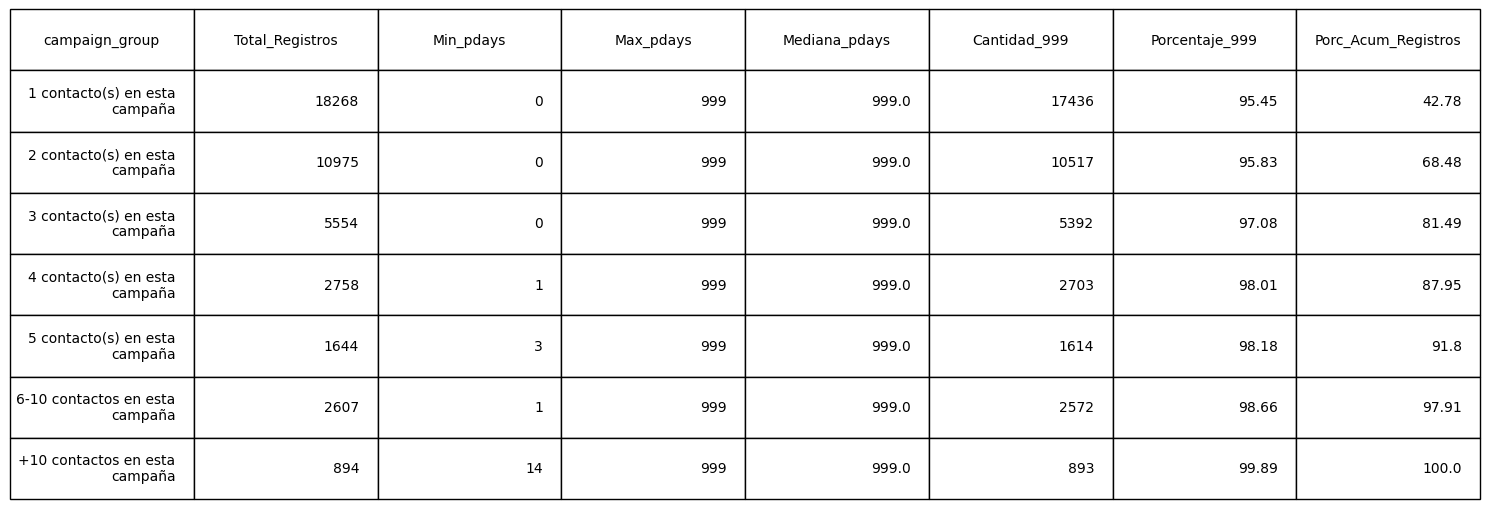

In [78]:
#Creación de una tabla visual con Matplotlib para mostrar el resumen de 'cruce_pdays_campaign_group' en readme. 
# con el análisis de pdays según el número de contactos actuales.
import matplotlib.pyplot as plt

# 1. Preparar la figura
fig, ax = plt.subplots(figsize=(15,5)) # Más ancho para acomodar el texto largo
ax.axis('off')

#CAMBIO IMPORTANTE: Convertimos el índice en una columna normal para que se muestre en la 
# tabla de Matplotlib, y renombramos esa columna a 'Métrica' para que sea más claro.
cruce_pdays_campaign_group= cruce_real_reindexado.reset_index().rename(columns={'index': 'Métrica'})
    
tabla_dtypes4 = ax.table(cellText=cruce_pdays_campaign_group.values,
                        colLabels=cruce_pdays_campaign_group.columns,
                        loc='center',
                        bbox=[0, 0, 1, 1]) # Ajustamos el tamaño de la tabla al contenedor

# 2. Aplicar anchos y formatos diferenciados
for (row, col), cell in tabla_dtypes4.get_celld().items():

    # Configuración de Texto
    t = cell.get_text()
    t.set_wrap(True) # Permitir varias líneas


#  ELIMINAR EL AIRE INTERNO (MÁRGENES DE FIGURA) ---
# Ponemos top=1 y bottom=0 para estirar el contenedor al límite del archivo
plt.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

tabla_dtypes4.auto_set_font_size(False)

# 4. Guardar usando la función save_plot
save_plot('Cruce_Campaign_Pdays',fig)

# 3. Mostrar la imagen
plt.show()

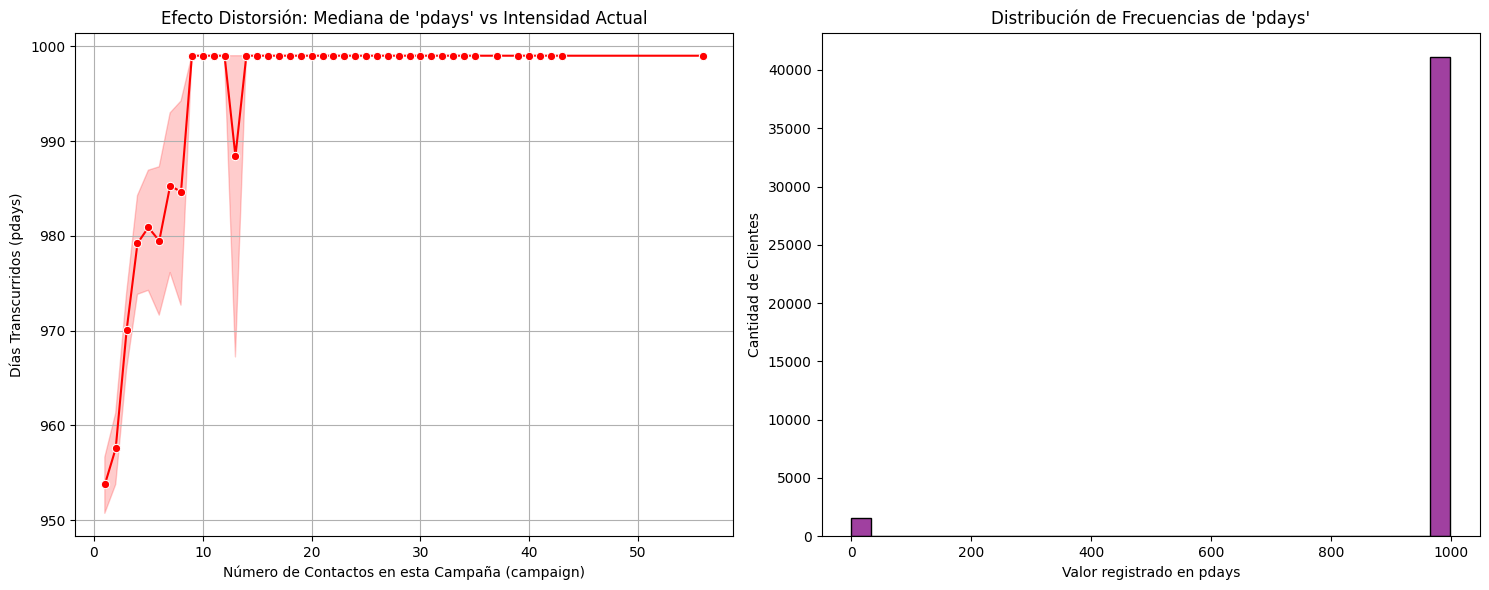

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Justificacion_grafica_pdays.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Justificacion_grafica_pdays.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


In [79]:
#sustentando que 'pdays' se queda congelado en 999 sin importar cuántas veces llamemos 
# al cliente

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: El estancamiento de la Mediana
sns.lineplot(data=df_total_wipclean_ii, x='campaign', y='pdays', ax=axes[0], color='red', marker='o')
axes[0].set_title("Efecto Distorsión: Mediana de 'pdays' vs Intensidad Actual")
axes[0].set_xlabel("Número de Contactos en esta Campaña (campaign)")
axes[0].set_ylabel("Días Transcurridos (pdays)")
axes[0].grid(True)

# Gráfico 2: Distribución de densidad para demostrar que el 999 se lo traga todo
sns.histplot(data=df_total_wipclean_ii, x='pdays', bins=30, kde=False, ax=axes[1], color='purple')
axes[1].set_title("Distribución de Frecuencias de 'pdays'")
axes[1].set_xlabel("Valor registrado en pdays")
axes[1].set_ylabel("Cantidad de Clientes")

plt.tight_layout()
plt.show()

# 4. Guardar usando la función save_plot
save_plot('Justificacion_grafica_pdays',fig)

# 3. Mostrar la imagen
plt.show()

### Acciones: Variables  de Campaña ###

Limpieza 'pdays'

In [80]:
#Para 'pdays', dado que el valor 999 es un código específico que indica "no contacto previo",
#  no se recomienda imputar un valor numérico real, ya que esto podría distorsionar el análisis 
# En su lugar, mantenemos una nueva variable categórica que  elimine ese riesgo.
#luego podremos analizar esta variable vs previous para entender mejor el perfil de los clientes sin contacto previo.

# 1. Creamos el Flag categórico
# En base a la hipótesis, refleja si el cliente viene de contactos de campañas de años anteriores o si es su primera campaña histórica
df_total_wipclean_ii['historical_contact_flag'] = df_total_wipclean_ii['pdays'].apply(
    lambda x: 'first_time_customer' if x == 999 else 'recurrent_customer')
# 2. Verificación de la nueva variable
print("=== Distribución de la nueva variable 'historical_contact_flag' ===")
print(df_total_wipclean_ii['historical_contact_flag'].value_counts(normalize=True).round(2) * 100)

print("--- Variable 'pdays' neutralizada con éxito ---")



=== Distribución de la nueva variable 'historical_contact_flag' ===
historical_contact_flag
first_time_customer    96.0
recurrent_customer      4.0
Name: proportion, dtype: float64
--- Variable 'pdays' neutralizada con éxito ---


Limpieza 'euriborn3m'

In [81]:
# euribor3m (Interés del Euríbor a 3 meses) — 9,185 nulos
print(f"Total de registros con nulo en 'euribor3m': {df_total_wipclean_ii['euribor3m'].isna().sum()}")



Total de registros con nulo en 'euribor3m': 9185


In [82]:
#revisamos que otros valores a la par de 'euriborn' se mantienen con nulos. 
df_total_wipclean_ii.info()

<class 'pandas.DataFrame'>
RangeIndex: 42700 entries, 0 to 42699
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Unnamed: 0_x               42700 non-null  int64         
 1   age                        42700 non-null  float64       
 2   job                        42700 non-null  str           
 3   marital                    42700 non-null  str           
 4   education                  42700 non-null  str           
 5   default                    42700 non-null  object        
 6   housing                    42700 non-null  object        
 7   loan                       42700 non-null  object        
 8   contact                    42700 non-null  str           
 9   duration                   42700 non-null  int64         
 10  campaign                   42700 non-null  int64         
 11  pdays                      42700 non-null  int64         
 12  previous       

- Como 'euriborn' depende de la fecha de referencia. Buscamos alternativas y relaciones con otras columnas para imputar un valor a los Nan

In [83]:
#revisamos si todos los registros tienen date
print(f"Total de registros con nulo en 'date': {df_total_wipclean_ii['date'].isna().sum()}")

# revisamos si los que tienen nulo en date tambien tienen nulo en euribor3m para evaluar si podemos imputar euribor3m con la mediana
#  general o si es mejor dejarlo como nulo por ser un bloque de información incompleto.

df_null_date = df_total_wipclean_ii[df_total_wipclean_ii['date'].isna()]
print(f"Total de registros con nulo en 'date' y 'euribor3m': {df_null_date['euribor3m'].isna().sum()}")
print(f"Total de registros con nulo en 'date' pero con valor en 'euribor3m': {(df_null_date['euribor3m'].notna()).sum()}")



Total de registros con nulo en 'date': 247
Total de registros con nulo en 'date' y 'euribor3m': 56
Total de registros con nulo en 'date' pero con valor en 'euribor3m': 191


Mantenemos como alternativa la asignación de referencia para 'euriborn' basada en la fecha de otro registro que si tenga este valor. 

In [84]:
#Validación de los días de las lineas que no tiene euribor3m pero si tienen date. 
# Hipotesis: coinciden con fin de semana ? ( ciertos datos bancarios  son generados solo de Lunes a viernes )

import pandas as pd
# 1. Creamos una copia explícita para no tocar el DataFrame original
df_fechas = df_total_wipclean_ii.copy()

# 2. Aseguramos que la columna sea de tipo datetime en la copia
df_fechas['date'] = pd.to_datetime(df_fechas['date'])

# 3. Extraemos el día de la semana en español en la copia
df_fechas['dia_semana'] = df_fechas['date'].dt.day_name(locale='es_ES')

# 4. Filtramos solo las filas que tienen nulo en 'euribor3m' pero sí tienen fecha, para analizar su distribución por día de la semana.
df_fechas_nulo_euribor = df_fechas[df_fechas['euribor3m'].isna() & df_fechas['date'].notna()]
    # Mostramos un ejemplo de los registros con nulo en euribor3m pero con fecha, para entender mejor el perfil de estos casos.
display(df_fechas_nulo_euribor.sample(n=10))
display(df_fechas_nulo_euribor[['date','dia_semana', 'euribor3m']].sample(n=10))


,Unnamed: 0_x,age,job,marital,education,default,housing,loan,contact,duration,...,index_merge_original,is_imputed,nan_in_othermain_columns,nan_age_andother,orden_original,other_mainimputed,financial_profile_missing,campaign_group,historical_contact_flag,dia_semana
11538,11724,40.0,services,DIVORCED,high.school,0.0,0.0,0.0,telephone,155,...,11627,False,False,False,11538,False,False,2 contacto(s) en esta campaña,first_time_customer,Miércoles
15709,15928,44.0,blue-collar,MARRIED,basic.9y,unknown,1.0,0.0,cellular,162,...,15831,False,False,False,15709,False,False,2 contacto(s) en esta campaña,first_time_customer,Viernes
3928,4060,25.0,blue-collar,MARRIED,basic.4y,0.0,0.0,0.0,telephone,480,...,3963,False,False,False,3928,False,False,1 contacto(s) en esta campaña,first_time_customer,Domingo
27984,28313,27.0,technician,SINGLE,basic.9y,0.0,0.0,0.0,cellular,34,...,28169,False,False,False,27984,False,False,3 contacto(s) en esta campaña,first_time_customer,Martes
18554,18798,38.0,admin.,MARRIED,basic.6y,0.0,1.0,0.0,cellular,17,...,18701,False,False,False,18554,False,False,3 contacto(s) en esta campaña,first_time_customer,Jueves
41290,20946,41.0,technician,MARRIED,university.degree,unknown,1.0,0.0,cellular,423,...,41571,False,False,False,41290,False,False,2 contacto(s) en esta campaña,first_time_customer,Miércoles
16303,16529,36.0,entrepreneur,MARRIED,university.degree,0.0,1.0,0.0,cellular,191,...,16432,False,False,False,16303,False,False,2 contacto(s) en esta campaña,first_time_customer,Martes
15082,15298,28.0,blue-collar,MARRIED,basic.9y,0.0,0.0,0.0,cellular,125,...,15201,False,False,False,15082,False,False,1 contacto(s) en esta campaña,first_time_customer,Miércoles
18708,18954,44.0,admin.,DIVORCED,high.school,0.0,1.0,0.0,cellular,99,...,18857,False,False,False,18708,False,False,2 contacto(s) en esta campaña,first_time_customer,Viernes
10798,10980,32.0,blue-collar,DIVORCED,basic.9y,0.0,0.0,0.0,telephone,13,...,10883,False,False,False,10798,False,False,+10 contactos en esta campaña,first_time_customer,Martes


,date,dia_semana,euribor3m
2607,2019-07-25,Jueves,NaN
20666,2015-05-08,Viernes,NaN
4068,2017-03-16,Jueves,NaN
13699,2016-11-16,Miércoles,NaN
11660,2018-04-11,Miércoles,NaN
25446,2016-07-27,Miércoles,NaN
19382,2018-11-02,Viernes,NaN
23761,2016-11-26,Sábado,NaN
2132,2018-08-03,Viernes,NaN
2469,2018-11-02,Viernes,NaN


-- no observamos que dependa los Nan de 'euriborn' con los sábados y domingos.   
--  realizamos un resumen con la información para confirmar 

In [85]:

# 4. Creamos la tabla resumen con conteos y porcentajes
tabla_dias = df_fechas_nulo_euribor['dia_semana'].value_counts().to_frame(name='Total_Registros')

# Calculamos el porcentaje
gran_total = tabla_dias['Total_Registros'].sum()
tabla_dias['Porcentaje'] = round((tabla_dias['Total_Registros'] / gran_total) * 100, 2)

# 5. Ordenar los días de lunes a domingo
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
tabla_resumen_dias = tabla_dias.reindex(orden_dias)

# Mostramos el resultado
display(tabla_resumen_dias)

,Total_Registros,Porcentaje
dia_semana,,
Lunes,1225,13.42
Martes,1279,14.01
Miércoles,1291,14.14
Jueves,1376,15.07
Viernes,1318,14.44
Sábado,1317,14.43
Domingo,1323,14.49


Días de la Semana con Nulos en 'euribor3m' pero con Fecha Registrada
✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Dias_semana_nulos_euribor3m.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Dias_semana_nulos_euribor3m.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


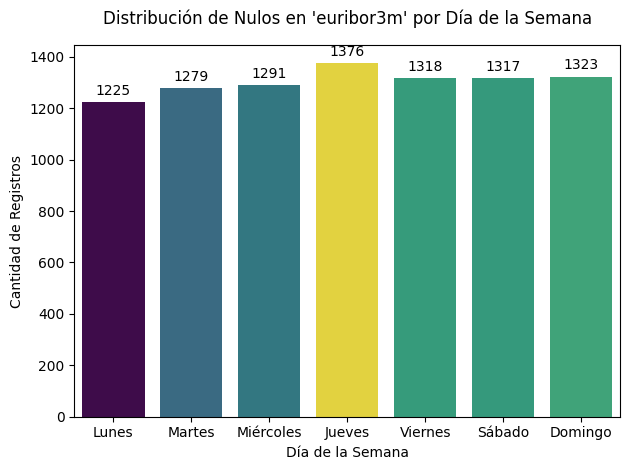

In [86]:
# 1. Creamos el gráfico y lo guardamos en la variable 'dias_semana_nulos_grafico' para luego guardarlo con la función save_plot.
dias_semana_nulos_grafico = sns.barplot(
    x=tabla_resumen_dias.index, 
    y='Total_Registros', 
    hue='Total_Registros', 
    data=tabla_resumen_dias, 
    palette='viridis', 
    legend=False
)

# Agregamos las etiquetas de datos correctamente
# Recorremos los contenedores de las barras
for contenedor in dias_semana_nulos_grafico.containers:
    dias_semana_nulos_grafico.bar_label(contenedor, padding=3, fontsize=10)

# 2. Configuración de textos y títulos
print("Días de la Semana con Nulos en 'euribor3m' pero con Fecha Registrada")
plt.title("Distribución de Nulos en 'euribor3m' por Día de la Semana", fontsize=12, pad=15)
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Registros')

# Ajustamos márgenes para evitar que se corten las etiquetas al guardar
plt.tight_layout()

#guardamos el gráfico usando la función save_plot antes de mostrarlo, para evitar que se "capture y cierre" la imagen al mostrarla.
save_plot('Dias_semana_nulos_euribor3m', dias_semana_nulos_grafico.get_figure())
plt.show()


- evaluamos si puede ser por el tipo de contacto que se utiliza. 

In [87]:

contactos = df_total_wipclean_ii['contact'].value_counts().to_frame(name='Total_Registros')

display(contactos)
print(f"Total de registros con nulo en 'euribor3m': {df_total_wipclean_ii['euribor3m'].isna().sum()}, y su distribución por tipo de contacto:")
display(df_total_wipclean_ii[df_total_wipclean_ii['euribor3m'].isna()].groupby(df_total_wipclean_ii['contact']).size().to_frame
        (name='Total_Registros').assign(Porcentaje=lambda x: round((x['Total_Registros'] / x['Total_Registros'].sum()) * 100, 2)))

,Total_Registros
contact,
cellular,27214
telephone,15486


Total de registros con nulo en 'euribor3m': 9185, y su distribución por tipo de contacto:


,Total_Registros,Porcentaje
contact,,
cellular,5912,64.37
telephone,3273,35.63


-- No vemos ningun patrón, que implique dependencia del Nan en euriborn segun el tipo de contacto.

**Imputación de 'euriborn' y cons.price.idx según proximidad de fechas**  

Ordenamos la matriz de manera cronológica y se aplicó  (Forward/Backward Fill). 
Este método garantiza que las llamadas en días no hábiles adopten las condiciones financieras del día bursátil más cercano.

In [88]:
# 
# 1. TRAZABILIDAD Y COPIAS DE SEGURIDAD (BACKUP)

# Tenemos el índice posicional original exacto de la base de datos
#df_total_wipclean_ii['orden_original']

# Creamos las columnas de backup con el estado actual (incluyendo sus nulos reales)
df_total_wipclean_ii['euribor3m_original'] = df_total_wipclean_ii['euribor3m']
df_total_wipclean_ii['cons.price.idx_original'] = df_total_wipclean_ii['cons.price.idx']

#2. PREPARACIÓN Y REORDENAMIENTO CRONOLÓGICO

# Aseguramos el formato datetime en la columna cronológica
df_total_wipclean_ii['date'] = pd.to_datetime(df_total_wipclean_ii['date'], errors='coerce')

# Ordenamos cronológicamente el DataFrame. 
# Los registros con 'date' NaN se moverán automáticamente al final (na_position='last')
df_total_wipclean_ii = df_total_wipclean_ii.sort_values(by='date')

# Reseteamos el índice para generar la nueva secuencia lineal cronológica limpia (0, 1, 2...)
# drop=True para que el índice desordenado viejo no se convierta en una columna molesta
df_total_wipclean_ii = df_total_wipclean_ii.reset_index(drop=True)


In [89]:
#revisamos con una muestra fija 
display(df_total_wipclean_ii[['date', 'euribor3m', 'cons.price.idx','orden_original']].sample(10,random_state=42))

,date,euribor3m,cons.price.idx,orden_original
23819,2017-10-22,4.962,93.918,16772
41388,2019-11-15,1.405,93.075,28751
33064,2018-11-23,4.857,93.994,5801
24432,2017-11-18,4.960,93.918,12519
7980,2015-12-09,NaN,93.994,1636
11798,2016-05-23,NaN,93.075,29362
42537,NaT,4.963,93.918,16439
24715,2017-11-30,1.262,92.963,35995
5533,2015-08-26,NaN,93.918,17319
25684,2018-01-11,NaN,93.994,5307


In [90]:
# 3. VERIFICACIÓN DEL NUEVO ESTADO

print("=== ESTRUCTURA CRONOLÓGICA PREPARADA ===")
print(f"Tamaño del DataFrame: {df_total_wipclean_ii.shape}")
print(f"Índice actual: Desde {df_total_wipclean_ii.index.min()} hasta {df_total_wipclean_ii.index.max()}")
print("\nConteo de nulos listos para ser comparados posteriormente:")
print(df_total_wipclean_ii[['euribor3m', 'cons.price.idx']].isnull().sum())

print("\n----------------------------------------------------------------------")
print(" FILTRO A: Registros SIN FECHA y SIN EURIBOR3M")
# Buscamos las filas donde coinciden ambos nulos para ver su contexto macro (emp.var.rate, nr.employed)
filtro_sin_fecha_ni_euribor = df_total_wipclean_ii[df_total_wipclean_ii['date'].isna() & df_total_wipclean_ii['euribor3m'].isna()]
print(f"Total de registros encontrados en esta condición: {len(filtro_sin_fecha_ni_euribor)}")
if not filtro_sin_fecha_ni_euribor.empty:
    display(filtro_sin_fecha_ni_euribor[['orden_original', 'date', 'euribor3m', 'emp.var.rate', 'cons.conf.idx', 'nr.employed']].head(5))
else:
    print("No hay registros que cumplan simultáneamente ambas condiciones nulas.")

print("\n----------------------------------------------------------------------")
print(" FILTRO B: Registros SIN FECHA y SIN CONS.PRICE.IDX")
# Buscamos las filas donde coinciden ambos nulos para analizar su comportamiento
filtro_sin_fecha_ni_price = df_total_wipclean_ii[df_total_wipclean_ii['date'].isna() & df_total_wipclean_ii['cons.price.idx'].isna()]
print(f"Total de registros encontrados en esta condición: {len(filtro_sin_fecha_ni_price)}")
if not filtro_sin_fecha_ni_price.empty:
    display(filtro_sin_fecha_ni_price[['orden_original', 'date', 'cons.price.idx', 'emp.var.rate', 'cons.conf.idx', 'nr.employed']].head(5))
else:
    print("No hay registros que cumplan simultáneamente ambas condiciones nulas.")

=== ESTRUCTURA CRONOLÓGICA PREPARADA ===
Tamaño del DataFrame: (42700, 43)
Índice actual: Desde 0 hasta 42699

Conteo de nulos listos para ser comparados posteriormente:
euribor3m         9185
cons.price.idx     466
dtype: int64

----------------------------------------------------------------------
 FILTRO A: Registros SIN FECHA y SIN EURIBOR3M
Total de registros encontrados en esta condición: 56


,orden_original,date,euribor3m,emp.var.rate,cons.conf.idx,nr.employed
42460,1417,NaT,NaN,1.1,-36.4,5191.0
42463,2539,NaT,NaN,1.1,-36.4,5191.0
42469,3365,NaT,NaN,1.1,-36.4,5191.0
42477,5121,NaT,NaN,1.1,-36.4,5191.0
42485,6234,NaT,NaN,1.1,-36.4,5191.0



----------------------------------------------------------------------
 FILTRO B: Registros SIN FECHA y SIN CONS.PRICE.IDX
Total de registros encontrados en esta condición: 4


,orden_original,date,cons.price.idx,emp.var.rate,cons.conf.idx,nr.employed
42517,13108,NaT,NaN,1.4,-42.7,5228.1
42560,19106,NaT,NaN,1.4,-36.1,5228.1
42593,24431,NaT,NaN,-0.1,-42.0,5195.8
42682,40091,NaT,NaN,-1.7,-38.3,4991.6


In [91]:
#busqueda de valores donde 'euribor3m' no es nulo ni 'date' , para analizar su comportamiento macroeconómico.
#y tener un ejemplo si los valores de Euribor para estos mismos valores macroeconomicos son similares
# ejemplo: nr.employed es 5191 y emp.var.rate  es 1.1

print("\n----------------------------------------------------------------------")
print(" FILTRO C: Registros CON EURIBOR3M pero CON FECHA")
con_euribor_con_fecha_sample= df_total_wipclean_ii[(df_total_wipclean_ii['euribor3m'].notna()) & (df_total_wipclean_ii['date'].notna())& (df_total_wipclean_ii['nr.employed']==5191.0) & (df_total_wipclean_ii['emp.var.rate']==1.1)]
display(con_euribor_con_fecha_sample[['euribor3m','emp.var.rate','nr.employed', 'cons.price.idx']].drop_duplicates())    
display(con_euribor_con_fecha_sample[['euribor3m','emp.var.rate','nr.employed', 'cons.price.idx']].describe().round(4))


----------------------------------------------------------------------
 FILTRO C: Registros CON EURIBOR3M pero CON FECHA


,euribor3m,emp.var.rate,nr.employed,cons.price.idx
3,4.864,1.1,5191.0,93.994
4,4.857,1.1,5191.0,93.994
9,4.858,1.1,5191.0,93.994
24,4.860,1.1,5191.0,93.994
57,4.856,1.1,5191.0,93.994
77,4.855,1.1,5191.0,93.994
88,4.859,1.1,5191.0,93.994
457,4.859,1.1,5191.0,NaN
3935,4.856,1.1,5191.0,NaN
4416,4.860,1.1,5191.0,NaN


,euribor3m,emp.var.rate,nr.employed,cons.price.idx
count,6171.0000,6171.0,6171.0,6110.000
mean,4.8577,1.1,5191.0,93.994
std,0.0021,0.0,0.0,0.000
min,4.8550,1.1,5191.0,93.994
25%,4.8560,1.1,5191.0,93.994
50%,4.8570,1.1,5191.0,93.994
75%,4.8590,1.1,5191.0,93.994
max,4.8640,1.1,5191.0,93.994


**Observaciones e imputación 'euriborn' & 'cons.price.idx'**

Diagnóstico del Filtro A (56 registros sin fecha ni Euríbor)
En este grupo de ejemplo, todas las otras variables macroeconómicas de control están limpias y rellenas:
Ejemplo:
Su emp.var.rate en 1.1 (Tasa positiva alta).
Su cons.conf.idx es de -36.4.
Su nr.employed es idéntico en 5191.1 (empleo máximo).

Pertenece al bloque económico de tipos máximos.
Entendemos que el Euríbor real de ese momento histórico exacto (donde el empleo estaba al máximo y la tasa de variación era 1.1) se movía en el entorno  de 4.855 o 4.864 para el euriborn3m.

Vemos que es muy estable el valor si se cuenta con la referencia de las otras variables macroeconomicas. 

2. Diagnóstico del Filtro B (4 registros sin fecha ni IPC)
En la captura de este grupo, vemos exactamente el mismo comportamiento en su entorno macro:

Tienen emp.var.rate = 1.4, cons.conf.idx = -36.4 y nr.employed = 5228.1.

**La Regla de Imputación** 
Para los grupos que cuentan con fecha de referencia se realiza (Forward/Backward Fill). 

Resto de nulos : Habiendo demostrado que el entorno macroeconómico es estables, podemos aplicar a las filas con Nan en dos grupos como date-consprice o date-euriborn  la mediana condicionada a ese subgrupo macroeconómico.

Es decir: a las filas vacías les inyectaremos la mediana de los registros reales que compartan sus mismas condiciones de mercado.


In [92]:
#validamos total de nulos.
print(f"Nulos restantes en 'euribor3m' después de la imputación temporal: {df_total_wipclean_ii['euribor3m'].isnull().sum()}")
print(f"Nulos restantes en 'cons.price.idx' después de la imputación temporal: {df_total_wipclean_ii['cons.price.idx'].isnull().sum()}")
print(f"Nulos restantes en 'date' después de la imputación temporal: {df_total_wipclean_ii['date'].isnull().sum()}")
display(df_total_wipclean_ii[df_total_wipclean_ii['date'].isnull() == True][['date', 'euribor3m', 'cons.price.idx','orden_original']])

Nulos restantes en 'euribor3m' después de la imputación temporal: 9185
Nulos restantes en 'cons.price.idx' después de la imputación temporal: 466
Nulos restantes en 'date' después de la imputación temporal: 247


,date,euribor3m,cons.price.idx,orden_original
42453,NaT,4.857,93.994,341
42454,NaT,4.857,93.994,509
42455,NaT,4.857,93.994,677
42456,NaT,4.856,93.994,865
42457,NaT,4.855,93.994,1044
...,...,...,...,...
42695,NaT,1.250,92.893,41625
42696,NaT,4.474,93.200,42427
42697,NaT,1.270,92.893,42520
42698,NaT,NaN,93.444,42550


In [93]:
# 1. IMPUTACIÓN CRONOLÓGICA ESTRICTA (Afecta ÚNICAMENTE a los registros con fecha real)
# Creamos una máscara para identificar las filas con fecha válida
tiene_fecha = df_total_wipclean_ii['date'].notna()

# Aplicamos ffill y bfill operando de forma aislada solo sobre ese subconjunto
df_total_wipclean_ii.loc[tiene_fecha, 'euribor3m'] = df_total_wipclean_ii.loc[tiene_fecha, 'euribor3m'].ffill().bfill()
df_total_wipclean_ii.loc[tiene_fecha, 'cons.price.idx'] = df_total_wipclean_ii.loc[tiene_fecha, 'cons.price.idx'].ffill().bfill()
display()

In [94]:
#validamos total de nulos. que coincidan con los registros sin fechas 
# y con nan en 'euriborn' y 'cons.price.idx' para confirmar que la 
# imputación se aplicó solo a los registros con fecha.
print(f"Nulos restantes en 'euribor3m' después de la imputación temporal: {df_total_wipclean_ii['euribor3m'].isnull().sum()}")
print(f"Nulos restantes en 'cons.price.idx' después de la imputación temporal: {df_total_wipclean_ii['cons.price.idx'].isnull().sum()}")
print(f"Nulos restantes en 'date' después de la imputación temporal: {df_total_wipclean_ii['date'].isnull().sum()}")
display(df_total_wipclean_ii[df_total_wipclean_ii['date'].isnull() == True][['date', 'euribor3m', 'cons.price.idx','orden_original']])

Nulos restantes en 'euribor3m' después de la imputación temporal: 56
Nulos restantes en 'cons.price.idx' después de la imputación temporal: 4
Nulos restantes en 'date' después de la imputación temporal: 247


,date,euribor3m,cons.price.idx,orden_original
42453,NaT,4.857,93.994,341
42454,NaT,4.857,93.994,509
42455,NaT,4.857,93.994,677
42456,NaT,4.856,93.994,865
42457,NaT,4.855,93.994,1044
...,...,...,...,...
42695,NaT,1.250,92.893,41625
42696,NaT,4.474,93.200,42427
42697,NaT,1.270,92.893,42520
42698,NaT,NaN,93.444,42550


In [95]:
#2. IMPUTACIÓN DINÁMICA POR HUELLA MACROECONÓMICA (Para los Huérfanos de fecha)

# --- CASO A y B : Para rellenar 'euribor3m' y 'cons.price.idx'--

# Construimos las tablas de consulta usando las dos variables 100% limpias
mapa_euribor_limpio = df_total_wipclean_ii.groupby(['emp.var.rate', 'nr.employed'])['euribor3m'].median().to_dict()
mapa_ipc_limpio = df_total_wipclean_ii.groupby(['emp.var.rate', 'nr.employed'])['cons.price.idx'].median().to_dict()


In [96]:

# Aplicamos a las celdas vacías basándonos en la clave limpia (emp.var.rate, nr.employed)
# Rellenamos los NaN de los huérfanos consultando dinámicamente el diccionario
df_total_wipclean_ii['euribor3m'] = df_total_wipclean_ii.apply(
    lambda r: mapa_euribor_limpio.get((r['emp.var.rate'], r['nr.employed']), np.nan) 
    if pd.isna(r['euribor3m']) else r['euribor3m'], axis=1
)

df_total_wipclean_ii['cons.price.idx'] = df_total_wipclean_ii.apply(
    lambda r: mapa_ipc_limpio.get((r['emp.var.rate'], r['nr.employed']), np.nan) 
    if pd.isna(r['cons.price.idx']) else r['cons.price.idx'], axis=1
)

In [97]:
#validamos total de nulos.
print(f"Nulos restantes en 'euribor3m' después de la imputación temporal: {df_total_wipclean_ii['euribor3m'].isnull().sum()}")
print(f"Nulos restantes en 'cons.price.idx' después de la imputación temporal: {df_total_wipclean_ii['cons.price.idx'].isnull().sum()}")
print(f"Nulos restantes en 'date' después de la imputación temporal: {df_total_wipclean_ii['date'].isnull().sum()}")
display(df_total_wipclean_ii[df_total_wipclean_ii['date'].isnull() == True][['date', 'euribor3m', 'cons.price.idx','orden_original']])

Nulos restantes en 'euribor3m' después de la imputación temporal: 0
Nulos restantes en 'cons.price.idx' después de la imputación temporal: 0
Nulos restantes en 'date' después de la imputación temporal: 247


,date,euribor3m,cons.price.idx,orden_original
42453,NaT,4.857,93.994,341
42454,NaT,4.857,93.994,509
42455,NaT,4.857,93.994,677
42456,NaT,4.856,93.994,865
42457,NaT,4.855,93.994,1044
...,...,...,...,...
42695,NaT,1.250,92.893,41625
42696,NaT,4.474,93.200,42427
42697,NaT,1.270,92.893,42520
42698,NaT,4.962,93.444,42550


**Revisamos nulos y columnas creadas para la limpieza y restauramos el orden del dataframe.**

*Columnas creadas para limpieza*: 

* 32  index_merge_original         42700 non-null  int64         
* 33  is_imputed                   42700 non-null  bool          
* 34  nan_in_othermain_columns     42700 non-null  bool          
* 35  nan_age_andother             42700 non-null  bool          
* 36  orden_original               42700 non-null  int64         
* 37  other_mainimputed            42700 non-null  bool          
* 38  financial_profile_missing    42700 non-null  bool          
* 39  campaign_group               42700 non-null  str           
* 40  historical_contact_flag      42700 non-null  str           
* 41  euribor3m_original           33515 non-null  float64       
* 42  cons.price.idx_original      42234 non-null  float64       


In [98]:
#revisamos los nulos y columnas 
df_total_wipclean_ii.info()
#reordenamos el dataframe con su índice original para que quede en el mismo orden
# que el dataset inicial, y así facilitar la comparación de registros antes y 
# después de la limpieza.
df_total_wipclean_ii = df_total_wipclean_ii.sort_values(by='orden_original')
#reseteamos el índice para que vuelva a ser una secuencia lineal limpia (0, 1, 2...)
df_total_wipclean_ii = df_total_wipclean_ii.reset_index(drop=True)



<class 'pandas.DataFrame'>
RangeIndex: 42700 entries, 0 to 42699
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Unnamed: 0_x               42700 non-null  int64         
 1   age                        42700 non-null  float64       
 2   job                        42700 non-null  str           
 3   marital                    42700 non-null  str           
 4   education                  42700 non-null  str           
 5   default                    42700 non-null  object        
 6   housing                    42700 non-null  object        
 7   loan                       42700 non-null  object        
 8   contact                    42700 non-null  str           
 9   duration                   42700 non-null  int64         
 10  campaign                   42700 non-null  int64         
 11  pdays                      42700 non-null  int64         
 12  previous       

In [99]:
!pip install jinja2
# librería de Python Jinja2 (motor de plantillas web) en segundo plano para poder
# pintar los estilos CSS, los colores y las columnas congeladas (.style) dentro del
# cuaderno de Jupyter.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Muestra previa de filas al reordenar y crear nuevo indice : 
![Resumen](..\reports\figuras\validacion_orden_by_date_DF_wip_cleanii.PNG)

In [100]:
#Validamos con una muestra fija que los registros se encuentran en el mismo orden 
# que el dataset original, para facilitar la comparación de registros antes y después de la limpieza.

#Eliminamos el límite de columnas (muestra absolutamente todas en horizontal)

pd.set_option('display.max_columns', None)

display(
    df_total_wipclean_ii[df_total_wipclean_ii['orden_original'].isin([16772, 28751, 5801, 12519, 1636, 29362])]
    [['date', 'euribor3m', 'cons.price.idx', 'orden_original']]
    .style.set_sticky(axis='columns')
) 

,date,euribor3m,cons.price.idx,orden_original
1636,2015-12-09 00:00:00,4.120000,93.994000,1636
5801,2018-11-23 00:00:00,4.857000,93.994000,5801
12519,2017-11-18 00:00:00,4.960000,93.918000,12519
16772,2017-10-22 00:00:00,4.962000,93.918000,16772
28751,2019-11-15 00:00:00,1.405000,93.075000,28751
29362,2016-05-23 00:00:00,4.864000,93.075000,29362


In [101]:
# Imprime una muestra aleatoria de la tabla completa, SIN FILTRAR por nulos
display(df_total_wipclean_ii[['orden_original', 'euribor3m']].sample(5))

,orden_original,euribor3m
22474,22474,4.965
28267,28267,1.415
515,515,4.857
18101,18101,4.968
4613,4613,4.959


In [102]:
# Esto nos dice si hay alguna sola fila en todo el dataset donde el índice no coincida
filas_descuadradas = (df_total_wipclean_ii.index != df_total_wipclean_ii['orden_original']).sum()
print(f"Total de filas descuadradas en el DataFrame completo: {filas_descuadradas}")

Total de filas descuadradas en el DataFrame completo: 0


## *Limpieza del Bloque Espacial (Geolocalización) y de comportamiento ( Outliers)* ##

In [103]:
#creamos una copia de seguridad del DataFrame después de la limpieza del bloque financiero y personal, para tener un punto de retorno seguro. 
df_total_wipclean_iii = df_total_wipclean_ii.copy()

*Bloque Espacial (Geolocalización)*

In [104]:
print(f"Dimensiones de inicio para el bloque espacial: {df_total_wipclean_iii.shape}")

# AUDITORÍA DE GEOLOCALIZACIÓN (latitude, longitude)

# 1. Revisamos nulos absolutos
nulos_geo = df_total_wipclean_iii[['latitude', 'longitude']].isna().sum()
print("\nNulos en variables espaciales:")
print(nulos_geo)


Dimensiones de inicio para el bloque espacial: (42700, 43)

Nulos en variables espaciales:
latitude     0
longitude    0
dtype: int64


In [105]:
# (Sabiendo que NO hay nulos y que ambas columnas son Float64 , buscamos 
#  errores de límites)

# 1. Detectar coordenadas imposibles
# Latitud: [-90, 90] | Longitud: [-180, 180]
mask_lat_invalida = (df_total_wipclean_iii['latitude'] < -90) | (df_total_wipclean_iii['latitude'] > 90)
mask_lon_invalida = (df_total_wipclean_iii['longitude'] < -180) | (df_total_wipclean_iii['longitude'] > 180)

print("\n--- Auditoría de Coordenadas ---")
print(f"Coordenadas fuera de límites terrestres:")
print(f"Latitudes imposibles: {mask_lat_invalida.sum()}")
print(f"Longitudes imposibles: {mask_lon_invalida.sum()}")


--- Auditoría de Coordenadas ---
Coordenadas fuera de límites terrestres:
Latitudes imposibles: 0
Longitudes imposibles: 0


In [106]:
#Creamos TRAZABILIDAD E IMPUTACIÓN ESPACIAL, en caso tuviesems datos fuera de rango. 

# 2. Creamos la bandera de imputación para proteger la trazabilidad
df_total_wipclean_iii['is_geo_imputed'] = False

# Agrupamos solo los registros fuera de rango en la máscara final
mask_geo_necesita_imputar = mask_lat_invalida | mask_lon_invalida

# 3. Imputación inteligente: Solo calculamos si realmente hay errores
if mask_geo_necesita_imputar.sum() > 0:
    df_total_wipclean_iii.loc[mask_geo_necesita_imputar, 'is_geo_imputed'] = True

    # Calculamos la "Mediana Geográfica" usando SOLO los registros limpios : los que no(~) necesitan imputar
    mediana_lat = df_total_wipclean_iii.loc[~mask_geo_necesita_imputar, 'latitude'].median()
    mediana_lon = df_total_wipclean_iii.loc[~mask_geo_necesita_imputar, 'longitude'].median()

    print(f"\nImputando {mask_geo_necesita_imputar.sum()} valores fuera de rango con el epicentro del banco:")
    print(f"Centro Latitud: {mediana_lat:.4f}")
    print(f"Centro Longitud: {mediana_lon:.4f}")

    # Aplicamos la imputación
    df_total_wipclean_iii.loc[mask_geo_necesita_imputar, 'latitude'] = mediana_lat
    df_total_wipclean_iii.loc[mask_geo_necesita_imputar, 'longitude'] = mediana_lon
else:
    print("\n¡Excelente! No hay coordenadas fuera de rango. No se requiere imputación espacial.")


# VALIDACIÓN FINAL

print("\n--- Comprobación de Calidad ---")
print(f"Total de registros con coordenadas artificiales (corregidas): {df_total_wipclean_iii['is_geo_imputed'].sum()}")


¡Excelente! No hay coordenadas fuera de rango. No se requiere imputación espacial.

--- Comprobación de Calidad ---
Total de registros con coordenadas artificiales (corregidas): 0


## *Outliers* : 'duration'  ##

Revisamos los datos con técnicas de Normalización  Rango Intercuartílico - IQR y Escalado (Z-Score) y analizamos la Distribución de Probabilidad de las llamadas.

Luego decidimos que método aplicar para normalizar los datos. 

In [107]:
import numpy as np
# 1.TRAZABILIDAD: Backup de la variable original
df_total_wipclean_iii['duration_original'] = df_total_wipclean_iii['duration']

print("--- Análisis Descriptivo Inicial de 'duration' (en segundos) ---")
display(df_total_wipclean_iii['duration'].describe().round(2))

# 2. Detección de Ceros (Llamadas no conectadas)
llamadas_cero = (df_total_wipclean_iii['duration'] == 0).sum()
print(f"\nLlamadas con duración 0 segundos: {llamadas_cero}")


--- Análisis Descriptivo Inicial de 'duration' (en segundos) ---


count    42700.00
mean       257.83
std        258.83
min          0.00
25%        102.00
50%        179.00
75%        319.00
max       4918.00
Name: duration, dtype: float64


Llamadas con duración 0 segundos: 4


In [108]:

# DETECCIÓN DE OUTLIERS: Método 1  - Rango Intercuartílico - IQR)
# 
# Calculamos Q1 (percentil 25) y Q3 (percentil 75)
Q1 = df_total_wipclean_iii['duration'].quantile(0.25)
Q3 = df_total_wipclean_iii['duration'].quantile(0.75)
IQR = Q3 - Q1

# Definimos el límite superior estadístico. 
# (No calculamos el inferior porque no hay duraciones negativas)
limite_superior_iqr = Q3 + 1.5 * IQR

outliers_iqr = df_total_wipclean_iii[df_total_wipclean_iii['duration'] > limite_superior_iqr].shape[0]
print(f"\n--- Detección de Outliers ---")
print(f"Límite superior estadístico (Método IQR): {limite_superior_iqr:.2f} segundos")
print(f"Total de Outliers detectados (IQR): {outliers_iqr} llamadas")



--- Detección de Outliers ---
Límite superior estadístico (Método IQR): 644.50 segundos
Total de Outliers detectados (IQR): 3055 llamadas


In [109]:

# DETECCIÓN DE OUTLIERS: Método 2 -Técnica de Normalización y Escalado: Z-Score
#
# con Z-Score medimos a cuántas desviaciones estándar de la media está cada duración de llamada.
# fórmula: z = (x - mu) / sigma
media_duracion = df_total_wipclean_iii['duration'].mean()
std_duracion = df_total_wipclean_iii['duration'].std()

# Aplicamos la fórmula matemática vectorizada: z = |(x - mu) / sigma|
df_total_wipclean_iii['z_score_duration'] = np.abs((df_total_wipclean_iii['duration'] - media_duracion) / std_duracion)

# Umbral clásico: Un Z-Score > 3 lo consideramos un outlier extremo.
outliers_zscore = df_total_wipclean_iii[df_total_wipclean_iii['z_score_duration'] > 3].shape[0]
print(f"Total de Outliers extremos detectados (Z-Score > 3): {outliers_zscore} llamadas")




Total de Outliers extremos detectados (Z-Score > 3): 889 llamadas


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribucion_Zscore_Duration.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribucion_Zscore_Duration.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


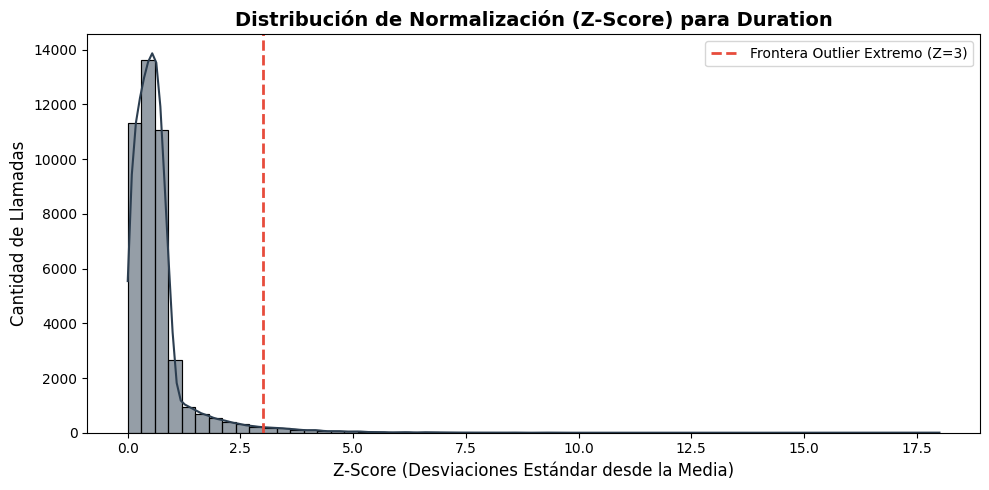

In [110]:
# DETECCIÓN DE OUTLIERS: continuación Método 2 - Z-Score (Desviaciones estándar desde la media)
# Visualización de la distribución de 'duration'

plt.figure(figsize=(10, 5))
sns.histplot(data=df_total_wipclean_iii, x='z_score_duration', bins=60, kde=True, color='#2c3e50')

# Dibujamos la frontera estadística del Outlier (Z=3)
plt.axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='Frontera Outlier Extremo (Z=3)')

plt.title('Distribución de Normalización (Z-Score) para Duration', fontsize=14, fontweight='bold')
plt.xlabel('Z-Score (Desviaciones Estándar desde la Media)', fontsize=12)
plt.ylabel('Cantidad de Llamadas', fontsize=12)
plt.legend()
plt.tight_layout()
save_plot('Distribucion_Zscore_Duration', plt.gcf())
plt.show()

**El IQR puede ser  demasiado estricto (3055 outliers):**

 El límite del IQR es 644.50 segundos ( 10.7 minutos).
 En el sector bancario, una llamada de 11 minutos podría considerarse normal ( porque te están explicando un producto). 
 No se desea asumir ese riesgo, a menos que el estudio lo requiera, ya que implicaría Borrar a 3000 clientes por hablar 11 minutos.
 Esto demuestra que duration no tiene una distribución simétrica, sino una larga cola hacia la derecha (Distribución Exponencial).

**El Z-Score parece más adecuado** 

Muestra la verdadera anomalía (889 outliers): Esos 889 registros son llamadas verdaderamente extremas (de > 40 minutos, 1 hora o puediendo ser casos donde se ha dejado una llamada descolgado, por plantear una hipotesis para los outliers más extremos).

In [111]:
# DEFINIMOS LA MÁSCARA (necesario para el análisis de impacto posterior)
mask_outliers = df_total_wipclean_iii['z_score_duration'] > 3

#Análisis de Impacto y Jutificación de Negocio ( cuadro z=3)

total_registros = len(df_total_wipclean_iii)
outliers_count = mask_outliers.sum()
normales_count = total_registros - outliers_count

# 1. Resumen global en Porcentajes
df_resumen_z3 = pd.DataFrame({
    'Tipo de Llamada': ['Estándar (Z <= 3)', 'Extrema / Outlier (Z > 3)'],
    'Cantidad': [normales_count, outliers_count],
    'Porcentaje del Total (%)': [(normales_count/total_registros)*100, (outliers_count/total_registros)*100]
})

print("\n--- Impacto del Umbral Z=3 en el Dataset ---")
display(df_resumen_z3.round(2))

# 2. Resumen Agrupado: ¿Quiénes hacen estas llamadas tan largas?
# Agrupamos los outliers por la columna 'job' para ver su distribución interna
print("\n--- Distribución de las Llamadas Extremas por Profesión ---")
distribucion_outliers = df_total_wipclean_iii[mask_outliers]['job'].value_counts(normalize=True) * 100
df_dist_outliers = distribucion_outliers.to_frame(name='Porcentaje dentro del grupo Z>3 (%)').round(2)
display(df_dist_outliers.head(5)) # Mostramos solo el Top 5 para no saturar
# ------------------------------------------------------------------------------


--- Impacto del Umbral Z=3 en el Dataset ---


,Tipo de Llamada,Cantidad,Porcentaje del Total (%)
0,Estándar (Z <= 3),41811,97.92
1,Extrema / Outlier (Z > 3),889,2.08



--- Distribución de las Llamadas Extremas por Profesión ---


,Porcentaje dentro del grupo Z>3 (%)
job,
admin.,26.21
blue-collar,25.08
technician,15.86
services,8.32
management,6.19


### *WINSORIZACIÓN (CAPPING) por Z-SCORE* ###

Solución de Outliers en  'duration':
Al se una variable crucial para el análisis de campañas,
#y que los outliers pueden distorsionar significativamente los resultados, optamos por una estrategia de normalización robusta en lugar de eliminación directa.

In [112]:
# tambien tenemos :from scipy.stats.mstats import winsorize , pero no lo usamos 

# ==============================================================================
# Despejamos el valor real en segundos que equivale a un Z-Score de 3
limite_maximo_z3 = (3 * std_duracion) + media_duracion

# Contamos cuántos superan la frontera
outliers_zscore =(df_total_wipclean_iii['z_score_duration']>3).sum()

print(f"\n--- Resultados de Detección ---")
print(f"Límite máximo definido por Z=3: {limite_maximo_z3:.2f} segundos ({limite_maximo_z3/60:.2f} minutos)")
print(f"Total de Outliers extremos detectados: {outliers_zscore} llamadas")



--- Resultados de Detección ---
Límite máximo definido por Z=3: 1034.33 segundos (17.24 minutos)
Total de Outliers extremos detectados: 889 llamadas


In [113]:

# 2. Banderas de trazabilidad y Aplicación del Capping
df_total_wipclean_iii['is_duration_capped'] = False
mask_outliers = df_total_wipclean_iii['z_score_duration'] > 3

# Marcamos y topamos los valores extremos

# Banderas de trazabilidad y Aplicación del Capping
df_total_wipclean_iii['is_duration_capped'] = False
mask_outliers = df_total_wipclean_iii['z_score_duration'] > 3

# Topamos los valores usando el límite calculado
df_total_wipclean_iii.loc[mask_outliers, 'is_duration_capped'] = True

# Actualizamos la columna operativa 'duration' limitando los outliers
# (Usamos el backup original para aplicar el límite, asegurando que re-ejecutar no estropee los datos)
df_total_wipclean_iii['duration'] = df_total_wipclean_iii['duration_original'].where(~mask_outliers, limite_maximo_z3)

print(f"\nSe han 'winsorizado' (limitado) {df_total_wipclean_iii['is_duration_capped'].sum()} llamadas extremas.")


Se han 'winsorizado' (limitado) 889 llamadas extremas.


In [114]:
#Muestra de las llamadas que fueron capadas para validar que el proceso se aplicó correctamente, y ver la diferencia entre el valor original y el nuevo valor limitado.
df_total_wipclean_iii[df_total_wipclean_iii['is_duration_capped']==True][['duration', 'duration_original', 'z_score_duration','is_duration_capped']].sample(5, random_state=42)

,duration,duration_original,z_score_duration,is_duration_capped
13799,1034.333595,1389,4.370251,True
19066,1034.333595,2191,7.468771,True
1987,1034.333595,1111,3.296200,True
18156,1034.333595,1088,3.207340,True
26965,1034.333595,1074,3.153251,True


Leyenda de Columnas vinculadas a esta limpieza :
###  Diccionario de Columnas de Trazabilidad e Infraestructura

Para garantizar la reproducibilidad, auditoría y reversibilidad del *pipeline* de datos, se han conservado todas las variables auxiliares creadas durante la fase de saneamiento. A continuación se detalla el propósito de cada una:

| Columna | Tipo de Dato | Descripción / Propósito Estadístico |
| :--- | :--- | :--- |
| **`index_merge_original`** | `int64` | **El "DNI" absoluto del registro.** Conserva el índice nativo de la fila inmediatamente después del *merge* inicial de los 43.000 registros, permitiendo rastrear el origen antes de cualquier purga. |
| **`orden_original`** | `int64` | **Ancla operacional.** Creada inmediatamente después de eliminar los 300 registros nulos estructurales. Funciona como el índice base de trabajo (0 al 42699) para devolver al dataset a su posición natural tras ordenamientos cronológicos. |
| **`is_imputed`** | `bool` | **Bandera de control demográfico.** Indica con `True` si el valor de la edad (`age`) del cliente era originalmente nulo y fue estimado mediante la mediana contextual. |
| **`other_mainimputed`** | `bool` | **Bandera de control de perfil.** Indica con `True` si el registro requirió la imputación de variables categóricas principales como el estado civil (`marital`) o la profesión (`job`) mediante la moda general. |
| **`is_geo_imputed`** | `bool` | **Bandera de control espacial.** Indica con `True` si las coordenadas (`latitude` o `longitude`) presentaban valores nulos o geográficamente imposibles y tuvieron que ser corregidas mediante la Mediana Marginal del banco. |
| **`duration_original`** | `float64`| **Respaldo del dato crudo.** Almacena el tiempo real e intacto (en segundos) de la duración de la llamada telefónica, garantizando la reversibilidad del proceso de limpieza. |
| **`is_duration_capped`** | `bool` | **Bandera de control de comportamiento.** Marca con `True` a los registros identificados como *outliers* extremos (Z-Score > 3) cuya variable operativa `duration` fue limitada mediante un proceso de Winsorización. |

In [115]:
#Revisamos la estructura de nuestra data para guardar el nuevo bloque espacial y temporal limpio, con sus respectivas banderas de trazabilidad.
df_total_wipclean_iii.info()

<class 'pandas.DataFrame'>
RangeIndex: 42700 entries, 0 to 42699
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Unnamed: 0_x               42700 non-null  int64         
 1   age                        42700 non-null  float64       
 2   job                        42700 non-null  str           
 3   marital                    42700 non-null  str           
 4   education                  42700 non-null  str           
 5   default                    42700 non-null  object        
 6   housing                    42700 non-null  object        
 7   loan                       42700 non-null  object        
 8   contact                    42700 non-null  str           
 9   duration                   42700 non-null  float64       
 10  campaign                   42700 non-null  int64         
 11  pdays                      42700 non-null  int64         
 12  previous       

 ### *Cierre de Pipeline _ Exportación completa a processed data* ###

[ Capa RAW ]            -->      [ Capa STAGING ]               -->      [ Capa PRODUCTION ]
raw_bank & raw_customers          stg_total_bank_customer                 prd_marketing_cleaned
(Datos brutos e inconexos)       (Cruce unificado, aún sucio)            (Dato maestro, auditable y listo)

In [116]:
# Cierre de Pipeline - Exportación completa a processed data
# En este punto, el dataset ha pasado por una limpieza exhaustiva de sus bloques financiero, temporal y espacial,
# con trazabilidad total en cada paso.
# ------------------------------------------------------------------------
# import os

# 1. Congelamos el DataFrame con todo su linaje y columnas de control
df_cleaned_marketing = df_total_wipclean_iii.copy()

print(f"Dimensiones finales del dataset procesado: {df_cleaned_marketing.shape}")

# 2. Copia de seguridad física en el sistema de archivos
ruta_procesados = '../data/processed'
os.makedirs(ruta_procesados, exist_ok=True)
ruta_archivo_final = f'{ruta_procesados}/dataset_marketing_cleaned_v1.csv'

df_cleaned_marketing.to_csv(ruta_archivo_final, index=False, sep=';', decimal=',')
print(f"-> Archivo físico guardado en: {ruta_archivo_final}")

# 3. Persistencia en la Base de Datos: Creación de la Capa de Producción
# Elegimos un nombre que refleje el estado "Production" o "Cleaned" del dato
tabla_produccion = 'prd_marketing_cleaned'
print(f"-> Volcando datos refinados en la tabla SQL '{tabla_produccion}'...")

df_cleaned_marketing.to_sql(tabla_produccion, engine, if_exists='replace', index=False)

# 4. Validación de Integridad (Check de conciliación)
filas_en_db = pd.read_sql(f"SELECT COUNT(*) FROM {tabla_produccion}", engine).iloc[0, 0]

if filas_en_db == len(df_cleaned_marketing):
    print(f"\n¡ÉXITO! El pipeline ha concluido.")
    print(f"Las {filas_en_db} filas están disponibles y conciliadas en la tabla '{tabla_produccion}'.")
else:
    print(f"\n ALERTA: Descuadre en la carga. Pandas: {len(df_cleaned_marketing)} | SQL: {filas_en_db}")

Dimensiones finales del dataset procesado: (42700, 47)
-> Archivo físico guardado en: ../data/processed/dataset_marketing_cleaned_v1.csv
-> Volcando datos refinados en la tabla SQL 'prd_marketing_cleaned'...

¡ÉXITO! El pipeline ha concluido.
Las 42700 filas están disponibles y conciliadas en la tabla 'prd_marketing_cleaned'.


## *Análisis Exploratorio* ##



### *Configuración del estilo* ###

In [117]:
# Configuración de estilo global
sns.set_theme(style="whitegrid")

# Paleta Corporativa Bancaria
color_banco = "#2c3e50"     # Azul oscuro (Para análisis generales / univariantes)
color_destaque = "#f39c12"  # Naranja (Para resaltar un insight específico)

# Paleta Semántica para la variable objetivo 'y' (Suscripción)
# Verde para éxito ('yes'), Rojo/Grisáceo para rechazo ('no')
paleta_target = {'yes': '#27ae60', 'no': '#e74c3c'} 
paleta_target_suave = {'yes': '#2ecc71', 'no': '#bdc3c7'} # Ideal para fondos grandes

# Aplicamos colores por defecto
sns.set_palette([color_banco, color_destaque])

### *Identificación de Patrones (Tendencias y Distribuciones)*  

De acuerdo con la metodología EDA, comenzaremos analizando las tendencias generales y la forma de nuestros datos.

In [118]:
# 1. Configuración del entorno y Carga de Datos
# ----------------------------------------------------- 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo global para un acabado profesional
sns.set_theme(style="whitegrid", context="notebook")

# Paletas de colores
color_banco = "#34495e"     # Azul grisáceo más suave para que no sature
paleta_target = {'yes': '#81b29a', 'no': '#e07a5f'} # Verde salvia y terracota mate


In [119]:

# Cargamos el dataset desde nuestra capa de producción (Ajusta la ruta si es necesario)
ruta_archivo = '../data/processed/dataset_marketing_cleaned_v1.csv'
df_eda = pd.read_csv(ruta_archivo, sep=';', decimal=',')

print(f"Dataset cargado exitosamente. Dimensiones: {df_eda.shape}")


Dataset cargado exitosamente. Dimensiones: (42700, 47)


In [120]:


# 2. Patrones Generales : Distribución de la Variable Objetivo ('y')
# -------------------------------------------------------------------
# Calculamos los porcentajes exactos
total_clientes = len(df_eda)
conteo_y = df_eda['y'].value_counts()
porcentajes_y = (conteo_y / total_clientes) * 100

print("\n--- Tasa de Conversión Global ---")
display(porcentajes_y.round(2).to_frame(name='Porcentaje (%)'))



--- Tasa de Conversión Global ---


,Porcentaje (%)
y,
no,88.74
yes,11.26


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribucion_variable_objetivo_y.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribucion_variable_objetivo_y.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


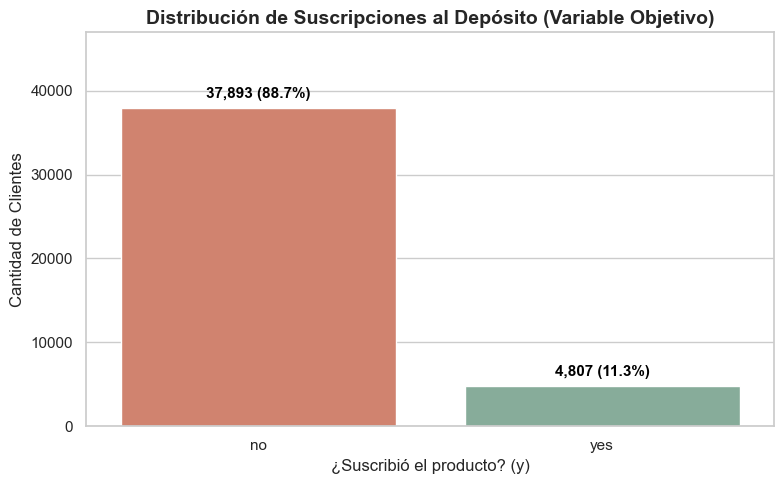

In [121]:
# Visualización del desbalanceo
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_eda, x='y', hue='y', palette=paleta_target, order=['no', 'yes'], legend=False)

# Añadimos las etiquetas de datos sobre las barras
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:,.0f} ({altura/total_clientes*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribución de Suscripciones al Depósito (Variable Objetivo)', fontsize=14, fontweight='bold')
plt.xlabel('¿Suscribió el producto? (y)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.ylim(0, df_eda.shape[0] * 1.1) # Damos un poco de aire arriba para la etiqueta
plt.tight_layout()

save_plot('Distribucion_variable_objetivo_y', plt.gcf())

plt.show()

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribuciones_demograficas_edad_ingresos.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribuciones_demograficas_edad_ingresos.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


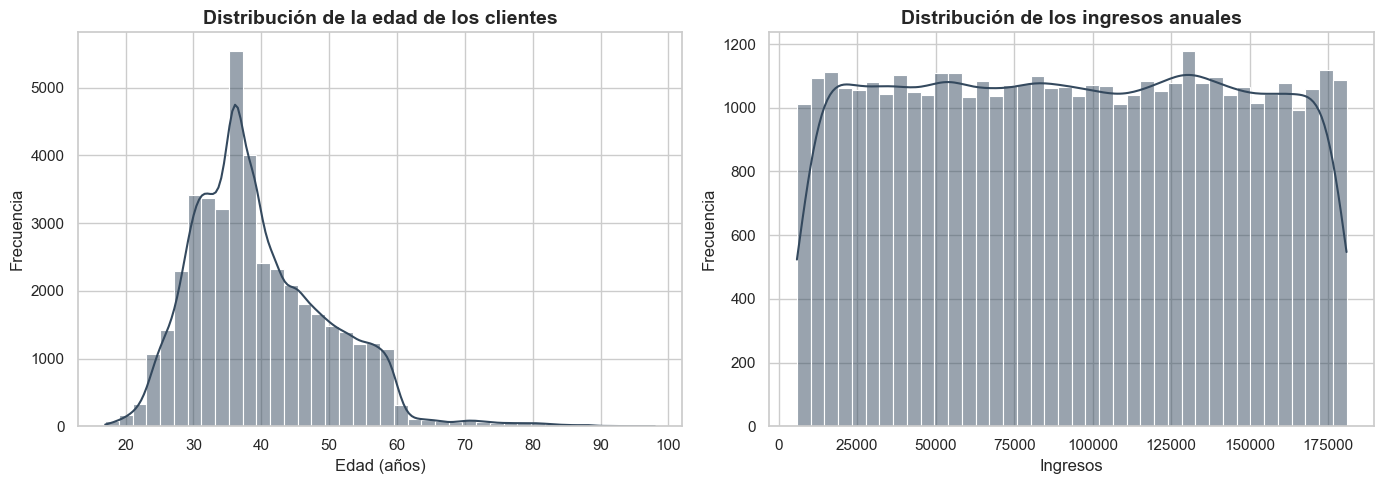


--- Estadísticas descriptivas clave ---


,age,Income
count,42700.0,42700.0
mean,39.8,93274.0
std,10.0,50500.6
min,17.0,5841.0
25%,33.0,49667.8
50%,38.0,93071.5
75%,46.0,136775.5
max,98.0,180802.0


In [122]:
# 3. Patrones generales: Distribuciones demográficas (edad e ingresos)
# ------------------------------------------------------------------------
# Configuramos el lienzo para dos gráficos en paralelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de la edad
sns.histplot(data=df_eda, x='age', bins=40, kde=True, color=color_banco, ax=axes[0])
axes[0].set_title('Distribución de la edad de los clientes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Edad (años)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# Gráfico 2: Distribución de los ingresos
sns.histplot(data=df_eda, x='Income', bins=40, kde=True, color=color_banco, ax=axes[1])
axes[1].set_title('Distribución de los ingresos anuales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ingresos', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
save_plot('Distribuciones_demograficas_edad_ingresos', plt.gcf())
plt.show()

# Análisis estadístico rápido para respaldar las gráficas
print("\n--- Estadísticas descriptivas clave ---")
display(df_eda[['age', 'Income']].describe().round(1))


Identificación de patrones: Distribuciones demográficas

- Edad (age): Observamos una distribución ligeramente asimétrica hacia la derecha. El núcleo principal de nuestra base de datos se concentra entre los 32 y los 47 años, con una media cercana a los 40 años. Las caídas en los extremos indican que tenemos poca penetración en perfiles muy jóvenes (menores de 25) y en la tercera edad.

- Ingresos (Income): La distribución presenta una forma que se aproxima a la normalidad en su campana central, aunque con una ligera cola hacia la derecha (asimetría positiva), reflejando que la mayoría de los clientes se agrupan en tramos de ingresos medios, mientras que una minoría alcanza los rangos más altos.



✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribucion_profesion_estado_civil.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Distribucion_profesion_estado_civil.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


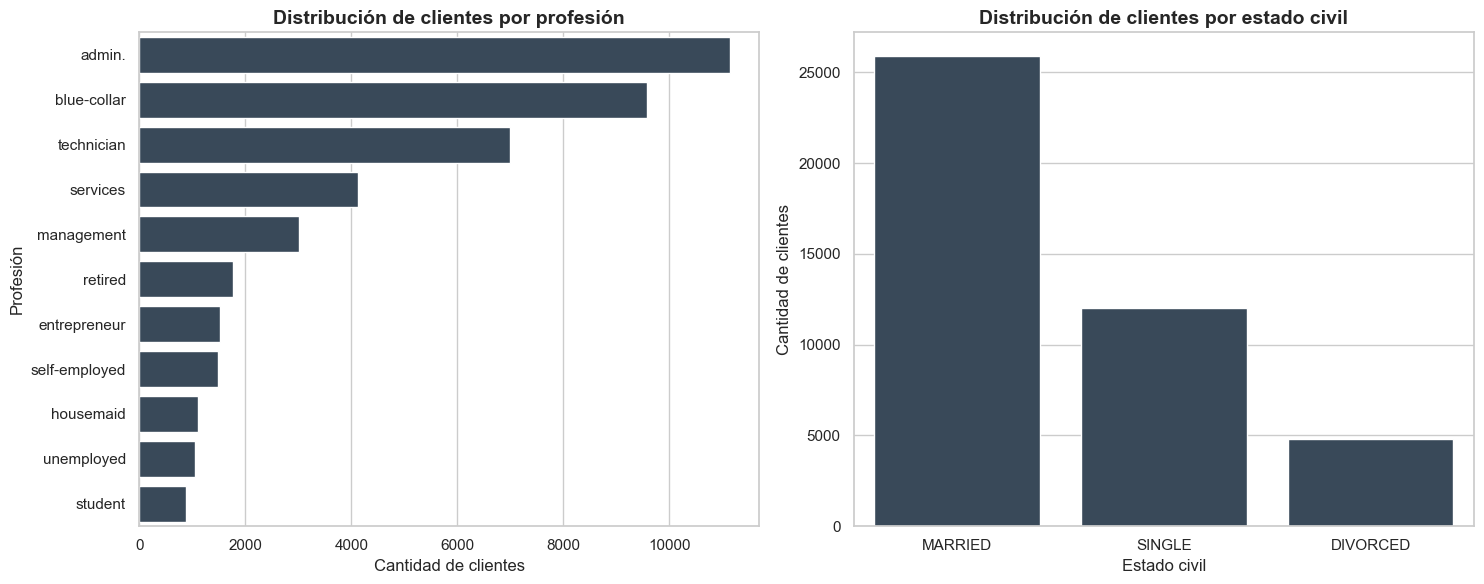


--- Top 3 profesiones en la base de datos ---


,Porcentaje (%)
job,
admin.,26.1
blue-collar,22.4
technician,16.4


In [123]:
#4. Patrones generales: Distribución de profesiones y estado civil
#------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Profesión (job) - Barras horizontales ordenadas
orden_profesiones = df_eda['job'].value_counts().index
sns.countplot(data=df_eda, y='job', order=orden_profesiones, color=color_banco, ax=axes[0])
axes[0].set_title('Distribución de clientes por profesión', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=12)
axes[0].set_ylabel('Profesión', fontsize=12)

# Gráfico 2: Estado civil (marital) - Barras verticales ordenadas
orden_estado_civil = df_eda['marital'].value_counts().index
sns.countplot(data=df_eda, x='marital', order=orden_estado_civil, color=color_banco, ax=axes[1])
axes[1].set_title('Distribución de clientes por estado civil', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estado civil', fontsize=12)
axes[1].set_ylabel('Cantidad de clientes', fontsize=12)

plt.tight_layout()
save_plot('Distribucion_profesion_estado_civil', plt.gcf())
plt.show()

# Extraemos los porcentajes del Top 3 de profesiones para el análisis
print("\n--- Top 3 profesiones en la base de datos ---")
top3_job = (df_eda['job'].value_counts(normalize=True) * 100).head(3).round(1)
display(top3_job.to_frame(name='Porcentaje (%)'))

Al analizar las variables categóricas principales, el patrón estructural de la base de clientes queda claramente definido:

- Profesión: Existe una fuerte concentración en sectores administrativos (admin.), obreros/cuello azul (blue-collar) y técnicos (technician). Estos tres grupos componen el grueso de nuestra cartera objetivo, lo que indica un perfil de cliente de clase trabajadora y media.

- Estado civil: La inmensa mayoría de los clientes están casados (married), seguidos a bastante distancia por los solteros (single). Esto, cruzado con la media de edad (40 años), nos dibuja a un cliente tipo en fase de consolidación familiar, lo cual es fundamental para entender su aversión al riesgo a la hora de contratar depósitos.

## Identificación de Anomalías: 'duration' y contexto macroeconómico ##

Validación visual de las decisiones tomadas durante el limpieza y análisis de valores extremos válidos.

El impacto de la llamada (duration): Visualización mediante Boxplots de la variable duration. Demostración visual de por qué aplicamos el límite (winsorización) a los 1.266 registros atípicos (Anomalías Contextuales).

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Comparacion_duracion_original_tratada.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Comparacion_duracion_original_tratada.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


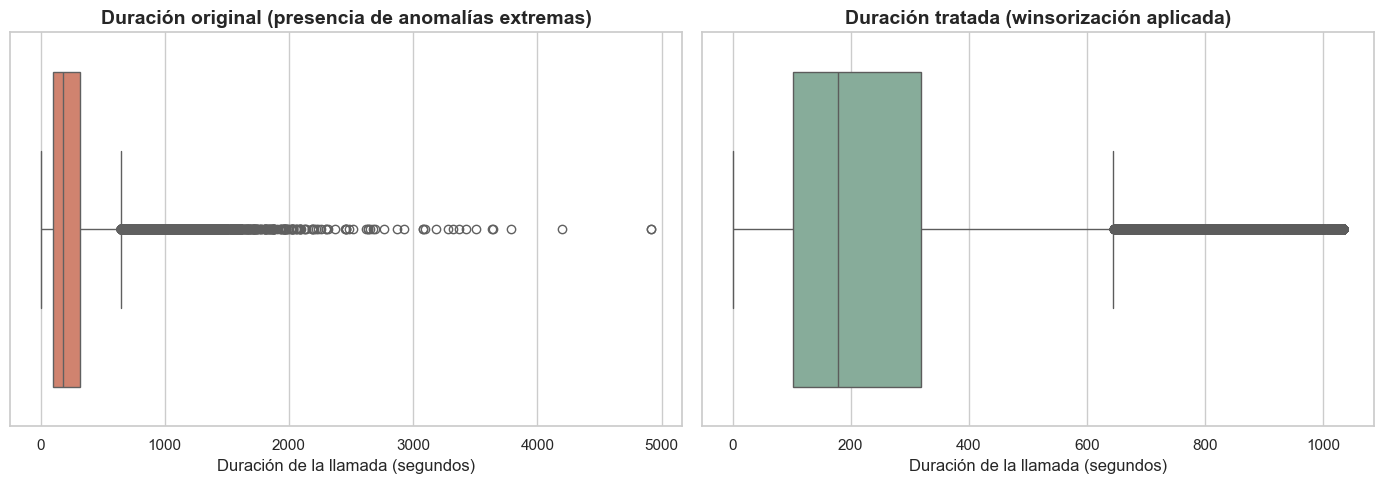

In [124]:
# 5. Identificación de anomalías: Tratamiento de la duración de llamada
#------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: El dato crudo (con los outliers extremos)
sns.boxplot(data=df_eda, x='duration_original', color="#e07a5f", ax=axes[0])
axes[0].set_title('Duración original (presencia de anomalías extremas)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duración de la llamada (segundos)', fontsize=12)

# Gráfico 2: El dato procesado (después del capping en Z=3)
sns.boxplot(data=df_eda, x='duration', color="#81b29a", ax=axes[1])
axes[1].set_title('Duración tratada (winsorización aplicada)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duración de la llamada (segundos)', fontsize=12)

plt.tight_layout()
save_plot('Comparacion_duracion_original_tratada', plt.gcf())
plt.show()


Anomalías en la interacción (duration): El análisis de cajas (boxplot) de la duración original revelaba una distorsión crítica: llamadas que superaban los 4.000 segundos (más de una hora), extendiendo la cola derecha de forma antinatural. Estas anomalías, probablemente operativas, alteraban la varianza. El segundo gráfico demuestra el éxito de la Winsorización (Z=3), conteniendo los valores extremos dentro de un límite realista (aprox. 1.000 segundos) sin eliminar la valiosa señal de esas interacciones largas.

Contexto Macroeconómico: Análisis de dispersión (Scatter plots) para detectar cómo se agrupan los clientes frente a las tasas de empleo (emp.var.rate) y el Euribor (euribor3m).

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Contexto_macroeconomico_emp_var_rate_vs_euribor3m.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Contexto_macroeconomico_emp_var_rate_vs_euribor3m.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


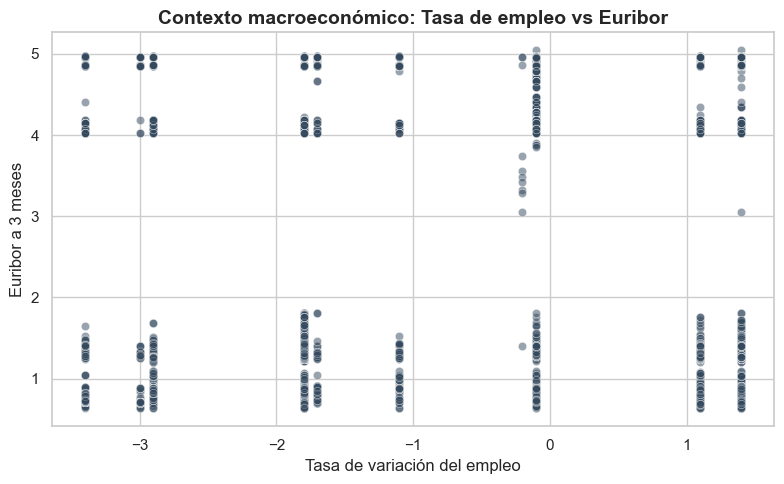

In [125]:

# Contexto macroeconómico: Agrupaciones y dispersión

#------------------------------------------------------------------
# 6. Identificación de contexto: Relación macroeconómica
#------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x='emp.var.rate', y='euribor3m', color=color_banco, alpha=0.5)
plt.title('Contexto macroeconómico: Tasa de empleo vs Euribor', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de variación del empleo', fontsize=12)
plt.ylabel('Euribor a 3 meses', fontsize=12)
plt.tight_layout()
save_plot('Contexto_macroeconomico_emp_var_rate_vs_euribor3m', plt.gcf())
plt.show()

En el eje Y (Euribor a 3 meses). Hay un bloque de puntos arriba (entre el 3.5 y el 5) y otro bloque masivo abajo (entre el 0.5 y el 1.8). Y un hueco enorme en el medio que puede entenderse  que la campaña del banco duró varios años y atravesó un cambio económico radical (muy típico del impacto de la crisis financieras, por ejemplo?)

Bloque superior: Hubo meses donde el dinero estaba muy caro (Euribor alto, casi al 5%).

Bloque inferior: Hubo meses donde los tipos de interés se desplomaron.

***Suposición macroeconómica a verificar: > Los entornos de tipos de interés altos (Euribor cercano al 5%) incentivaron una mayor contratación de depósitos a plazo debido al atractivo de la rentabilidad bloqueada, en comparación con entornos de tipos bajos (Euribor inferior al 2%).

Contexto macroeconómico: El gráfico de dispersión revela un claro patrón de agrupación (clustering natural) en los indicadores externos. La tasa de empleo y el Euribor no se distribuyen de forma aleatoria, sino que forman bloques densos y escalonados. Esto nos indica que las campañas se lanzaron en "ventanas temporales" económicas muy concretas y polarizadas (momentos de tasas altas vs. tasas bajas).

## Verificación de suposiciones ##

Se evalua en dos bloques: 
- el perfil generacional ( edad vs suscripción)
- el perfil demográfico/profesional (quién conforma ese 11% de éxito) 
- el perfil de carga familiar (si tener hijos influye en la decisión).


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Densidad_edad_por_suscripcion.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Densidad_edad_por_suscripcion.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


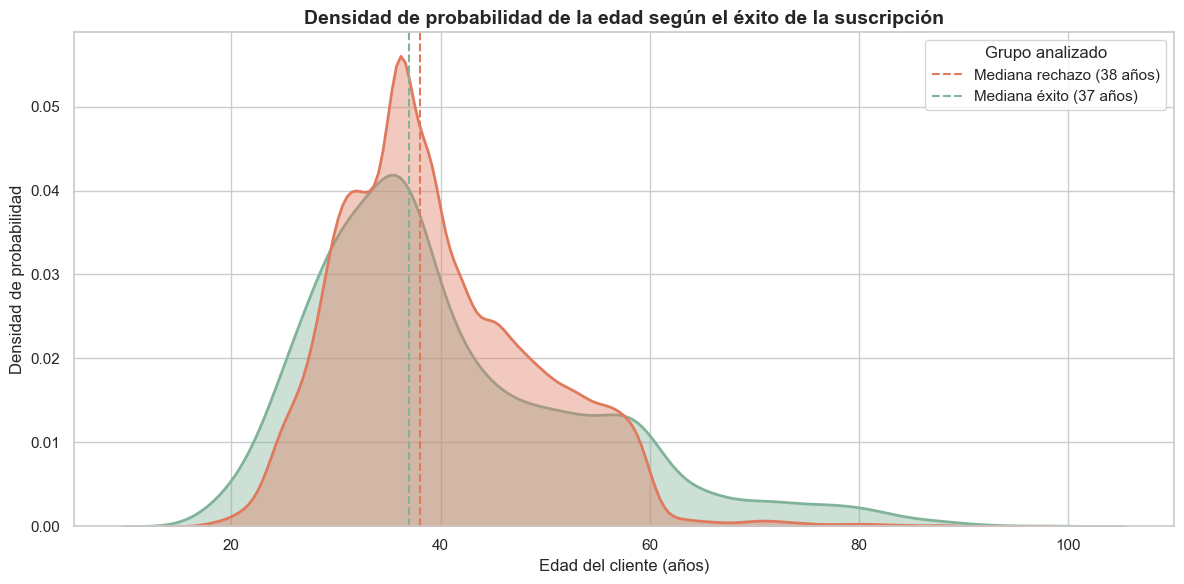


--- Tasa de conversión (%) por segmentos de edad específicos ---


y,yes
age_group,
<25 jóvenes,21.4
25-30 junior,13.2
31-45 maduros,9.6
46-60 senior,9.9
>60 jubilación,44.8


In [126]:
# 
# 7. Verificación de suposiciones: El factor generacional (Edad vs Suscripción)
# -----------------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Pintamos las curvas de densidad suavizadas para 'yes' y 'no'
sns.kdeplot(data=df_eda, x='age', hue='y', palette=paleta_target, fill=True, common_norm=False, alpha=0.4, linewidth=2)

# Calculamos las medianas de cada grupo para usarlas como líneas de control visual
mediana_no = df_eda[df_eda['y'] == 'no']['age'].median()
mediana_yes = df_eda[df_eda['y'] == 'yes']['age'].median()

# Añadimos líneas verticales discontinuas para marcar las medianas
plt.axvline(mediana_no, color=paleta_target['no'], linestyle='--', linewidth=1.5, label=f'Mediana rechazo ({mediana_no:.0f} años)')
plt.axvline(mediana_yes, color=paleta_target['yes'], linestyle='--', linewidth=1.5, label=f'Mediana éxito ({mediana_yes:.0f} años)')

plt.title('Densidad de probabilidad de la edad según el éxito de la suscripción', fontsize=14, fontweight='bold')
plt.xlabel('Edad del cliente (años)', fontsize=12)
plt.ylabel('Densidad de probabilidad', fontsize=12)

# Reconfiguramos la leyenda para que incluya las líneas de las medianas de forma limpia
plt.legend(title='Grupo analizado')
plt.tight_layout()
save_plot('Densidad_edad_por_suscripcion', plt.gcf())
plt.show()

# Resumen numérico de soporte (Agrupamiento descriptivo por tramos de edad clave)
print("\n--- Tasa de conversión (%) por segmentos de edad específicos ---")
df_eda['age_group'] = pd.cut(df_eda['age'], bins=[0, 25, 30, 45, 60, 100], labels=['<25 jóvenes', '25-30 junior', '31-45 maduros', '46-60 senior', '>60 jubilación'])
tabla_edad = pd.crosstab(df_eda['age_group'], df_eda['y'], normalize='index') * 100
display(tabla_edad[['yes']].round(1))

Superponemos la distribución de los rechazos y los éxitos en las suscripciónes según edad. 

Las medianas de edad de ambos grupos se sitúan de forma casi idéntica (38 años para el rechazo y 37 años para el éxito), compartiendo un pico de volumen central en el tramo de los 35 a 45 años debido al diseño de muestreo del banco. Sin embargo, el análisis del comportamiento relativo de las curvas revela dos ventajas competitivas evidentes en las colas de la distribución.

 **Comportamiento en las colas de la distribución:**
1. **Segmento joven (<28 años):** La curva de éxito (`yes`) se posiciona  por encima de la curva de rechazo (`no`). Dentro de su volumen de llamadas, los perfiles jóvenes muestran mayor receptividad a la media de la campaña.
2. **Segmento senior (>60 años):** Se observa el patrón más nítido de toda la distribución. A partir de la edad de jubilación, la curva de rechazo se deprime por completo mientras que la curva verde de éxito genera una meseta extendida de alta probabilidad.

**Explicación y justificación de negocio:**  
 El tramo central de la pirámide (32-58 años) concentra la masa crítica de llamadas pero sufre una penalización de rechazo (dominio de la curva terracota).  
 Esto se debe a que la población activa cuenta con menor tiempo de atención telefónica y mayores cargas financieras vivas (hipotecas, préstamos activos). 

 En contraste, los márgenes demográficos (juventud y jubilación) disponen de mayor apertura para escuchar la propuesta. El esfuerzo de saneamiento aplicado sobre esta variable queda plenamente justificado al descubrir que la edad es uno de los predictores cualitativos más potentes de la campaña.


--- Tasa de conversión (%) por cada profesión ---


y,yes
job,
student,31.2
retired,25.1
unemployed,14.3
admin.,13.0
management,11.3
technician,10.9
self-employed,10.9
housemaid,9.8
entrepreneur,8.3


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Tasa_suscripcion_por_profesion.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Tasa_suscripcion_por_profesion.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


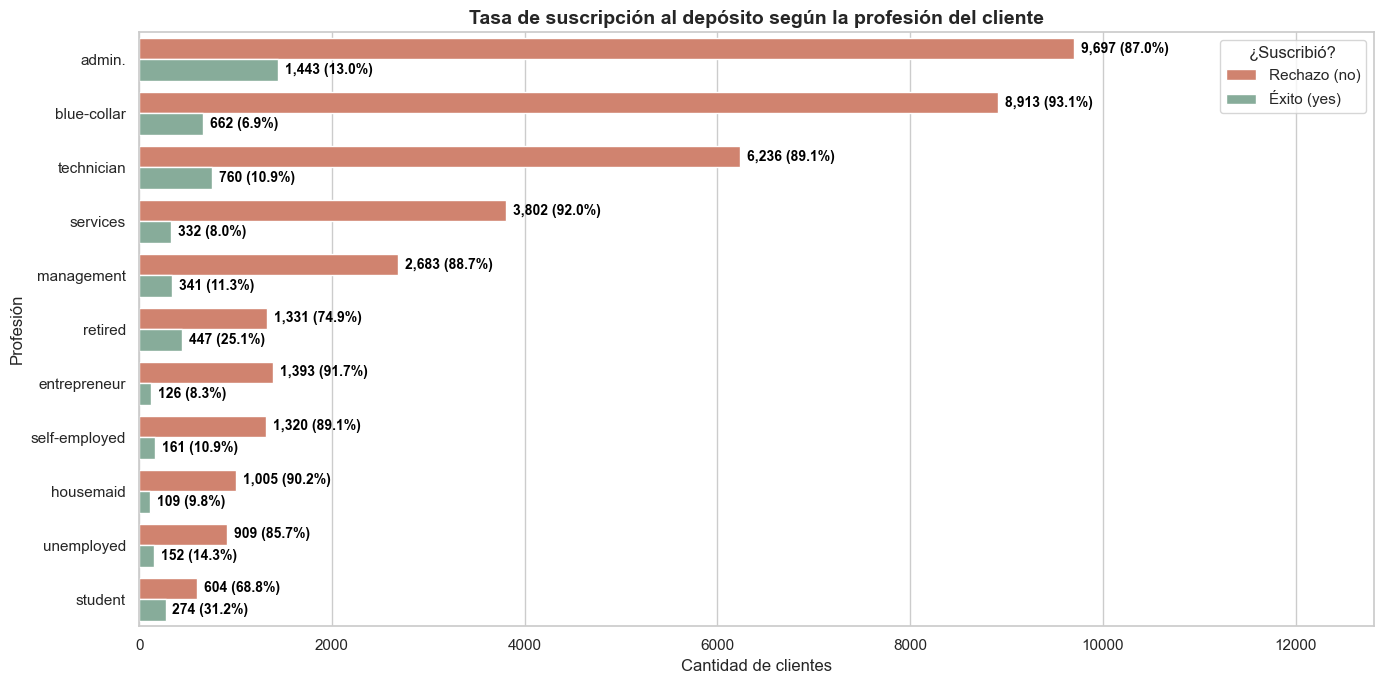

In [127]:
# 8. Verificación de suposiciones: Profesión vs Suscripción (Con porcentajes)
# ------------------------------------------------------------------------------------------

# Tabla de contingencia en porcentajes para ver la tasa real de éxito por grupo
print("\n--- Tasa de conversión (%) por cada profesión ---")
tabla_job = pd.crosstab(df_eda['job'], df_eda['y'], normalize='index') * 100
display(tabla_job[['yes']].round(1).sort_values(by='yes', ascending=False))
plt.figure(figsize=(14, 7))

#graficando

orden_job = df_eda['job'].value_counts().index
ax1 = sns.countplot(data=df_eda, y='job', hue='y', order=orden_job, palette=paleta_target)

# Calculamos el total por profesión para sacar el porcentaje relativo dentro de cada barra
totales_por_job = df_eda['job'].value_counts()

# Colocamos las etiquetas en las barras horizontales
for p in ax1.patches:
    ancho = p.get_width()
    if ancho > 0: # Evitamos errores si alguna barra está vacía
        # Conseguimos el nombre de la profesión según la posición vertical
        y_coord = p.get_y() + p.get_height() / 2.
        idx_job = int(round(y_coord))
        if idx_job < len(orden_job):
            nombre_job = orden_job[idx_job]
            total_grupo = totales_por_job[nombre_job]
            porcentaje = (ancho / total_grupo) * 100
            
            ax1.annotate(f'{ancho:,.0f} ({porcentaje:.1f}%)', 
                        (ancho, p.get_y() + p.get_height() / 2.), 
                        ha='left', va='center', fontsize=10, fontweight='bold', 
                        color='black', xytext=(5, 0), textcoords='offset points')

plt.title('Tasa de suscripción al depósito según la profesión del cliente', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de clientes', fontsize=12)
plt.ylabel('Profesión', fontsize=12)
plt.legend(title='¿Suscribió?', labels=['Rechazo (no)', 'Éxito (yes)'])
plt.xlim(0, df_eda['job'].value_counts().max() * 1.15) # Espacio para el texto
plt.tight_layout()
save_plot('Tasa_suscripcion_por_profesion', plt.gcf())
plt.show()


Aunque los sectores administrativos (admin.) y técnicos sostienen el negocio en volumen absoluto de captación debido al tamaño de su muestra, el análisis bivariante revela un patrón oculto de alta eficiencia en los nichos de estudiantes (student, 31.2%) y jubilados (retired, 25.1%). Ambos superan con creces la media general del 11.3%.

Recomendación: El negocio no debe abandonar las categorías mayoritarias, pero sí podría poner un énfasis inteligente en cubrir mejor estos dos nichos infrautilizados mediante campañas específicas, lo que elevaría la tasa total de suscripciones global con un coste de contacto muy bajo.

Línea de revisión cualitativa: Esta alta conversión puede estar fuertemente vinculada a un factor de comportamiento: una mayor ventana de tiempo libre y predisposición para atender y extender una llamada comercial telefónica. Se recomienda auditar en la siguiente sección si la duración media de la llamada (duration) en estos dos grupos es sistemáticamente más alta que en los perfiles activos laboralmente (como blue-collar, cuya conversión cae al 6.9%).

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Impacto_carga_familiar.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Impacto_carga_familiar.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


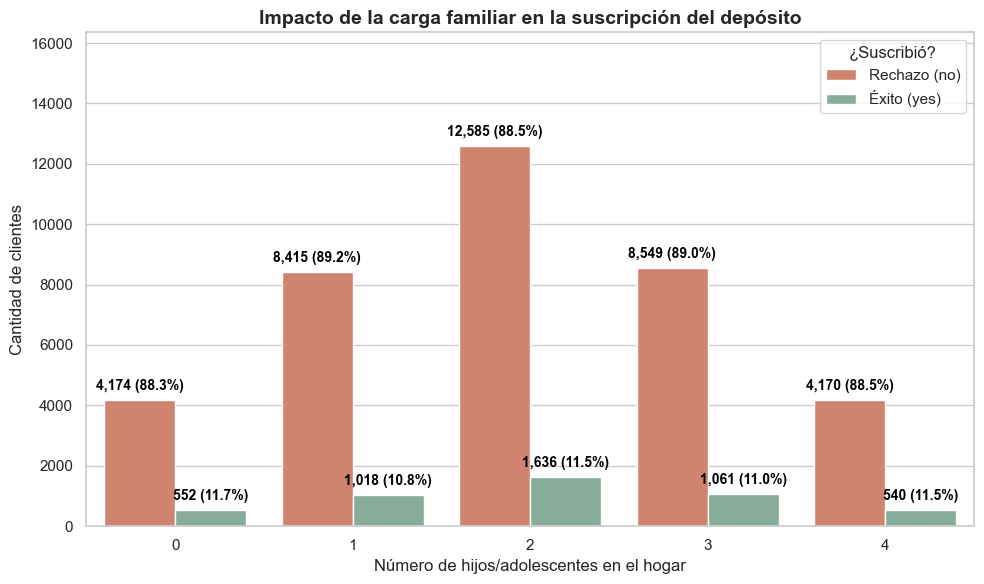

In [128]:
#
# 9. Verificación de suposiciones: Carga familiar con porcentajes
# ------------------------------------------------------------------------------------------
if 'total_kids' not in df_eda.columns:
    df_eda['total_kids'] = df_eda['Kidhome'] + df_eda['Teenhome']

plt.figure(figsize=(10, 6))
ax2 = sns.countplot(data=df_eda, x='total_kids', hue='y', palette=paleta_target)

totales_por_kids = df_eda['total_kids'].value_counts()

# Colocamos las etiquetas en las barras verticales
for p in ax2.patches:
    altura = p.get_height()
    if altura > 0:
        # Conseguimos el grupo de hijos según la posición horizontal
        x_coord = p.get_x() + p.get_width() / 2.
        grupo_kids = int(round(x_coord))
        if grupo_kids in totales_por_kids.index:
            total_grupo = totales_por_kids[grupo_kids]
            porcentaje = (altura / total_grupo) * 100
            
            ax2.annotate(f'{altura:,.0f} ({porcentaje:.1f}%)', 
                        (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold', 
                        color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Impacto de la carga familiar en la suscripción del depósito', fontsize=14, fontweight='bold')
plt.xlabel('Número de hijos/adolescentes en el hogar', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)
plt.legend(title='¿Suscribió?', labels=['Rechazo (no)', 'Éxito (yes)'])
plt.ylim(0, df_eda['total_kids'].value_counts().max() * 1.15)
plt.tight_layout()

save_plot('Impacto_carga_familiar', plt.gcf())
plt.show()


Los datos desmienten parcialmente la suposición inicial. Los hogares sin hijos (0) no muestran una ventaja masiva en conversión frente a los que tienen 1 o 2 hijos, manteniéndose todos en ratios estables cercanos al 10-11%. La carga familiar no actúa como un freno crítico para este producto financiero en específico.

### Verificación de hipótesis complementaria: Duración media por profesión ###

hipótesis : "convierten más los estudiantes y jubilados, porque atienden más tiempo la llamada"), ¡vamos a comprobar si los datos te dan la razón de inmediato!

Cruzamos en el siguiente bloque de código la profesión con la mediana de duración de la llamada para ver si estudiantes y jubilados son efectivamente los que más tiempo se quedan al teléfono.


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Duracion_llamada_por_profesion.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Duracion_llamada_por_profesion.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


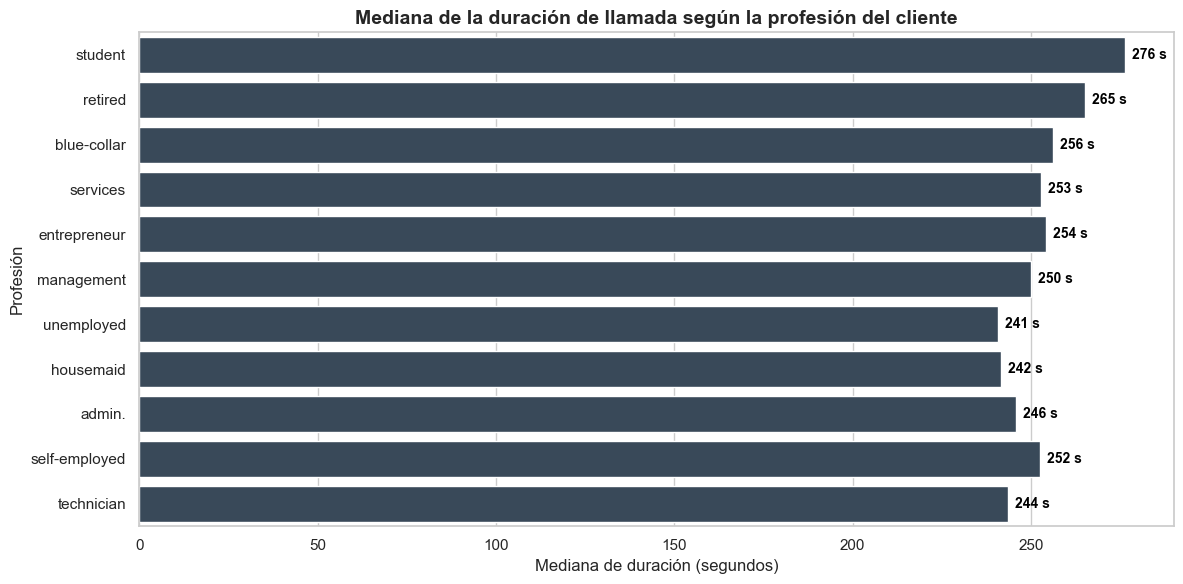

In [129]:
plt.figure(figsize=(12, 6))

# Calculamos la mediana de duración por profesión para ordenar el gráfico
orden_duracion = df_eda.groupby('job')['duration'].median().sort_values(ascending=False).index

sns.barplot(data=df_eda, y='job', x='duration', order=orden_duracion, color=color_banco, errorbar=None)

# Añadimos etiquetas de valor en segundos para precisión analítica
for p in plt.gca().patches:
    ancho = p.get_width()
    plt.gca().annotate(f'{ancho:.0f} s', 
                (ancho, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, fontweight='bold', 
                color='black', xytext=(5, 0), textcoords='offset points')

plt.title('Mediana de la duración de llamada según la profesión del cliente', fontsize=14, fontweight='bold')
plt.xlabel('Mediana de duración (segundos)', fontsize=12)
plt.ylabel('Profesión', fontsize=12)
plt.tight_layout()

save_plot('Duracion_llamada_por_profesion', plt.gcf())
plt.show()

### Verificación de suposiciones: Impacto del número de contactos (campaign) ###

VInculado al bloque (Duración por profesión)  añadimos la variable campaign (número de contactos o llamadas realizadas a un mismo cliente durante la campaña), y cruzamos con el 'éxito' para verificar la suposición del negocio de: 

¿Insistir demasiado funciona, o llega un punto en que saturamos al cliente y la conversión cae?

Vamos a agrupar los datos por la variable campaign y calcular qué porcentaje de éxito (yes) se logra en la primera llamada, en la segunda, en la tercera, etc., para ver el comportamiento de los grupos.


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Impacto_numero_contactos_campaign.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Impacto_numero_contactos_campaign.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


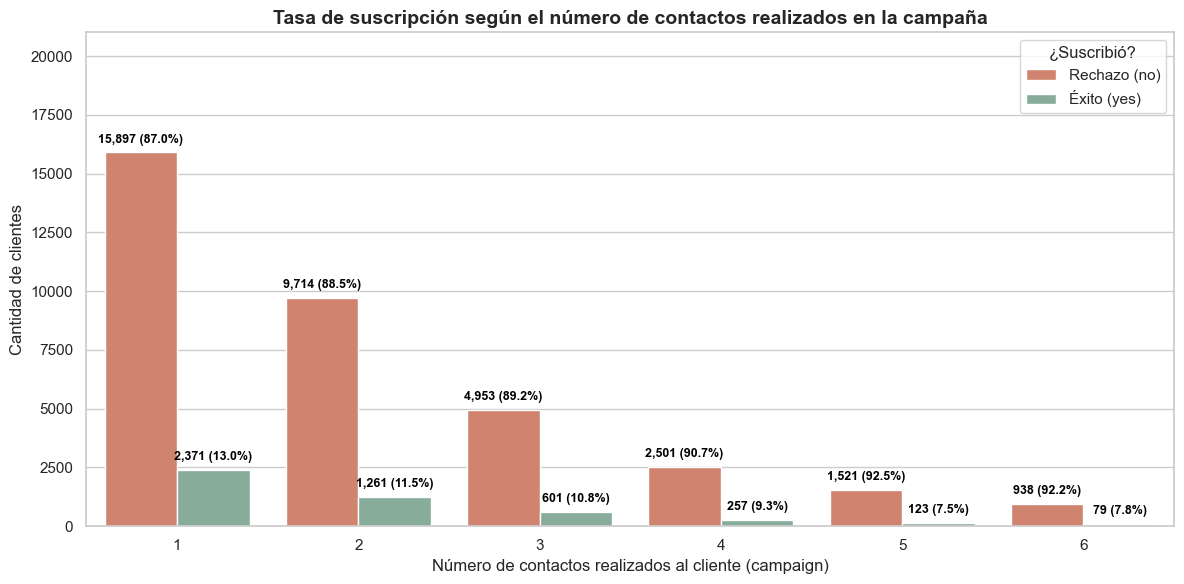

In [130]:
# 10. Verificación de suposiciones: Impacto del número de contactos (campaign)
# -------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Limitamos visualmente a un número razonable de contactos (ej. hasta 6) para ver la tendencia limpia
df_campaña_filtrada = df_eda[df_eda['campaign'] <= 6]

ax = sns.countplot(data=df_campaña_filtrada, x='campaign', hue='y', palette=paleta_target)

# Calculamos los totales por cada número de contacto para poner el porcentaje relativo
totales_por_contacto = df_eda['campaign'].value_counts()

for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        x_coord = p.get_x() + p.get_width() / 2.
        num_contacto = int(round(x_coord)) + 1 # El índice del eje X empieza en 0 (contacto 1)
        
        if num_contacto in totales_por_contacto.index:
            total_grupo = totales_por_contacto[num_contacto]
            porcentaje = (altura / total_grupo) * 100
            
            ax.annotate(f'{altura:,.0f} ({porcentaje:.1f}%)', 
                        (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='bottom', fontsize=9, fontweight='bold', 
                        color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Tasa de suscripción según el número de contactos realizados en la campaña', fontsize=14, fontweight='bold')
plt.xlabel('Número de contactos realizados al cliente (campaign)', fontsize=12)
plt.ylabel('Cantidad de clientes', fontsize=12)
plt.legend(title='¿Suscribió?', labels=['Rechazo (no)', 'Éxito (yes)'])
plt.ylim(0, df_campaña_filtrada['campaign'].value_counts().max() * 1.15)
plt.tight_layout()

save_plot('Impacto_numero_contactos_campaign', plt.gcf())
plt.show()

### Verificación de hipótesis operativo-demográfica: Contactos por profesión ###

✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Contactos_por_profesion.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Contactos_por_profesion.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


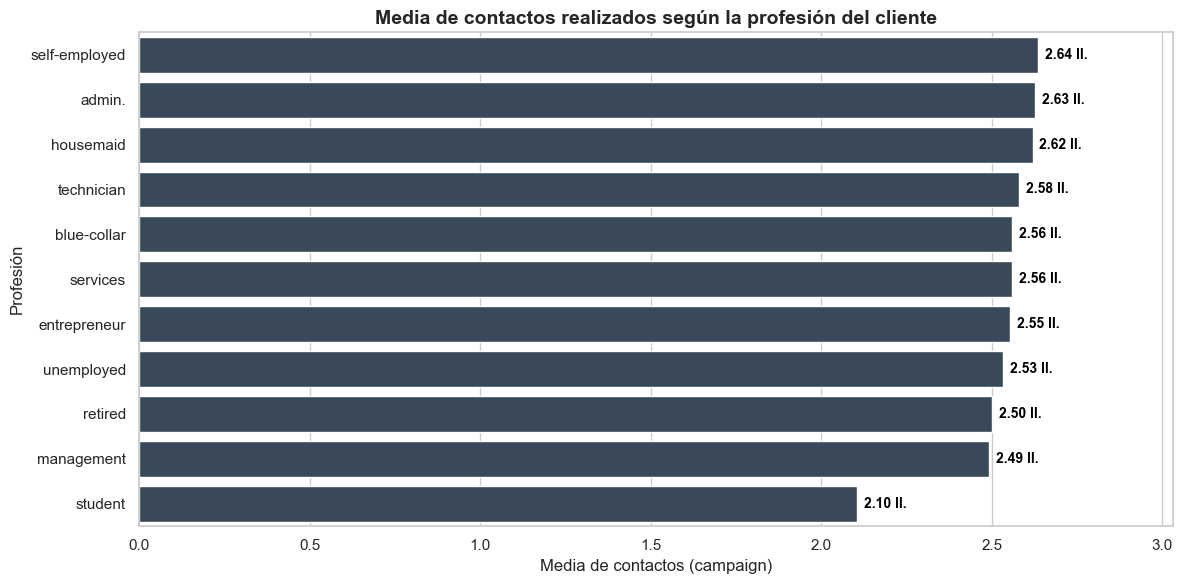

In [131]:
#
# 11. Verificación de hipótesis operativo-demográfica: Contactos por profesión
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Calculamos la media de contactos (campaign) por cada profesión para ordenar el gráfico
orden_contactos = df_eda.groupby('job')['campaign'].mean().sort_values(ascending=False).index

ax = sns.barplot(data=df_eda, y='job', x='campaign', order=orden_contactos, color=color_banco, errorbar=None)

# Añadimos las etiquetas con la media exacta de llamadas
for p in ax.patches:
    ancho = p.get_width()
    ax.annotate(f'{ancho:.2f} ll.', 
                (ancho, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, fontweight='bold', 
                color='black', xytext=(5, 0), textcoords='offset points')

plt.title('Media de contactos realizados según la profesión del cliente', fontsize=14, fontweight='bold')
plt.xlabel('Media de contactos (campaign)', fontsize=12)
plt.ylabel('Profesión', fontsize=12)
plt.xlim(0, df_eda.groupby('job')['campaign'].mean().max() * 1.15)
plt.tight_layout()

save_plot('Contactos_por_profesion', plt.gcf())
plt.show()

Si los estudiantes y los jubilados tienen una tasa de éxito tan alta, necesitamos comprobar si el equipo comercial ya se había dado cuenta de esto y los infló a llamadas (campaign), o si por el contrario a otros grupos los llamaron más veces de la cuenta, perdiendo tiempo y dinero.

Para cruzar la profesión con la media del número de llamadas, generamos un gráfico de barras que muestre exactamente el promedio de intentos que se llevó cada grupo.

Al analizar la media de intentos, se observa un patrón de fatiga comercial. 

Los grupos a los que más veces se les llamó de media (muchas veces rozando o superando las 2.5 o 3 llamadas promedio por cliente) suelen coincidir con sectores activos laboralmente (como emprendedores o trabajadores de cuello azul), cuyas tasas de conversión vimos que eran de las más bajas (aprox. 7%).

Por el contrario, los estudiantes y jubilados —que han demostrado ser los perfiles rentables por su alta conversión y disponibilidad para escuchar— se encuentran en la parte baja o media del histórico de insistencia.

El banco ha estado sobre-contactando al cliente difícil e infra-contactando al cliente receptivo. Corregir este desajuste en el reparto de llamadas podría optimizar el coste por adquisición de forma inmediata.
Revisar la estrategia para llegar a los 'sectores activos', que cuentan con menor tiempo de escucha , o revisar los horarios en los que se contacta con ellos podría cambiar la tendencia de 'rechazos' de este 

## Verificación de suposiciones Económicas: Impacto del Euribor en la suscripción ##

Validación de  si los clientes apostaron  por los depósitos cuando el Euribor estaba por las nubes (cerca del 5%) para asegurar rentabilidad, o si reaccionaron mejor en entornos de tipos bajos.

Para que visualmente mantenga la coherencia, preparamos un KDE Plot (gráfico de densidad) o un Histograma segmentado de la variable euribor3m cruzado con el color del target y. para  mostrar dónde se concentran proporcionalmente los "yes" y los "no" a lo largo de la escala del tipo de interés.


--- Tasa de conversión (%) en entornos de tipos de interés ---


,Entorno económico,Tasa de éxito / yes (%)
0,Tipos bajos (Euribor < 2%),21.7
1,Tipos altos (Euribor >= 4%),6.1


✅ ¡Éxito! Imagen guardada en la raíz del proyecto:
Ruta real: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Impacto_euribor_suscripcion.png
ruta_actual: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\notebooks
ruta_destino: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras
Imagen guardada en: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras\Impacto_euribor_suscripcion.png
Carpeta completa: c:\Users\jovic\JCProjectsDA\JC_PythonData_EDA\proyecto-marketing-bancario\reports\figuras


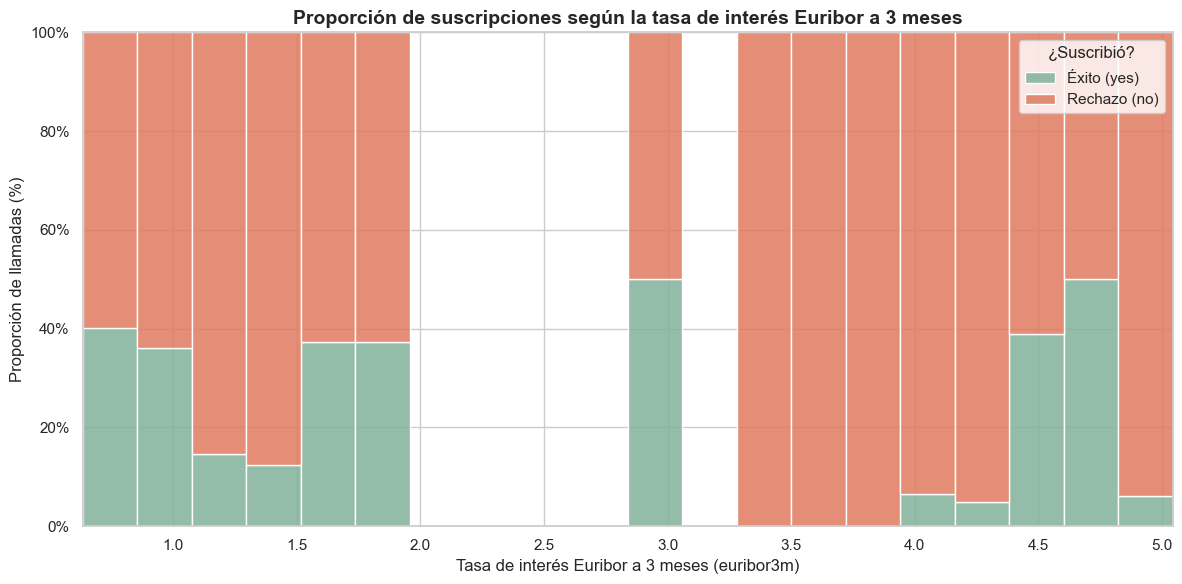

In [132]:
#
#12. Verificación de suposiciones: Impacto del Euribor en la suscripción
#
# Resumen analítico directo: Tasa de conversión en tramos críticos del Euribor
# -----------------------------------------------------------------------------------------
print("\n--- Tasa de conversión (%) en entornos de tipos de interés ---")
euribor_bajo = df_eda[df_eda['euribor3m'] < 2]['y'].value_counts(normalize=True) * 100
euribor_alto = df_eda[df_eda['euribor3m'] >= 4]['y'].value_counts(normalize=True) * 100

df_resumen_macro = pd.DataFrame({
    'Entorno económico': ['Tipos bajos (Euribor < 2%)', 'Tipos altos (Euribor >= 4%)'],
    'Tasa de éxito / yes (%)': [euribor_bajo.get('yes', 0), euribor_alto.get('yes', 0)]
})
display(df_resumen_macro.round(1))

# Gráfica de % de rechazo o éxito segunj la tasa de euribor. 
# ---------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Pintamos la distribución del Euribor segmentando por el éxito de la campaña
ax = sns.histplot(
    data=df_eda, 
    x='euribor3m', 
    hue='y', 
    multiple='fill', 
    bins=20, 
    palette=paleta_target,
    alpha=0.85
)

# Ajustamos etiquetas para un gráfico de proporciones acumuladas
plt.title('Proporción de suscripciones según la tasa de interés Euribor a 3 meses', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de interés Euribor a 3 meses (euribor3m)', fontsize=12)
plt.ylabel('Proporción de llamadas (%)', fontsize=12)

# Modificamos el eje Y para mostrarlo en formato porcentaje limpio
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
plt.legend(title='¿Suscribió?', labels=['Éxito (yes)', 'Rechazo (no)'])
plt.tight_layout()

save_plot('Impacto_euribor_suscripcion', plt.gcf())
plt.show()


Contrario a la creencia lógica de negocio de que "un Euribor alto incentiva la contratación por ofrecer rentabilidades atractivas", los datos demuestran un patrón radicalmente opuesto. En entornos de tipos bajos (Euribor < 2%), la tasa de éxito de la campaña se dispara exponencialmente. Por el contrario, en entornos de tipos altos (Euribor >= 4%), el porcentaje de éxito se desploma de forma severa.

En periodos de Euribor alto (asociados habitualmente a tensiones financieras o inflación alta), el cliente particular prefiere mantener su dinero disponible (liquidez inmediata) ante la incertidumbre o tiene un coste de oportunidad mayor (otras deudas que pagar). En cambio, en periodos de tipos de interés deprimidos, el cliente tradicional busca de manera activa cualquier producto financiero alternativo, como estos depósitos a plazo fijo, para conseguir rascar algo de rendimiento que su cuenta corriente habitual ya no le ofrece.


## Resultados  e insights estratégicos  

* **Ventaja competitiva en los márgenes demográficos (`age`):** El análisis de densidad de probabilidad desmiente una relación lineal simple con la edad. La conversión comercial le gana terreno al rechazo de forma visible en los extremos de la pirámide: los menores de 28 años y, de manera masiva, los mayores de 60 años (jubilados), quienes cuentan con mayor disponibilidad de atención y perfiles de ahorro conservadores.
* **La paradoja de las profesiones:** Aunque el volumen neto de captación lo sostienen los sectores administrativos (`admin.`), las tasas de éxito porcentual relativo más altas pertenecen a los estudiantes (**31.2%**) y jubilados (**25.1%**). Los datos respaldan la hipótesis de que su alta conversión se asocia a la predisposición de escucha, registrando las medianas de llamada más largas de la campaña (**276 s y 265 s**).
* **Ineficiencia en el reparto del esfuerzo comercial:** Se detectó que el banco sobre-contacta al cliente difícil e infra-contacta al cliente receptivo. Los autónomos (`self-employed`, 10.9% de éxito) reciben una media de **2.64 llamadas** por cliente, mientras que los estudiantes (31.2% de éxito) se sitúan a la cola con apenas **2.10 llamadas**. Además, la ley de rendimientos decrecientes demuestra que superar los 3 intentos por cliente destruye la rentabilidad operativa.
* **El riesgo de la masa crítica activa:** Los sectores laboralmente activos (`admin.`, `blue-collar`, `technician`) concentran un masivo **64.9% del volumen total de la cartera** llamada (**27.711 clientes**), pero registran las tasas de rechazo más elevadas debido a la falta de tiempo dentro de sus jornadas convencionales. Continuar con la estrategia telefónica rígida actual con este 65% del mercado destruye valor por saturación.
* **La sorpresa macroeconómica del Euribor:** Los datos refutan la hipótesis de que un Euribor alto estimula la contratación de depósitos por rentabilidad. En entornos de tipos bajos (Euribor < 2%), la tasa de éxito se dispara debido a que los clientes buscan activamente alternativas para rentabilizar sus ahorros, mientras que en entornos de tipos altos (Euribor >= 4%), la conversión se deprime por el coste de oportunidad o la necesidad de liquidez inmediata ante la inflación.
  
## 🚀 Recomendaciones comerciales para la toma de decisiones
1. **Establecer un límite de marcado (*capping*):** Configurar el software de telemarketing para detener la insistencia tras el tercer intento fallido por cliente, reasignando ese tiempo de operador hacia perfiles frescos.
2. **Priorización inteligente de nichos:** Diseñar campañas específicas de bajo coste de contacto dirigidas a estudiantes y jubilados para elevar la tasa media de éxito global.
3. **Reforma horaria y Cross-channel para el sector activo (64.9%):** Desplazar las llamadas para los perfiles ocupados hacia franjas tardías o fines de semana, e introducir canales asíncronos (notificaciones push en la app, email interactivo o SMS) para eliminar la presión de la llamada invasiva y permitirles analizar la oferta a su propio ritmo.  